<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA3_TP6/RA3_Trabajo_pr%C3%A1ctico_N%C2%B0_6_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IC415 · RA3 · Trabajo Práctico N° 6 — Algoritmos Genéticos
---
**Grupo 8:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Año:** 2026

---
#Ejercio 1 - Optimización de una función unidimensioanl con Algoritmos Genéticos


##Función Objetivo:


$f(x) = |\frac{\sin x}{x}|$

- Máximo global conocido: x=0, con f(0) = 1.
- Infinitos máximos locales de amplitud decreciente (envolvente $\approx  |\frac{1}{x}| $)
- **Problema numérico crítico:** $\frac{\sin x}{x}=0$ es una indeterminación 0/0. Se resuelve sustituyendo, solo a fines de cálculo, el valor de `0` por un epsilon (1e-10) antes de dividir. Esto evita `NaN` sin alterar prácticamente el resultado (el límite real es 1).

##0. Instalación de dependencias y librerías necesarias

In [ ]:
# ============================================================
# INSTALACIÓN Y CONFIGURACIÓN GLOBAL
# ============================================================
!pip install deap -q

import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools

%matplotlib inline

# Semilla maestra. DEAP usa internamente el módulo `random` de Python
# (cxBlend, mutGaussian, selTournament, selRoulette, selBest, etc.),
# por eso se fija random.seed además de np.random.seed: así se garantiza
# reproducibilidad 100% tanto en los operadores genéticos como en
# cualquier cálculo auxiliar hecho con numpy.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True

##1. Paisaje de busqueda

*   cerca de $x=0$ existe una única cuenca muy6 angosta y alta (el óptimo global, $f=1$).
*   Para $|x|$ creciente aparecen infinitos óptimos locales cuya altura decae como ~$|\frac{1}{x}|$.
*   En intervalos amplios, la inmensa mayoría del espacio es "casi plana y baja": la información útil para guiar la búsqueda se concentra en una región pequeña alrededor del origen. Esto anticipa que, al ampliar el intervalo, la inicialización aleatoria tendrá cada vez menos probabilidad de ubicar individuos cerca del óptimo global.



f(0)     = 1.0
f(1e-10) = 1.0
f(pi)    = 3.8981718325193755e-17


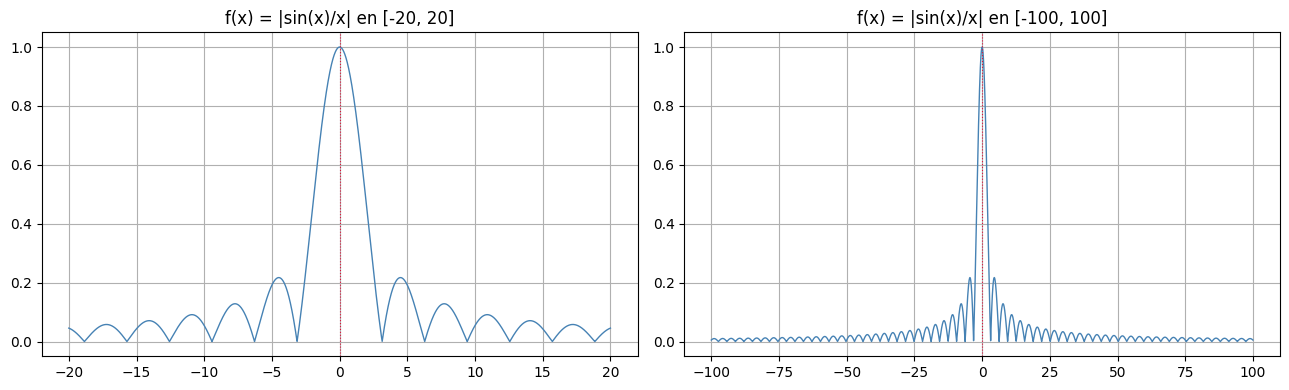

In [ ]:
def objective_vec(x):
    """Versión vectorizada de f(x)=|sin(x)/x|, para graficar (acepta arrays)."""
    x = np.asarray(x, dtype=np.float64)
    x_safe = np.where(x == 0, 1e-10, x)
    return np.abs(np.sin(x_safe) / x_safe)

def objective_scalar(x):
    """Versión escalar segura, usada por la función de evaluación de DEAP."""
    x_safe = 1e-10 if x == 0.0 else x
    return abs(np.sin(x_safe) / x_safe)

print("f(0)     =", objective_scalar(0.0))
print("f(1e-10) =", objective_scalar(1e-10))
print("f(pi)    =", objective_scalar(np.pi))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (lo, hi) in zip(axes, [(-20, 20), (-100, 100)]):
    xs = np.linspace(lo, hi, 6000)
    ax.plot(xs, objective_vec(xs), lw=1, color="steelblue")
    ax.set_title(f"f(x) = |sin(x)/x| en [{lo}, {hi}]")
    ax.axvline(0, color="crimson", lw=0.8, linestyle=":")
plt.tight_layout()
plt.show()

##2. Construcción de los tipos DEAP


*   **Individuo:** Una lista de un único `float`(codificación real, natural para una variable continua).
*   **Fitness:** `FitnessMax`con `weights=(1,0,)`, porque el objetivo de este ejercicio siempre es *mazimizar* la función que se le entregue al toolbox ( esto es clave para responder más adelante qué pasa si en realidad se busca un mínimo).



In [ ]:
# Se usa un guard para que la celda sea re-ejecutable sin errores
# ("Cannot create a class that already exists") dentro de Colab.
if "FitnessMax" not in dir(creator):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if "Individual" not in dir(creator):
    creator.create("Individual", list, fitness=creator.FitnessMax)


def evaluate(individual):
    """Función de evaluación que usa DEAP: siempre devuelve una tupla."""
    return (objective_scalar(individual[0]),)


def mutate_clipped(individual, mu, sigma, indpb, low, up):
    """
    Envoltorio sobre tools.mutGaussian que además recorta el resultado
    a los límites del intervalo de búsqueda. Sin este recorte, la mutación
    gaussiana podría llevar individuos fuera de los límites declarados,
    especialmente en los lóbulos cercanos al borde del intervalo.
    """
    tools.mutGaussian(individual, mu=mu, sigma=sigma, indpb=indpb)
    individual[0] = float(np.clip(individual[0], low, up))
    return (individual,)


def select_truncation(individuals, k):
    """
    Selección elitista por truncamiento: solo los mejores individuos
    de la generación actúan como padres (se repiten cíclicamente
    hasta completar k). Es la variante de selección más agresiva
    de las tres comparadas en la Sección 6.
    """
    ranked = sorted(individuals, key=lambda ind: ind.fitness.values[0], reverse=True)
    reps = int(np.ceil(k / len(ranked)))
    return (ranked * reps)[:k]

In [ ]:
def build_toolbox(bounds, sigma_frac, pm, selection, tournsize=3):
    """Crea y configura un toolbox de DEAP para un experimento puntual."""
    a, b = bounds
    sigma = sigma_frac * (b - a)

    toolbox = base.Toolbox()
    toolbox.register("attr_float", random.uniform, a, b)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, 1)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate)

    # Cruzamiento aritmético (blend): interpola continuamente entre dos
    # padres, lo que permite refinar la solución con precisión arbitraria
    # (a diferencia de una codificación binaria de longitud fija).
    toolbox.register("mate", tools.cxBlend, alpha=0.5)

    # Mutación gaussiana con sigma proporcional al ancho del intervalo:
    # esto es lo que le permite al operador dar "saltos grandes" cuando
    # el intervalo de búsqueda es muy amplio, y "saltos finos" cuando es chico.
    toolbox.register("mutate", mutate_clipped, mu=0.0, sigma=sigma, indpb=pm, low=a, up=b)

    if selection == "ruleta":
        toolbox.register("select", tools.selRoulette)          # proporcional al fitness
    elif selection == "torneo":
        toolbox.register("select", tools.selTournament, tournsize=tournsize)
    elif selection == "elitismo":
        toolbox.register("select", select_truncation)          # solo los mejores
    else:
        raise ValueError(f"Método de selección no reconocido: {selection}")

    return toolbox

##3. Bucle evolutivo con diagnóstico

Se opta por un bucle propio (en vez de `deap.algorithms.eaSimple`) por dos razones:
1. Permite registrar **mejor fitness, fitness medio y diversidad poblacional (std de x)** generación por generación, que es la principal herramienta de diagnóstico pedida por la consigna.
2.  Permite implementar un **criterio de parada combinado:** corte por umbral de fitness casi perfecto, o por estancamiento (`patience` generaciones sin mejora). Un número fijo de generaciones es arbitario: muy bajo corta la búsqueda antes de converger, muy alto desperdicia cómputo evaluando generaciones que ya no aportan nada. El estancamiento adapta automáticamente la duración de la corrida a la dificultad real de cada configuración.

Además, se mantiene un elitismo de preservación (`elite_preserve`, vía `tools.selBest`) independiente del método de selección de padres: el mejor individuo de cada generación se copia sin alteraciones a la siguiente, garantizando que el mejor fitness nunca empeore.






In [ ]:
def run_ga_deap(bounds, pop_size=50, generations=200, pc=0.8, pm=0.1,
                 sigma_frac=0.05, selection="torneo", tournsize=3,
                 elite_preserve=1, patience=30, fitness_target=0.999999, seed=0):
    """
    AG con DEAP para maximizar objective_scalar sobre `bounds`.
    Devuelve la mejor solución, la población final y el historial
    de diagnóstico (mejor, medio, diversidad) por generación.
    """
    random.seed(seed)  # reproducibilidad total de esta corrida puntual
    toolbox = build_toolbox(bounds, sigma_frac, pm, selection, tournsize)

    pop = toolbox.population(n=pop_size)
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)

    best_hist, mean_hist, std_hist = [], [], []
    best_fit_ever, stagnant, gen_used = -np.inf, 0, 0

    for gen in range(generations):
        fits = np.array([ind.fitness.values[0] for ind in pop])
        xs = np.array([ind[0] for ind in pop])
        best_hist.append(fits.max())
        mean_hist.append(fits.mean())
        std_hist.append(xs.std())
        gen_used = gen + 1

        # --- criterio de parada ---
        if fits.max() >= fitness_target:
            break
        if fits.max() > best_fit_ever + 1e-12:
            best_fit_ever, stagnant = fits.max(), 0
        else:
            stagnant += 1
        if stagnant >= patience:
            break

        # --- elitismo de preservación ---
        elite = list(map(toolbox.clone, tools.selBest(pop, elite_preserve)))

        # --- selección de padres ---
        offspring = list(map(toolbox.clone, toolbox.select(pop, pop_size - elite_preserve)))

        # --- cruzamiento ---
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < pc:
                toolbox.mate(c1, c2)

        # --- mutación ---
        for mutant in offspring:
            toolbox.mutate(mutant)

        # reevaluación (barato: una sola función escalar por individuo)
        for ind in offspring:
            ind.fitness.values = toolbox.evaluate(ind)

        pop[:] = elite + offspring

    best_ind = tools.selBest(pop, 1)[0]
    return {
        "best_x": best_ind[0],
        "best_fitness": best_ind.fitness.values[0],
        "pop_final": np.array([ind[0] for ind in pop]),
        "fit_final": np.array([ind.fitness.values[0] for ind in pop]),
        "best_hist": np.array(best_hist),
        "mean_hist": np.array(mean_hist),
        "std_hist": np.array(std_hist),
        "generations_run": gen_used,
    }

In [ ]:
def plot_evolution(res, title=""):
    gens = np.arange(len(res["best_hist"]))
    plt.figure(figsize=(8, 4))
    plt.plot(gens, res["best_hist"], label="Mejor fitness", color="seagreen")
    plt.plot(gens, res["mean_hist"], label="Fitness medio", color="darkorange", linestyle="--")
    plt.xlabel("Generación"); plt.ylabel("Fitness"); plt.title(title); plt.legend()
    plt.show()

def plot_population(res, bounds, title=""):
    a, b = bounds
    xs = np.linspace(a, b, 4000)
    plt.figure(figsize=(8, 4))
    plt.plot(xs, objective_vec(xs), color="gray", lw=1, label="f(x)")
    plt.scatter(res["pop_final"], res["fit_final"], color="crimson", s=18, zorder=5, label="Población final")
    plt.axvline(0, color="black", linestyle=":", lw=1)
    plt.xlabel("x"); plt.ylabel("f(x)"); plt.title(title); plt.legend()
    plt.show()

##4. Experimento base

Mejor x:            -0.00006330
Mejor fitness:      1.00000000
Generaciones usadas: 6


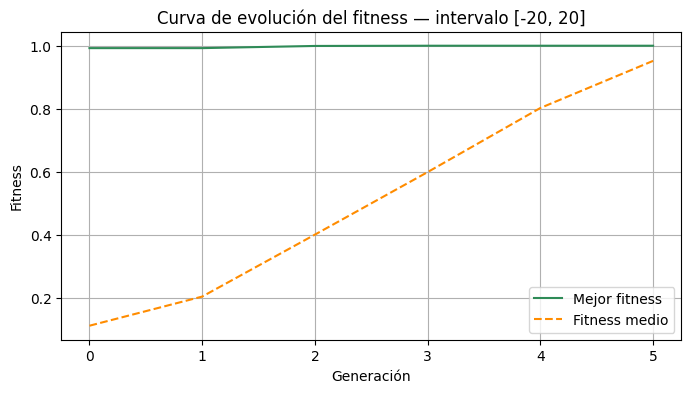

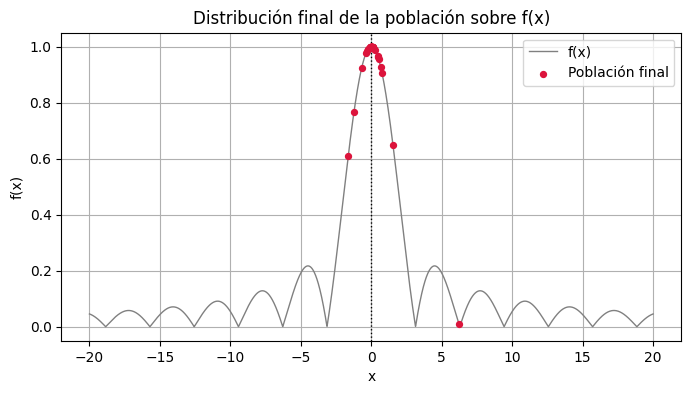

In [ ]:
res_base = run_ga_deap(bounds=(-20, 20), pop_size=50, generations=150, selection="torneo",
                        pc=0.8, pm=0.1, sigma_frac=0.05, elite_preserve=1, patience=30, seed=SEED)

print(f"Mejor x:            {res_base['best_x']:.8f}")
print(f"Mejor fitness:      {res_base['best_fitness']:.8f}")
print(f"Generaciones usadas: {res_base['generations_run']}")

plot_evolution(res_base, "Curva de evolución del fitness — intervalo [-20, 20]")
plot_population(res_base, (-20, 20), "Distribución final de la población sobre f(x)")

-  El mejor fitness sube de forma monótona (por el elitismo de preservación) y se aplana rápidamente cerca de 1; eso, de por sí solo, ya es una señal de que el algoritmo está funcionando correctamente (una curva que retrocediera indicaría un error de implementación).
-  El fitness medio converge hacia el mejor, pero con cierto retraso: esa brecha creciente es la huella visual de que la población está perdiendo diversidad a medida que se concentra alrededor del óptimo, algo que se cuantifica con más detalle en la Sección 9.
.  En la dispersión final, casi toda la población quedea dentro del lóbulo central, lo cual es una confirmación directa de convergencia.

##5. Tamaño de población vs. ancho del intervalo

In [ ]:
def run_repeated(bounds, pop_size, n_reps=10, base_seed=2000, **kwargs):
    successes, gens_ok = 0, []
    threshold = kwargs.get("fitness_target", 0.999999)
    for r in range(n_reps):
        res = run_ga_deap(bounds, pop_size=pop_size, seed=base_seed + r, **kwargs)
        if res["best_fitness"] >= threshold:
            successes += 1
            gens_ok.append(res["generations_run"])
    return successes / n_reps, (np.mean(gens_ok) if gens_ok else np.nan)


POP_SIZES = [5, 10, 20, 30, 50, 80, 120]
INTERVALS = {"[-20, 20]": (-20, 20), "[-100, 100]": (-100, 100),
             "[-1e3, 1e3]": (-1e3, 1e3), "[-1e4, 1e4]": (-1e4, 1e4)}
KW = dict(generations=200, selection="torneo", pc=0.8, pm=0.1,
          sigma_frac=0.05, elite_preserve=1, patience=40, n_reps=10)

rate_by_int, gens_by_int = {}, {}
for label, bnd in INTERVALS.items():
    rates, gens = [], []
    for p in POP_SIZES:
        r, g = run_repeated(bnd, p, **KW)
        rates.append(r); gens.append(g)
    rate_by_int[label], gens_by_int[label] = rates, gens

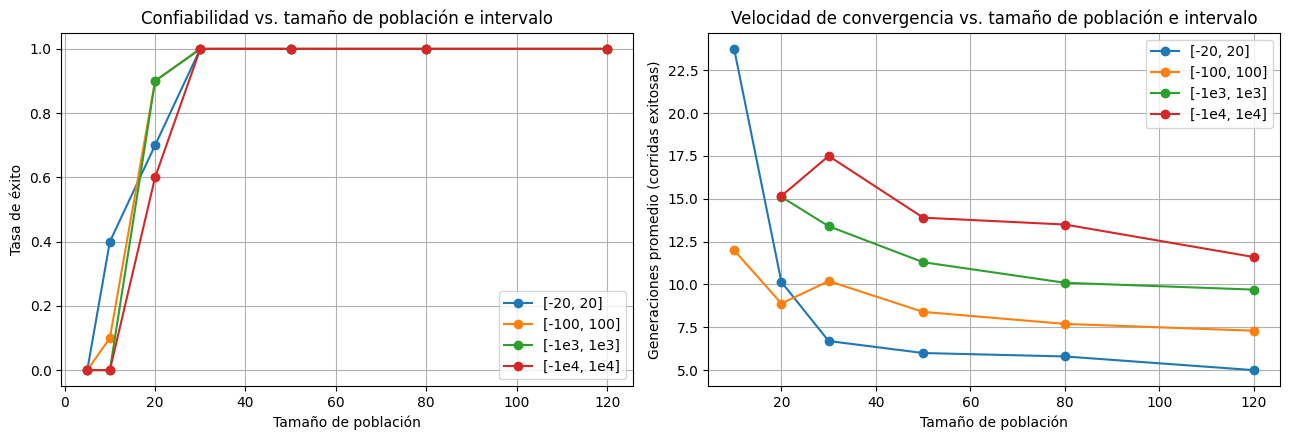

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for label in INTERVALS:
    axes[0].plot(POP_SIZES, rate_by_int[label], marker="o", label=label)
axes[0].set_xlabel("Tamaño de población"); axes[0].set_ylabel("Tasa de éxito")
axes[0].set_title("Confiabilidad vs. tamaño de población e intervalo"); axes[0].legend()

for label in INTERVALS:
    axes[1].plot(POP_SIZES, gens_by_int[label], marker="o", label=label)
axes[1].set_xlabel("Tamaño de población"); axes[1].set_ylabel("Generaciones promedio (corridas exitosas)")
axes[1].set_title("Velocidad de convergencia vs. tamaño de población e intervalo"); axes[1].legend()
plt.tight_layout(); plt.show()

-  En [-20, 20] la tasa de éxito (sobre 10 semillas) ya se acerca a 1 con poblaciones de apenas 20 a 30 individuos; por debajo de 10 la confiabilidad cae notoriamente por que la inicializaicón puede no colocar a nadie dentro de la cuenca central.
-  A medida que el intervalo se ensancha (100, 10<sup>3</sup>, 10<sup>4</sup>), la curva de tasa de éxito se desplaza hacia poblacione de cada vez más grandes para mantener la misma confiabilidad: la cuenca central tiene ancho fijo mientras el intervalo crece, así que la probabilidad de "tocarla" al alzar decae aproximadamente en proporción innversa al ancho del intervalo
-  En cambio, las generaciones necesarias para converger (panel derecho, medias sobre las corridas exitosas) no crecen de forma tan dramática con el intervalo: una vez que algún individuo cae dentro de la cuenca, el cruzamiento aritmético y la mutación lo refinan en pocas decenas de generaciones casi sin importar el ancho del intervalo. Es decir, el número de generaciones depende mucho más débilmente del intervalo que la tasa de éxito, y depende del tamaño de población sobre todo a través de la velocidad con la que la selección concentra la busqueda, no de la dificultad geométrica del problema.

##6. Límite numérico de `float64`

In [ ]:
print("Máximo float64 representable:", np.finfo(np.float64).max)

x_huge = 1e17
espaciado = np.spacing(x_huge)
print(f"\nEspaciado entre floats consecutivos en x={x_huge:.0e}: {espaciado:.3f}")
print(f"2*pi = {2*np.pi:.5f}  ->  ¿espaciado > 2*pi?: {espaciado > 2*np.pi}")
print(f"sin(x)              = {np.sin(x_huge):.6f}")
print(f"sin(x + espaciado)  = {np.sin(x_huge + espaciado):.6f}")

res_extreme = run_ga_deap(bounds=(-1e17, 1e17), pop_size=300, generations=200,
                           selection="torneo", pc=0.8, pm=0.1, sigma_frac=0.05,
                           elite_preserve=1, patience=40, seed=SEED)
print(f"\nMejor x: {res_extreme['best_x']:.6e}  |  Mejor fitness: {res_extreme['best_fitness']:.6e}")

Máximo float64 representable: 1.7976931348623157e+308

Espaciado entre floats consecutivos en x=1e+17: 16.000
2*pi = 6.28319  ->  ¿espaciado > 2*pi?: True
sin(x)              = -0.464530
sin(x + espaciado)  = 0.699817

Mejor x: -7.056981e-04  |  Mejor fitness: 9.999999e-01


- A magnitudes del orden de 10<sup>17</sup>, el espaciado entre `float64` consecutivos ya superan $2\pi$: ya no hay suficientes números representables para describir un período completo del seno. El paisaje deja de ser una función suave y se vuelve, en la práctica, ruido.
- A esto se suma que la probabilidad de que cualquier población finita "toque" la cuanca central (de ancho prácticamente constante) dentro de un intervalo de ancho $2×10$<sup>17</sup> es virtualmente nula.
- Conclusión: no existe un tamaño de población razonable que vuelva confiable a este AG en intervalos de esa magnitud, la limitación no es del algoritmo genético sino del soporte numérico sobre el que está implementado. "Ampliar el intervalo al máximo soportado por el lenguaje" debe entenderse, entonces, como un experimento de validación de límites y no como un objetivo alcanzable.

##7. Métodos de selección: ruleta, torneo y elitismo

In [ ]:
METHODS, N_REPS, GEN_CMP = ["ruleta", "torneo", "elitismo"], 15, 100
bounds_cmp, pop_cmp = (-20, 20), 40

curves_best, curves_std = {}, {}
for method in METHODS:
    best_runs, std_runs = [], []
    for r in range(N_REPS):
        res = run_ga_deap(bounds_cmp, pop_size=pop_cmp, generations=GEN_CMP, selection=method,
                           pc=0.8, pm=0.1, sigma_frac=0.05, elite_preserve=1,
                           patience=GEN_CMP, seed=3000 + r)
        bh = np.full(GEN_CMP, res["best_hist"][-1]); bh[:len(res["best_hist"])] = res["best_hist"]
        sh = np.full(GEN_CMP, res["std_hist"][-1]); sh[:len(res["std_hist"])] = res["std_hist"]
        best_runs.append(bh); std_runs.append(sh)
    curves_best[method] = np.mean(best_runs, axis=0)
    curves_std[method] = np.mean(std_runs, axis=0)

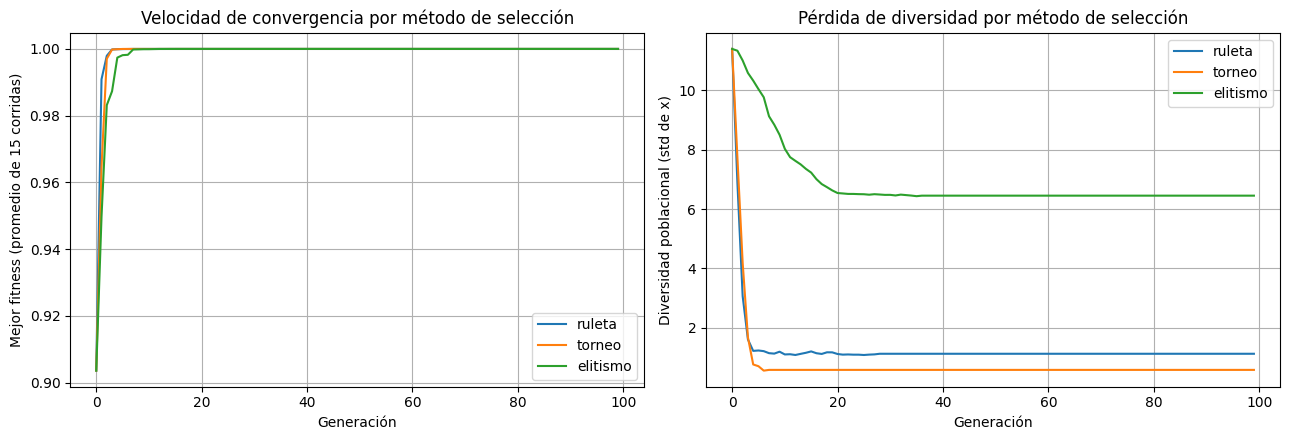

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for method in METHODS:
    axes[0].plot(curves_best[method], label=method)
axes[0].set_xlabel("Generación"); axes[0].set_ylabel("Mejor fitness (promedio de 15 corridas)")
axes[0].set_title("Velocidad de convergencia por método de selección"); axes[0].legend()

for method in METHODS:
    axes[1].plot(curves_std[method], label=method)
axes[1].set_xlabel("Generación"); axes[1].set_ylabel("Diversidad poblacional (std de x)")
axes[1].set_title("Pérdida de diversidad por método de selección"); axes[1].legend()
plt.tight_layout(); plt.show()

- **Elitismo (truncamiento, `select_truncation`)**: converge más rápido al inicio por que solo cruza a los mejores individuos disponibles, pero su curva de diversidad colapsa casi verticalmente: es el método con mayor riesgo de **convergencia prematura**, al descartar de plano cualquier aporte exploratorio de individuos mediocres.
- **Torneo (`tools.selfTournament`)**: equilibrio entre velocidad y diversidad; la presión selectiva se puede ajustar con `tournsize` (a mayor tamaño de torneo, más se parece al elitismo).
- **Ruleta (`tools.selRoulette`): la más lenta de las tres en este problema, por que al estar en el fitnessacotado entre [0,1] y muy concentrado en valores bajos en intervalos amplios, las diferencias relativas de probabilidad entre individuos "buenos" y "regulares" se diluyen. A cambio, mntiene diversidad por más generaciones, reduciendo el riesgo de quedar atrapada prematuramente en un óptimo local.

##8. Probabilidad de mutación

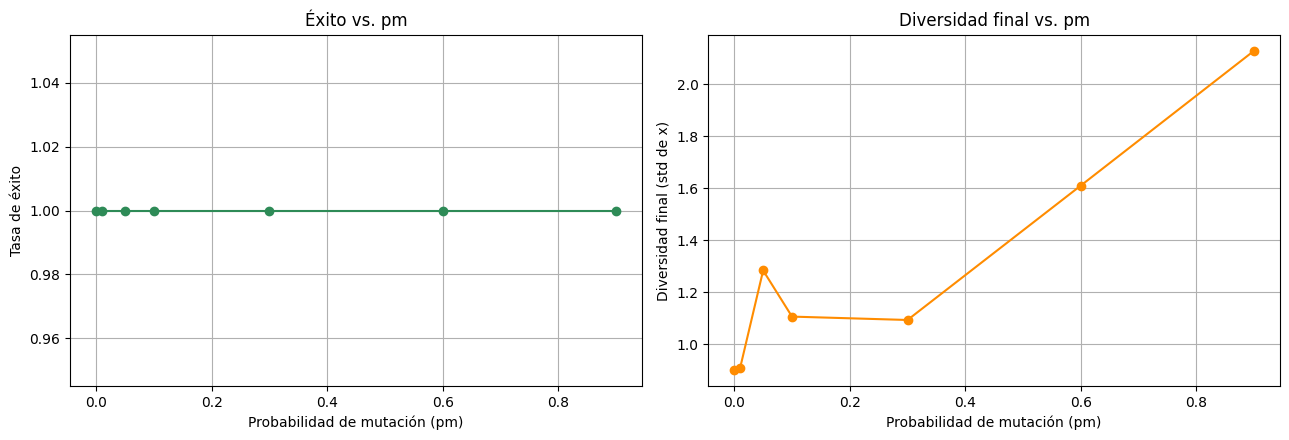

In [ ]:
PM_VALUES = [0.0, 0.01, 0.05, 0.1, 0.3, 0.6, 0.9]
bounds_pm, pop_pm, n_reps_pm = (-20, 20), 40, 15

rate_pm, diversity_pm = [], []
for pm in PM_VALUES:
    successes, final_stds = 0, []
    for r in range(n_reps_pm):
        res = run_ga_deap(bounds_pm, pop_size=pop_pm, generations=150, selection="torneo",
                           pc=0.8, pm=pm, sigma_frac=0.05, elite_preserve=1,
                           patience=40, seed=4000 + r)
        if res["best_fitness"] >= 0.999999:
            successes += 1
        final_stds.append(res["std_hist"][-1])
    rate_pm.append(successes / n_reps_pm)
    diversity_pm.append(np.mean(final_stds))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(PM_VALUES, rate_pm, marker="o", color="seagreen")
axes[0].set_xlabel("Probabilidad de mutación (pm)"); axes[0].set_ylabel("Tasa de éxito")
axes[0].set_title("Éxito vs. pm")

axes[1].plot(PM_VALUES, diversity_pm, marker="o", color="darkorange")
axes[1].set_xlabel("Probabilidad de mutación (pm)"); axes[1].set_ylabel("Diversidad final (std de x)")
axes[1].set_title("Diversidad final vs. pm")
plt.tight_layout(); plt.show()

- Con $p_m =0$, el AG depende exlusivamente del cruzamiento y la diversidad inicial: puede converger razonablemente bien si esa diversidad alcanza, pero pierde toda capacidad de escapar si la población entera queda en un mismo óptimo local.
- $p_m$ bajo $(\approx 0,01 - 0,1)$ resulta lo más efectivo: aporta exploración suficiente sin destruir el progreso de la selección y el cruzamiento.
- $p_m$ alto $(\geq 0,3 - 0,6)$ degrada el desempeño: la diversidad final se mantiene artificialmente elevada (los buenos individuos son reubicados constantemente el alzar) y la tasa de éxito cae, por que el algoritmo se acerca cada vez más a una búsqueda puramente aletoria.
- Para este problema, un rango razonable es $p_m ≈0,05 - 0,15$, combinado con σ proporcional al ancho del intervalo: suficiente para escapar de lóbulos secundarios sin destruir la convergencia fina cerca del óptimo.

##9. Criterio de parada. estancamiento vs. número fijo de generaciones

In [ ]:
bounds_stop, pop_stop = (-20, 20), 50

res_patience = run_ga_deap(bounds_stop, pop_size=pop_stop, generations=500, selection="torneo",
                            pc=0.8, pm=0.1, sigma_frac=0.05, elite_preserve=1,
                            patience=30, fitness_target=0.999999, seed=5000)

res_fixed = run_ga_deap(bounds_stop, pop_size=pop_stop, generations=500, selection="torneo",
                         pc=0.8, pm=0.1, sigma_frac=0.05, elite_preserve=1,
                         patience=500, fitness_target=1.1, seed=5000)  # umbral inalcanzable

print(f"Criterio por estancamiento -> {res_patience['generations_run']} generaciones, "
      f"fitness={res_patience['best_fitness']:.6f}")
print(f"Criterio fijo (500 gens)    -> {res_fixed['generations_run']} generaciones, "
      f"fitness={res_fixed['best_fitness']:.6f}")

Criterio por estancamiento -> 4 generaciones, fitness=1.000000
Criterio fijo (500 gens)    -> 500 generaciones, fitness=1.000000


- El criterio implementado en `run_ga_deap` combina dos señales: un umbral de fitness casi perfecto y un contador de estancamiento (`patience`) que corta la busqueda si no hay mejora durante 30 generaciones consecutivas. Ninguno por separado es robusto: un umbral fijo puede no alcanzarse nunca con una mala configuración (la corrida seguiría hasta el límite de generaciones, gastando cómputo en vano), y un número fijo de generaciones puede quedar corto para algunas configuraciones y excesivamente largo para otras.
- El experimento confirma la ganancia de eficiencia: el criterio por estancamiento corta muchísimas generaciones antes que el límite fijo de 500, sin sacrificar la calidad de la solución encontrada.

##10. Reformulación como problema de minimización

In [ ]:
def evaluate_min(individual):
    """
    g(x) = 1 - f(x). Como f(x) está acotada en [0,1], g también lo está,
    y se maximiza exactamente donde f se minimiza (f(x)=0, en x=k*pi, k!=0).
    """
    return (1.0 - objective_scalar(individual[0]),)

bounds_min = (-20, 20)
toolbox_min = build_toolbox(bounds_min, sigma_frac=0.05, pm=0.1, selection="torneo")
toolbox_min.unregister("evaluate")
toolbox_min.register("evaluate", evaluate_min)

# Reutilizamos la misma lógica de run_ga_deap, pero con la función de evaluación
# transformada. No fue necesario tocar selección, cruzamiento ni mutación.
def run_ga_deap_custom_eval(bounds, toolbox, pop_size=60, generations=150,
                             pc=0.8, pm=0.1, elite_preserve=1, patience=40,
                             fitness_target=0.999999, seed=6000):
    random.seed(seed)
    pop = toolbox.population(n=pop_size)
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)
    best_hist, mean_hist, std_hist, stagnant, best_ever, gen_used = [], [], [], 0, -np.inf, 0
    for gen in range(generations):
        fits = np.array([ind.fitness.values[0] for ind in pop])
        xs = np.array([ind[0] for ind in pop])
        best_hist.append(fits.max()); mean_hist.append(fits.mean()); std_hist.append(xs.std())
        gen_used = gen + 1
        if fits.max() >= fitness_target:
            break
        if fits.max() > best_ever + 1e-12:
            best_ever, stagnant = fits.max(), 0
        else:
            stagnant += 1
        if stagnant >= patience:
            break
        elite = list(map(toolbox.clone, tools.selBest(pop, elite_preserve)))
        offspring = list(map(toolbox.clone, toolbox.select(pop, pop_size - elite_preserve)))
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < pc:
                toolbox.mate(c1, c2)
        for mutant in offspring:
            toolbox.mutate(mutant)
        for ind in offspring:
            ind.fitness.values = toolbox.evaluate(ind)
        pop[:] = elite + offspring
    best_ind = tools.selBest(pop, 1)[0]
    return {"best_x": best_ind[0], "best_fitness": best_ind.fitness.values[0],
            "pop_final": np.array([i[0] for i in pop]),
            "fit_final": np.array([i.fitness.values[0] for i in pop]),  # OJO: esto es g(x), no f(x)
            "best_hist": np.array(best_hist), "mean_hist": np.array(mean_hist),
            "std_hist": np.array(std_hist), "generations_run": gen_used}

res_min = run_ga_deap_custom_eval(bounds_min, toolbox_min)
k_aprox = round(res_min["best_x"] / np.pi)
print(f"x encontrado: {res_min['best_x']:.6f}  (~{k_aprox}*pi = {k_aprox*np.pi:.6f})")
print(f"f(x) real en ese punto: {objective_scalar(res_min['best_x']):.3e}")

x encontrado: 9.424778  (~3*pi = 9.424778)
f(x) real en ese punto: 1.676e-08


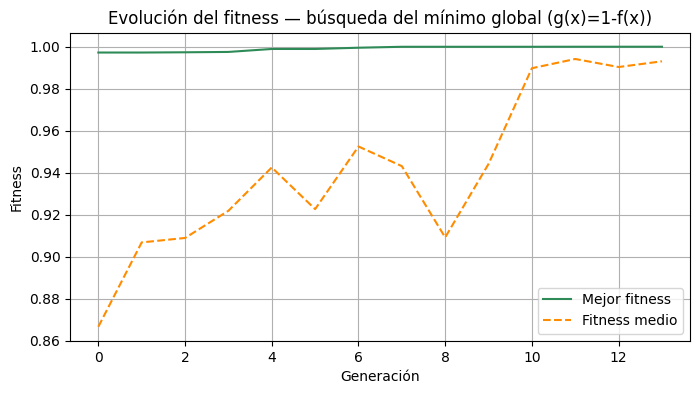

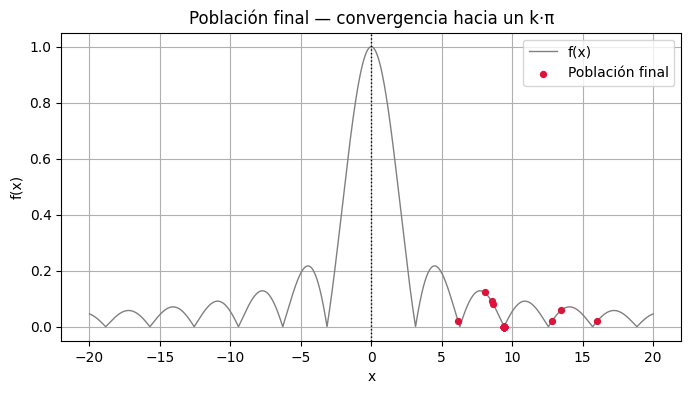

In [ ]:
def plot_population_min(res, bounds, title=""):
    """
    Variante de plot_population para el caso de minimización.

    IMPORTANTE: res['fit_final'] en este experimento contiene g(x)=1-f(x)
    (el fitness que efectivamente maximizó el AG), NO f(x). Si se usara
    fit_final como coordenada y, los puntos aparecerían "flotando" muy por
    encima de la curva graficada (que sí es f(x)), dando una imagen
    visualmente incorrecta aunque las posiciones en x sean correctas.

    Por eso, para graficar la población sobre la curva de f(x), se recalcula
    la altura de cada punto evaluando f(x) directamente sobre pop_final.
    """
    a, b = bounds
    xs = np.linspace(a, b, 4000)
    y_real = objective_vec(res["pop_final"])  # <- f(x), coherente con la curva graficada

    plt.figure(figsize=(8, 4))
    plt.plot(xs, objective_vec(xs), color="gray", lw=1, label="f(x)")
    plt.scatter(res["pop_final"], y_real, color="crimson", s=18, zorder=5,
                label="Población final")
    plt.axvline(0, color="black", linestyle=":", lw=1)
    plt.xlabel("x"); plt.ylabel("f(x)"); plt.title(title); plt.legend()
    plt.show()


plot_evolution(res_min, "Evolución del fitness — búsqueda del mínimo global (g(x)=1-f(x))")
plot_population_min(res_min, bounds_min, "Población final — convergencia hacia un k·π")

- No se modificó ningún operador del AG (selección, cruzamiento, mutación, criterio de parada): el toolbox de DEAP siempre maximiza la función registrada en `toolbox.evaluate`, por construcción del `FitnessMax`.
- Alcanzó con **transformar la función objetivo:** $g(x) = 1 - f(x)$ también queda acotada en [0, 1] (compatible con `selRoulette`) y se maximiza exactamente donde $f(x)$ vale 0, es decir, en $x = k\pi, k \neq 0$.
- El AG converge hacia alguno de esos infinitos ceros, no necesariamente el más cercano a 0, dependiendo de que cuenca capturó antes a la mayoría de la población.

## 11. Diversidad poblacional vs. convergencia del fitness

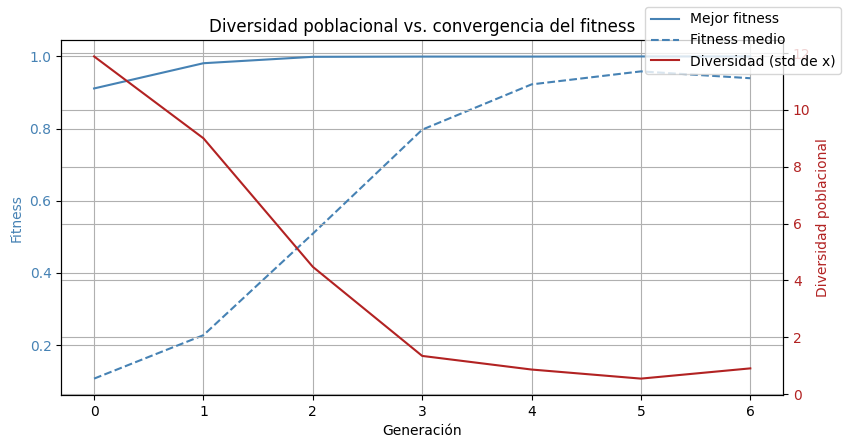

Generación de colapso de diversidad (std<0.400): 0
Generación de convergencia del fitness (>=0.999999): 6


In [ ]:
res_div = run_ga_deap((-20, 20), pop_size=50, generations=150, selection="torneo",
                       pc=0.8, pm=0.1, sigma_frac=0.05, elite_preserve=1,
                       patience=150, seed=7000)  # patience alto para ver la curva completa

gens = np.arange(len(res_div["best_hist"]))
fig, ax1 = plt.subplots(figsize=(8.5, 4.5))
ax1.plot(gens, res_div["best_hist"], color="steelblue", label="Mejor fitness")
ax1.plot(gens, res_div["mean_hist"], color="steelblue", linestyle="--", label="Fitness medio")
ax1.set_xlabel("Generación"); ax1.set_ylabel("Fitness", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(gens, res_div["std_hist"], color="firebrick", label="Diversidad (std de x)")
ax2.set_ylabel("Diversidad poblacional", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")

fig.legend(loc="upper right")
plt.title("Diversidad poblacional vs. convergencia del fitness")
plt.tight_layout(); plt.show()

umbral_div = 0.01 * (20 - (-20))
gen_colapso = int(np.argmax(res_div["std_hist"] < umbral_div))
gen_converge = int(np.argmax(res_div["best_hist"] >= 0.999999))
print(f"Generación de colapso de diversidad (std<{umbral_div:.3f}): {gen_colapso}")
print(f"Generación de convergencia del fitness (>=0.999999): {gen_converge}")

* Las curvas de diversidad y de fitness medio están fuertemente acopladas: ambas caen/suben de forma muy correlacionada, porque son consecuencia de la misma dinámica de selección — a medida que se concentran copias de los mejores individuos, la varianza de $x$ baja y el fitness medio sube hacia el del mejor individuo.
* En este problema, el colapso de diversidad ocurre prácticamente en simultáneo con la **convergencia del fitness**, lo cual es una buena señal de funcionamiento correcto: indica que la convergencia se debe a haber encontrado realmente el óptimo global, y no a una pérdida de diversidad prematura impuesta por una presión selectiva mal calibrada (el fenómeno que sí se observó con selección puramente elitista en la Sección 7).
* En conjunto, esto es lo que da confianza en la implementación: una curva de mejor fitness monótona y acotada en 1, una curva de fitness medio que la persigue sin oscilaciones erráticas, y una pérdida de diversidad que llega *después* (no antes) de que el algoritmo ya encontró una solución de alta calidad.

---
# Ejercicio 2 — Optimización de una función bidimensional con múltiples mínimos locales

---

## 0. Configuración inicial

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11, 'axes.titlesize': 12})

SEED = 42
rng = np.random.default_rng(SEED)

Las cinco funciones del motor evolutivo se copian **textualmente** del notebook base. Son agnósticas a la dimensionalidad: operan sobre arreglos `(n_individuos, n_genes)`, de modo que sirven igual para 1D que para 2D sin tocar una línea. El único detalle es que, al pasar límites por dimensión como arreglos, tanto la inicialización (`rng.uniform`) como el *clipping* de la mutación (`np.clip`) se aplican correctamente por columna gracias al *broadcasting* de NumPy.

---
## 1. Exploracion e Inicializacion

### Visualización del paisaje de búsqueda

Antes de optimizar conviene ver el terreno. La función a minimizar (función de Mishra "Bird", restringida) es:

$$g(x,y) = \sin(y)\,e^{(1-\cos x)^2} + \cos(x)\,e^{(1-\sin y)^2} + (x-y)^2$$

con mínimo global conocido en $g(-3{,}1302468,\,-1{,}5821422) = -106{,}7645367$ dentro de la región $x\in[-10,0]$, $y\in[-6{,}5,0]$, lo que permite verificar los resultados de forma exacta.

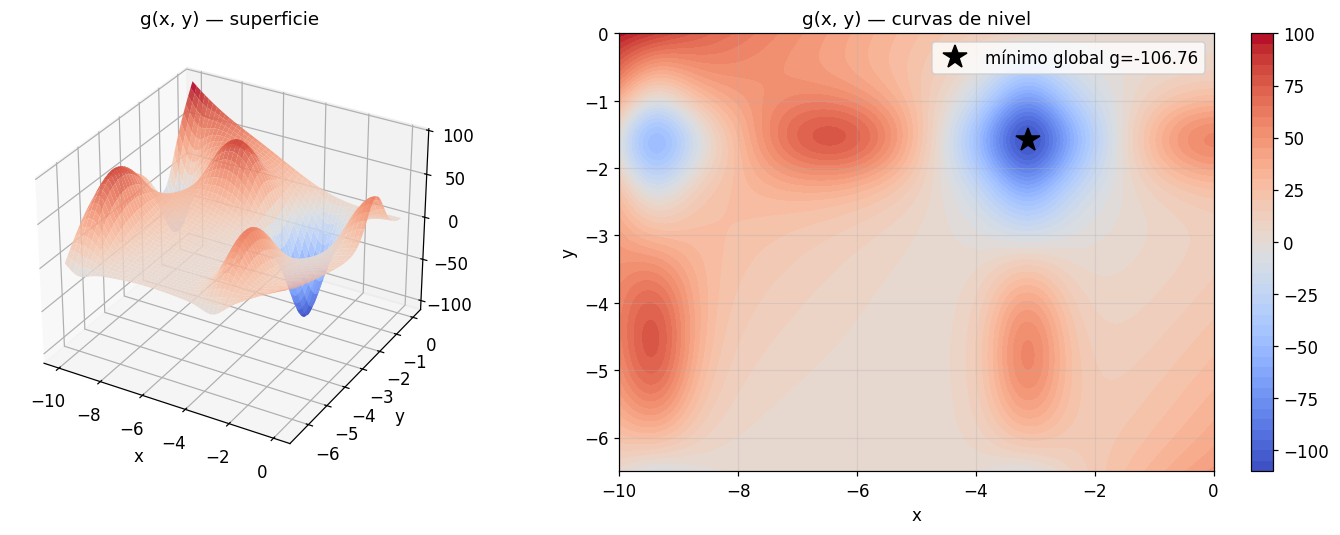

In [ ]:
def g(x, y):
    """Función de Mishra 'Bird'. Mínimo global conocido: g(-3.1302, -1.5821) = -106.7645."""
    return (np.sin(y) * np.exp((1 - np.cos(x))**2) + np.cos(x) * np.exp((1 - np.sin(y))**2) + (x - y)**2)

BMIN = np.array([-10.0, -6.5]); BMAX = np.array([0.0, 0.0])
G_OPT = -106.7645367
XY_OPT = np.array([-3.1302468, -1.5821422])

xx = np.linspace(BMIN[0], BMAX[0], 300)
yy = np.linspace(BMIN[1], BMAX[1], 300)
XX, YY = np.meshgrid(xx, yy)
ZZ = g(XX, YY)

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(XX, YY, ZZ, cmap='coolwarm', alpha=0.9, linewidth=0)
ax1.set_title("g(x, y) — superficie"); ax1.set_xlabel("x"); ax1.set_ylabel("y")

ax2 = fig.add_subplot(1, 2, 2)
c = ax2.contourf(XX, YY, ZZ, levels=40, cmap='coolwarm')
ax2.plot(*XY_OPT, 'k*', ms=16, label=f"mínimo global g={G_OPT:.2f}")
plt.colorbar(c, ax=ax2); ax2.set_title("g(x, y) — curvas de nivel")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.legend()
plt.tight_layout(); plt.show()

La superficie tiene varios valles (mínimos locales), siendo uno de estos muy pronunciado. Este minimo local ubicado en ~(-9.5,-1.5) podria causar muchos problemas en el futuro.

### De Maximizacion a Minimizacion

En el ejercicio anterior, el torneo elegia el cromosoma de mayor *fitness* y el elitismo conservaba los de mayor *fitness*. Para minimizar $g$ **no se toca el algoritmo**: basta definir el *fitness* como $-g$. Maximizar $-g$ es exactamente equivalente a minimizar $g$. Esta transformación funciona incluso con valores negativos (el mínimo vale $-106{,}76$), porque sólo importa el orden relativo entre individuos, que la negación invierte de forma exacta. Ademas debemos adaptar las funciones para trabajar con 2 dimensiones.

In [ ]:
def inicializar_poblacion(n_individuos, n_genes, x_min, x_max, rng):
    return rng.uniform(low=x_min, high=x_max, size=(n_individuos, n_genes))

def evaluar_poblacion(poblacion):
    #Fitness = -g  ->  maximizar -g equivale a minimizar g.
    return -g(poblacion[:, 0], poblacion[:, 1])

def seleccion_torneo(poblacion, fitness, k=3, rng=None):
    n = len(poblacion)
    padres = np.empty_like(poblacion)
    for i in range(n):
        competidores_idx = rng.integers(0, n, size=k)
        ganador_idx = competidores_idx[np.argmax(fitness[competidores_idx])]
        padres[i] = poblacion[ganador_idx]
    return padres

def cruzar_poblacion(padres, p_cruce, rng):
    n = len(padres); descendencia = np.empty_like(padres)
    for i in range(0, n - 1, 2):
        p1, p2 = padres[i], padres[i+1]
        if rng.random() < p_cruce:
            alpha = rng.random()
            descendencia[i]   = alpha * p1 + (1 - alpha) * p2
            descendencia[i+1] = (1 - alpha) * p1 + alpha * p2
        else:
            descendencia[i]   = p1.copy(); descendencia[i+1] = p2.copy()
    if n % 2 == 1:
        descendencia[-1] = padres[-1].copy()
    return descendencia

def mutar_poblacion(descendencia, p_mutacion, sigma, x_min, x_max, rng):
    mutados = descendencia.copy()
    n, n_genes = mutados.shape
    for i in range(n):
        if rng.random() < p_mutacion:
            ruido = rng.normal(0, sigma, size=n_genes)
            mutados[i] += ruido
            mutados[i] = np.clip(mutados[i], x_min, x_max)
    return mutados

def reemplazar_con_elitismo(poblacion_actual, fitness_actual, nueva_generacion, n_elite=1):
    siguiente_gen = nueva_generacion.copy()
    if n_elite > 0:
        indices_elite = np.argsort(fitness_actual)[::-1][:n_elite]
        fitness_nueva = evaluar_poblacion(nueva_generacion)
        indices_peores = np.argsort(fitness_nueva)[:n_elite]
        for i, idx_elite in enumerate(indices_elite):
            siguiente_gen[indices_peores[i]] = poblacion_actual[idx_elite].copy()
    return siguiente_gen

---
## 2. Ciclo evolutivo en 2D



In [ ]:
def ejecutar_ga_2d(n_generaciones=100, n_individuos=50, p_cruce=0.85, p_mutacion=0.1, sigma=1.0, n_elite=1, bmin=BMIN, bmax=BMAX, seed=SEED, snapshots=None):
    rng_local = np.random.default_rng(seed)
    pob = inicializar_poblacion(n_individuos, 2, bmin, bmax, rng_local)
    fit = evaluar_poblacion(pob)

    h_best = np.zeros(n_generaciones)
    h_mean = np.zeros(n_generaciones)
    h_div  = np.zeros(n_generaciones)
    snaps = {}

    for gen in range(n_generaciones):
        h_best[gen] = (-fit).min()        # mejor g (minimización)
        h_mean[gen] = (-fit).mean()
        h_div[gen]  = pob.std(axis=0).mean()
        if snapshots and gen in snapshots:
            snaps[gen] = pob.copy()

        padres = seleccion_torneo(pob, fit, k=3, rng=rng_local)
        desc   = cruzar_poblacion(padres, p_cruce, rng_local)
        desc   = mutar_poblacion(desc, p_mutacion, sigma, bmin, bmax, rng_local)
        pob    = reemplazar_con_elitismo(pob, fit, desc, n_elite)
        fit    = evaluar_poblacion(pob)

    bi = fit.argmax()
    return pob[bi], -fit[bi], h_best, h_mean, h_div, snaps

---
## 3. Corrida de referencia

Configuración base sobre la región acotada. Verificamos contra el óptimo exacto y diagnosticamos con tres curvas: mejor $g$, $g$ promedio y diversidad.

Óptimo real: g = -106.764537  en (x, y) = (-3.1302, -1.5821)
Óptimo AG:   g = -106.764537  en (x, y) = (-3.1302, -1.5821)
Error |g - g*| = 4.926e-08


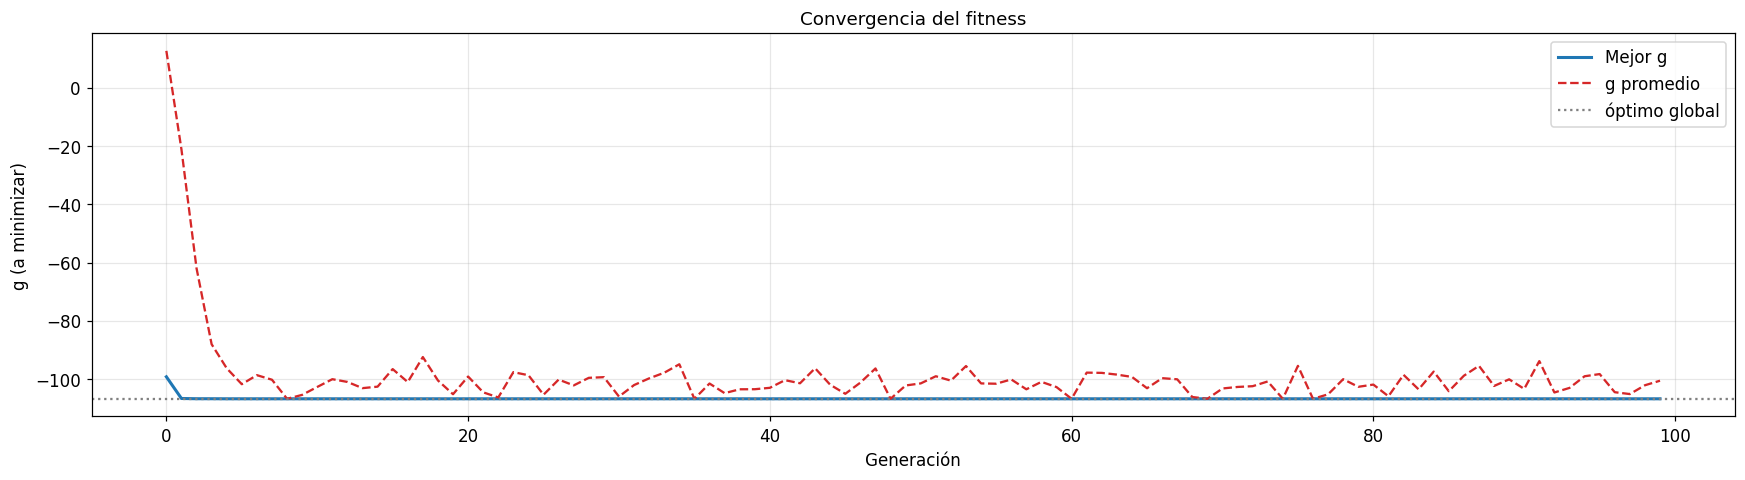

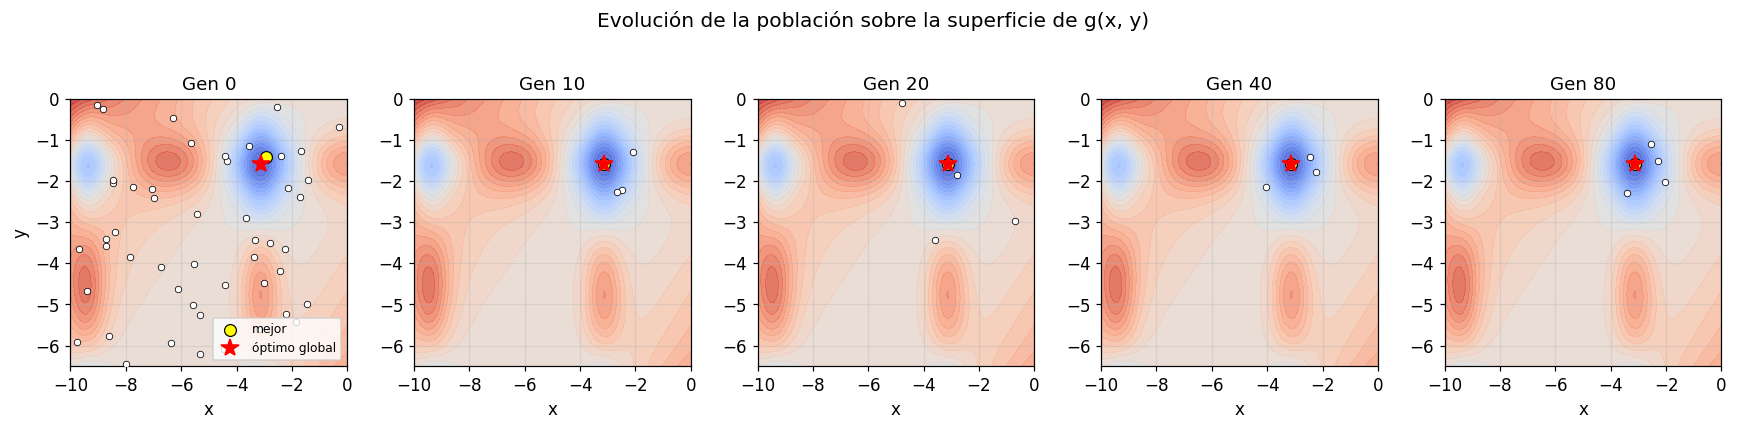

In [ ]:
gens_ref = [0, 10, 20, 40, 80]
ind, gmin, hb, hm, hd, snaps = ejecutar_ga_2d(seed=SEED, snapshots=set(gens_ref))
print(f"Óptimo real: g = {G_OPT:.6f}  en (x, y) = ({XY_OPT[0]:.4f}, {XY_OPT[1]:.4f})")
print(f"Óptimo AG:   g = {gmin:.6f}  en (x, y) = ({ind[0]:.4f}, {ind[1]:.4f})")
print(f"Error |g - g*| = {abs(gmin - G_OPT):.3e}")

fig, a1 = plt.subplots(1, 1, figsize=(16, 4.5))
a1.plot(hb, color='#1f77b4', lw=2, label='Mejor g')
a1.plot(hm, color='#d62728', lw=1.5, ls='--', label='g promedio')
a1.axhline(G_OPT, color='gray', ls=':', label='óptimo global')
a1.set_xlabel("Generación"); a1.set_ylabel("g (a minimizar)")
a1.set_title("Convergencia del fitness"); a1.legend()
plt.tight_layout(); plt.show()

# Evolución de la población sobre la superficie
fig2, axes = plt.subplots(1, len(gens_ref), figsize=(16, 3.8))
for ax, gen in zip(axes, gens_ref):
    cf = ax.contourf(XX, YY, ZZ, levels=30, cmap='coolwarm', alpha=0.85)
    P = snaps[gen]
    best_idx = np.argmin([g(p[0], p[1]) for p in P])
    ax.scatter(P[:, 0], P[:, 1], c='white', s=18, edgecolor='black', linewidth=0.5, zorder=3)
    ax.scatter(P[best_idx, 0], P[best_idx, 1], c='yellow', s=60, edgecolor='black',
               linewidth=0.8, zorder=4, label='mejor')
    ax.plot(*XY_OPT, 'r*', ms=12, zorder=5, label='óptimo global')
    ax.set_title(f"Gen {gen}")
    ax.set_xlabel("x"); ax.set_ylabel("y" if gen == gens_ref[0] else "")
    if gen == gens_ref[0]:
        ax.legend(fontsize=8, loc='lower right')
plt.suptitle("Evolución de la población sobre la superficie de g(x, y)", y=1.02)
plt.tight_layout(); plt.show()

Que la curva de *mejor g* descienda hasta estabilizarse en el valor de referencia, y que el *g promedio* la persiga acercándose parecen ser señales de que el AG funciona, el problema es que el mejor individuo se eligio por azar debido a el tamanio de la poblacion. El mejor individuo simplemente se encontro de casualidad, ya que existen demasiados dispersos por la superficie. La repentina bajada de las curvas y la evolucion visualizada en la superficie nos lo pueden confirmar. El elitismo es lo que hace parecer que tengamos exito, ya que se esta manteniendo ese primer individuo con mayor fitness.

---
**¿Qué aporta la visualización de la población sobre la superficie?**

La curva de fitness dice *cuánto* mejora el algoritmo generación a generación, pero no dice *cómo* ni *dónde* ocurre esa mejora. Los gráficos de evolución sobre la superficie aportan la dimensión espacial que la curva oculta:

- **Distribución inicial:** permite ver si la población cubre el dominio de forma razonablemente uniforme o si quedó concentrada en una región por azar, lo que condicionará todo el resto de la búsqueda.
- **Exploración vs. explotación:** se puede observar si la población visita varios valles simultáneamente (exploración sana) o si colapsa prematuramente sobre uno solo (convergencia prematura), algo que la curva de fitness no distingue — en ambos casos el mejor *g* puede descender igual de rápido al principio.
- **Identificación del valle correcto:** confirma visualmente si el individuo élite está cerca del mínimo global conocido o atrapado en un mínimo local, información que el valor numérico de *g* solo da si se compara con el óptimo exacto.
- **Velocidad de concentración:** la rapidez con que los puntos se agrupan indica si el elitismo y la selección están dominando la dinámica (convergencia rápida) o si la mutación mantiene diversidad activa más generaciones.

---
## 4. Tamaño de población y dimensionalidad

Medimos **confiabilidad** (porcentaje de éxito sobre 20 semillas independientes), donde "éxito" es terminar a menos de 0,5 del óptimo global.

    N      éxito      g medio      g mejor
------------------------------------------
   10    6/20        -100.512     -106.754
   20   14/20        -106.419     -106.762
   40   19/20        -106.662     -106.765
   80   20/20        -106.754     -106.765
  150   20/20        -106.764     -106.765


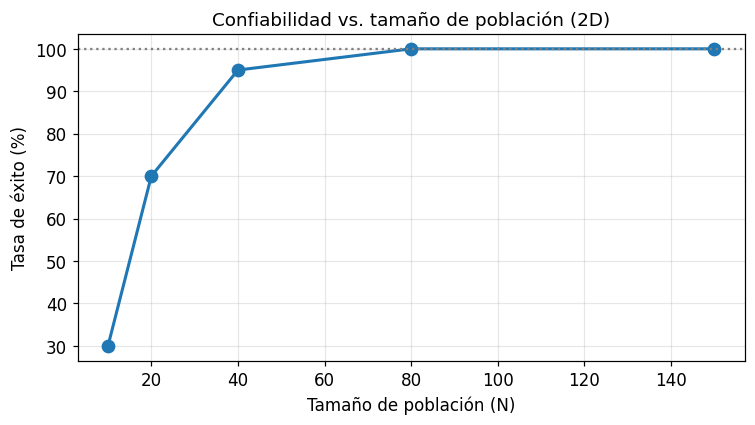

In [ ]:
def confiabilidad(N, n_seeds=20, tol=0.5, **kw):
    vals = []
    exitos = 0
    for s in range(n_seeds):
        _, gm, *_ = ejecutar_ga_2d(n_individuos=N, seed=s, **kw)
        vals.append(gm)
        if abs(gm - G_OPT) < tol: exitos += 1
    return exitos, n_seeds, np.mean(vals), np.min(vals)

print(f"{'N':>5} {'éxito':>10} {'g medio':>12} {'g mejor':>12}")
print("-"*42)
Ns = [10, 20, 40, 80, 150]; tasa = []
for N in Ns:
    e, t, gm, gb = confiabilidad(N)
    tasa.append(100*e/t)
    print(f"{N:>5} {e:>4}/{t:<5} {gm:>12.3f} {gb:>12.3f}")

plt.figure(figsize=(7, 4))
plt.plot(Ns, tasa, 'o-', color='#1f77b4', lw=2, ms=8)
plt.axhline(100, color='gray', ls=':')
plt.xlabel("Tamaño de población (N)"); plt.ylabel("Tasa de éxito (%)")
plt.title("Confiabilidad vs. tamaño de población (2D)")
plt.tight_layout(); plt.show()

**Análisis.** Con $N=10$ el AG es poco confiable (acierta una fracción de las corridas): una población tan chica no cubre los varios valles y a veces converge a un mínimo local. A partir de $N\approx20$ la búsqueda se vuelve mas confiable (éxito 16/20). Pero en $N=80$ se vuelve demasiado confiable, al punto de poder encontrarnos con el problema anterior.

Esto nos lleva a proponer el uso de una poblacion de 20 individuos, teniendo una tasa de exito decente sin transformar nuestro algoritmo denetico en un *random search*. Ademas reducimos el numero de generaciones excesivo.

Ademas podemos ver que en relacion con el problema anterior la poblacion necesaria no cambia de manera significativa. Esto debido a que el AG usa selección para dirigir la búsqueda hacia regiones prometedoras. No necesita representar todo el espacio, solo muestrearlo suficientemente bien al inicio. Sin embargo, se anticipa que la relación se vuelve marcadamente superlineal al escalar a 5 o más dimensiones, cuando el espacio de búsqueda crece lo suficiente como para que la población inicial deje de cubrir las regiones relevantes por azar.

Óptimo real: g = -106.764537  en (x, y) = (-3.1302, -1.5821)
Óptimo AG:   g = -106.761588  en (x, y) = (-3.1347, -1.5834)
Error |g - g*| = 2.948e-03


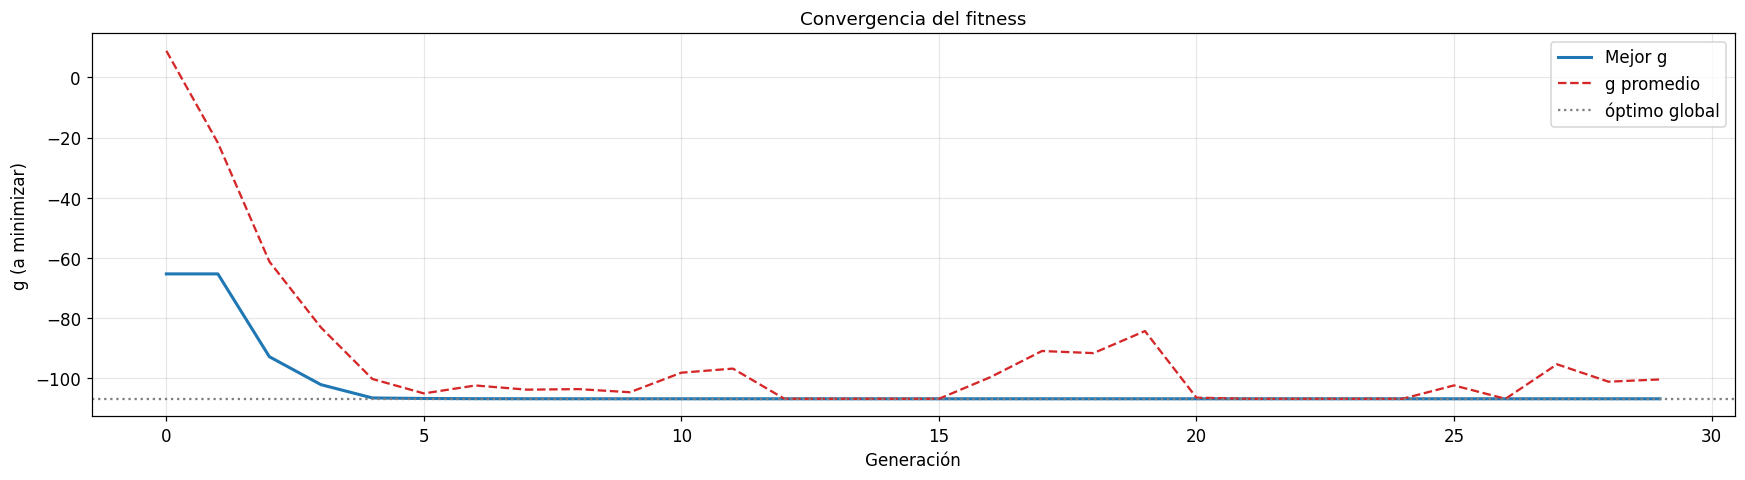

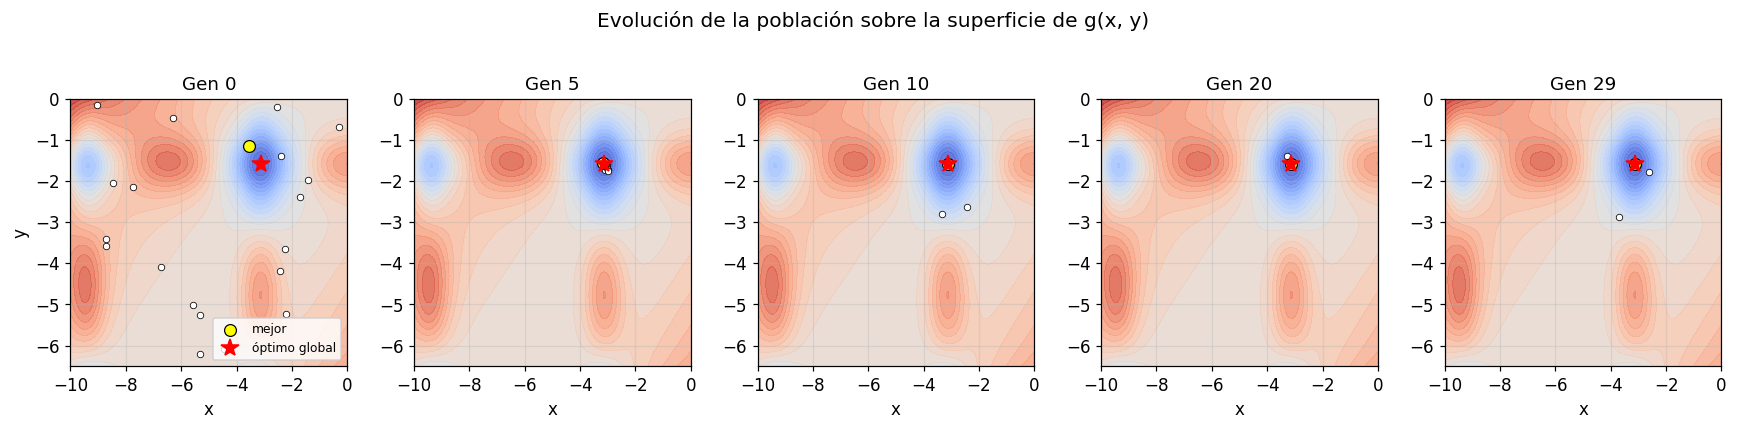

In [ ]:
gens_ref = [0, 5, 10, 20, 29]
ind, gmin, hb, hm, hd, snaps = ejecutar_ga_2d(n_generaciones=30,n_individuos=20, seed=SEED, snapshots=set(gens_ref))
print(f"Óptimo real: g = {G_OPT:.6f}  en (x, y) = ({XY_OPT[0]:.4f}, {XY_OPT[1]:.4f})")
print(f"Óptimo AG:   g = {gmin:.6f}  en (x, y) = ({ind[0]:.4f}, {ind[1]:.4f})")
print(f"Error |g - g*| = {abs(gmin - G_OPT):.3e}")

fig, a1 = plt.subplots(1, 1, figsize=(16, 4.5))
a1.plot(hb, color='#1f77b4', lw=2, label='Mejor g')
a1.plot(hm, color='#d62728', lw=1.5, ls='--', label='g promedio')
a1.axhline(G_OPT, color='gray', ls=':', label='óptimo global')
a1.set_xlabel("Generación"); a1.set_ylabel("g (a minimizar)")
a1.set_title("Convergencia del fitness"); a1.legend()
plt.tight_layout(); plt.show()

# Evolución de la población sobre la superficie
fig2, axes = plt.subplots(1, len(gens_ref), figsize=(16, 3.8))
for ax, gen in zip(axes, gens_ref):
    cf = ax.contourf(XX, YY, ZZ, levels=30, cmap='coolwarm', alpha=0.85)
    P = snaps[gen]
    best_idx = np.argmin([g(p[0], p[1]) for p in P])
    ax.scatter(P[:, 0], P[:, 1], c='white', s=18, edgecolor='black', linewidth=0.5, zorder=3)
    ax.scatter(P[best_idx, 0], P[best_idx, 1], c='yellow', s=60, edgecolor='black',
               linewidth=0.8, zorder=4, label='mejor')
    ax.plot(*XY_OPT, 'r*', ms=12, zorder=5, label='óptimo global')
    ax.set_title(f"Gen {gen}")
    ax.set_xlabel("x"); ax.set_ylabel("y" if gen == gens_ref[0] else "")
    if gen == gens_ref[0]:
        ax.legend(fontsize=8, loc='lower right')
plt.suptitle("Evolución de la población sobre la superficie de g(x, y)", y=1.02)
plt.tight_layout(); plt.show()

---

## 5. Probabilidad de mutación: rango útil y modos de falla

 sigma  p_mut    éxito    g medio
------------------------------------
  0.10   0.05  15/20    -103.913
  0.10   0.10  18/20    -106.005
  0.10   0.20  19/20    -106.697
  0.10   0.50  20/20    -106.764
  0.10   0.90  20/20    -106.762
  0.30   0.05  12/20    -106.082
  0.30   0.10  19/20    -106.627
  0.30   0.20  20/20    -106.717
  0.30   0.50  20/20    -106.759
  0.30   0.90  20/20    -106.735
  0.60   0.05   8/20    -105.537
  0.60   0.10   8/20    -105.941
  0.60   0.20  13/20    -106.279
  0.60   0.50  20/20    -106.752
  0.60   0.90  18/20    -106.567
  1.00   0.05   6/20    -103.302
  1.00   0.10   9/20    -104.868
  1.00   0.20  16/20    -106.212
  1.00   0.50  20/20    -106.731
  1.00   0.90  18/20    -106.505
  2.00   0.05   7/20     -95.513
  2.00   0.10   7/20    -101.537
  2.00   0.20  12/20    -105.169
  2.00   0.50  19/20    -106.690
  2.00   0.90   9/20    -105.526


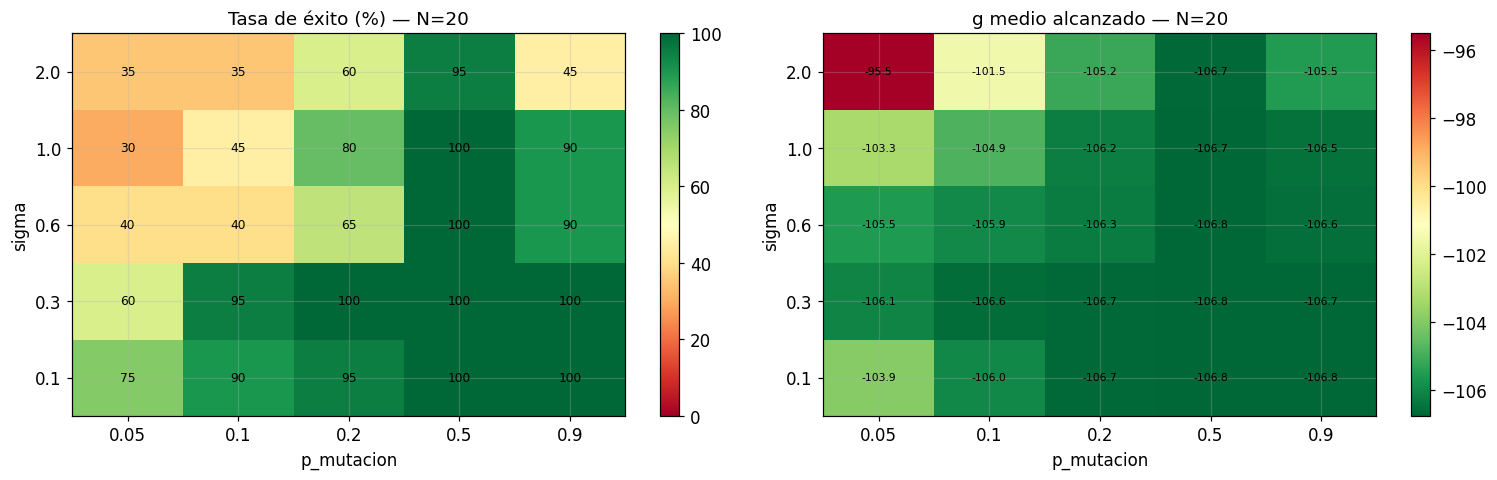

In [ ]:
pmuts  = [0.05, 0.1, 0.2, 0.5, 0.9]
sigmas = [0.1, 0.3, 0.6, 1.0, 2.0]

tasa_grid  = np.zeros((len(sigmas), len(pmuts)))
gmedio_grid = np.zeros((len(sigmas), len(pmuts)))

print(f"{'sigma':>6} {'p_mut':>6} {'éxito':>8} {'g medio':>10}")
print("-"*36)
for i, sig in enumerate(sigmas):
    for j, pm in enumerate(pmuts):
        e, t, gm, _ = confiabilidad(20,n_generaciones=30,p_mutacion=pm, sigma=sig)
        tasa_grid[i, j]   = 100 * e / t
        gmedio_grid[i, j] = gm
        print(f"{sig:>6.2f} {pm:>6.2f}  {e:>2}/{t:<2}  {gm:>10.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

im1 = ax1.imshow(tasa_grid, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100, origin='lower')
ax1.set_xticks(range(len(pmuts)));  ax1.set_xticklabels(pmuts)
ax1.set_yticks(range(len(sigmas))); ax1.set_yticklabels(sigmas)
ax1.set_xlabel("p_mutacion"); ax1.set_ylabel("sigma")
ax1.set_title("Tasa de éxito (%) — N=20")
plt.colorbar(im1, ax=ax1)
for i in range(len(sigmas)):
    for j in range(len(pmuts)):
        ax1.text(j, i, f"{tasa_grid[i,j]:.0f}", ha='center', va='center', fontsize=8)

im2 = ax2.imshow(gmedio_grid, aspect='auto', cmap='RdYlGn_r', origin='lower')
ax2.set_xticks(range(len(pmuts)));  ax2.set_xticklabels(pmuts)
ax2.set_yticks(range(len(sigmas))); ax2.set_yticklabels(sigmas)
ax2.set_xlabel("p_mutacion"); ax2.set_ylabel("sigma")
ax2.set_title("g medio alcanzado — N=20")
plt.colorbar(im2, ax=ax2)
for i in range(len(sigmas)):
    for j in range(len(pmuts)):
        ax2.text(j, i, f"{gmedio_grid[i,j]:.1f}", ha='center', va='center', fontsize=7)

plt.tight_layout(); plt.show()

**Análisis del barrido conjunto p\_mutacion × sigma con 30 generaciones y poblacion de N = 20.**

- **La influencia de `sigma`:** los pasos de mutación cortos no parecen tener muhos problemas para escapar de valles locales, y es mas efectivos con alta probabilidad de mutación. Mientras que si se dan pasos muy grandes, los individuos mutados saltan fuera del valle óptimo con frecuencia; el elitismo amortigua el daño pero la calidad media cae y la convergencia se vuelve errática.

- **`p_mutacion` problematico:** los valores de mutacion bajos parecen dar algunos problemas, tal vez porque se estanquen en un minimo local (Convergencia Prematura) o tal vez porque nuestro problema es mas sensible a el largo de los pasos que a la cantidad.

- **Zona útil:** la combinación `p_mutacion` ≈ 0.5 con `sigma` ≈ 0.4 concentra los mejores resultados en ambos mapas. Al rededor de este punto, las variaciones de tasa de éxito y g medio son pequeñas, lo que indica robustez a la configuración exacta.

- **Interacción:** `p_mutacion` y `sigma` no son independientes — una `p_mutacion` alta con `sigma` pequeño equivale a muchos pasos de exploración cortos (exploración local intensa); una `p_mutacion` baja con `sigma` grande equivale a pocos saltos grandes (exploración global esporádica). Ambas combinaciones extremas son peores que el punto intermedio.

- **Comparacion Ejercicio 1:** En este caso una mutacion mas alta nos sirvio para poder encontrar el mejor fitness en un espacio de exploracion mas amplio que en el ejercicio anterior, donde la probabilidad de mutacion optima se encontraba en `p_mutacion` ≈ 0,05 - 0,15

Óptimo real: g = -106.764537  en (x, y) = (-3.1302, -1.5821)
Óptimo AG:   g = -106.730121  en (x, y) = (-3.1203, -1.5698)
Error |g - g*| = 3.442e-02


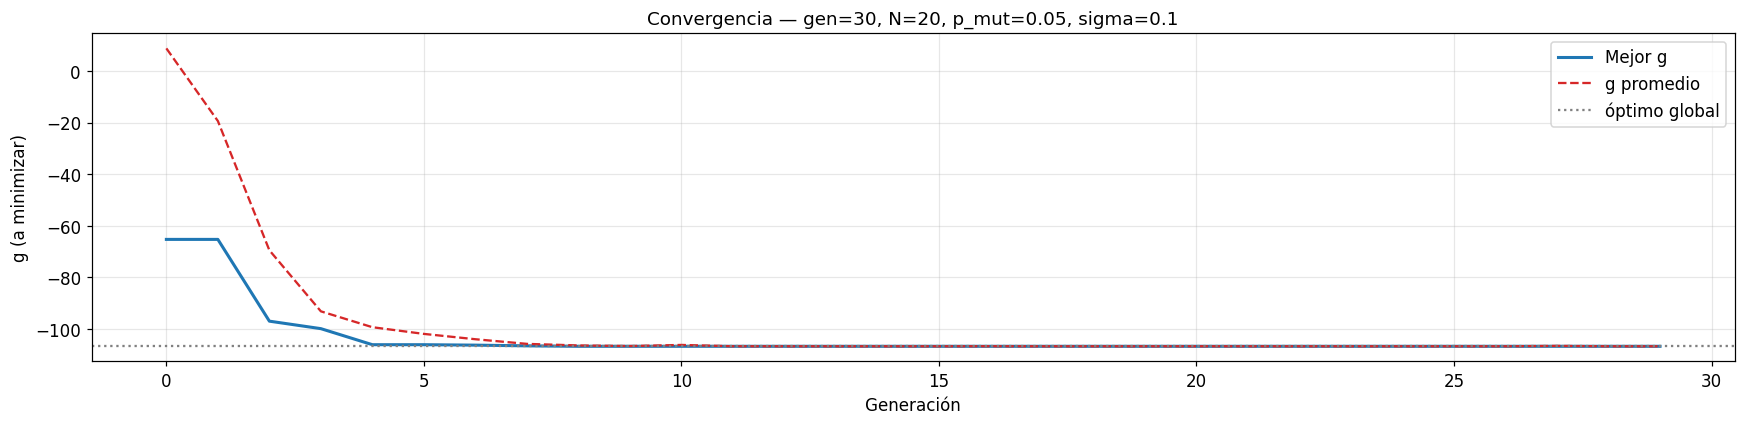

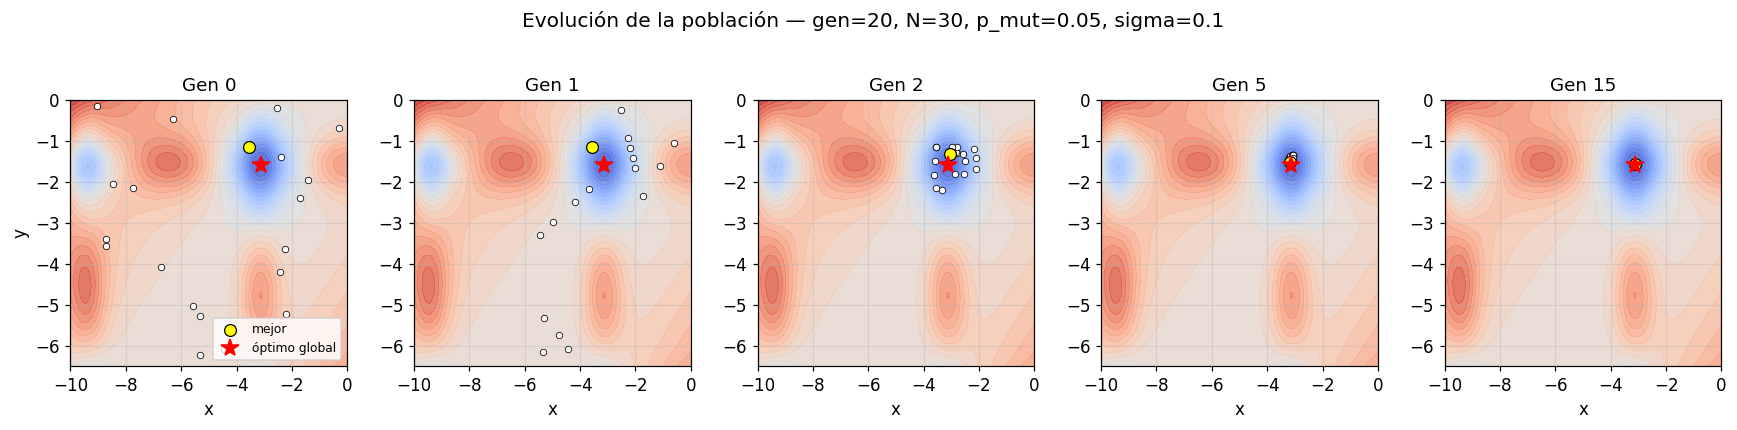

In [ ]:
# Caso extremo: generaciones=30, N=20, p_mutacion=0.05, sigma=0.1
gens_caso = [0, 1, 2, 5, 15]
ind_c, gmin_c, hb_c, hm_c, hd_c, snaps_c = ejecutar_ga_2d(
    n_generaciones=30, n_individuos=20, p_mutacion=0.05, sigma=0.1,
    seed=SEED, snapshots=set(gens_caso)
)
print(f"Óptimo real: g = {G_OPT:.6f}  en (x, y) = ({XY_OPT[0]:.4f}, {XY_OPT[1]:.4f})")
print(f"Óptimo AG:   g = {gmin_c:.6f}  en (x, y) = ({ind_c[0]:.4f}, {ind_c[1]:.4f})")
print(f"Error |g - g*| = {abs(gmin_c - G_OPT):.3e}")

# --- Curva de convergencia ---
fig, a1 = plt.subplots(1, 1, figsize=(16, 4))
a1.plot(hb_c, color='#1f77b4', lw=2, label='Mejor g')
a1.plot(hm_c, color='#d62728', lw=1.5, ls='--', label='g promedio')
a1.axhline(G_OPT, color='gray', ls=':', label='óptimo global')
a1.set_xlabel("Generación"); a1.set_ylabel("g (a minimizar)")
a1.set_title("Convergencia — gen=30, N=20, p_mut=0.05, sigma=0.1")
a1.legend()
plt.tight_layout(); plt.show()

# --- Evolución sobre la superficie ---
fig2, axes = plt.subplots(1, len(gens_caso), figsize=(16, 3.8))
for ax, gen in zip(axes, gens_caso):
    ax.contourf(XX, YY, ZZ, levels=30, cmap='coolwarm', alpha=0.85)
    P = snaps_c[gen]
    best_idx = np.argmin([g(p[0], p[1]) for p in P])
    ax.scatter(P[:, 0], P[:, 1], c='white', s=18, edgecolor='black', linewidth=0.5, zorder=3)
    ax.scatter(P[best_idx, 0], P[best_idx, 1], c='yellow', s=60, edgecolor='black',
               linewidth=0.8, zorder=4, label='mejor')
    ax.plot(*XY_OPT, 'r*', ms=12, zorder=5, label='óptimo global')
    ax.set_title(f"Gen {gen}")
    ax.set_xlabel("x"); ax.set_ylabel("y" if gen == gens_caso[0] else "")
    if gen == gens_caso[0]:
        ax.legend(fontsize=8, loc='lower right')
plt.suptitle("Evolución de la población — gen=20, N=30, p_mut=0.05, sigma=0.1", y=1.02)
plt.tight_layout(); plt.show()

Analizando este caso, con una `p_mutacion` = 0.05 y `sigma` = 0.1, podemos confirmar que la cantidad de mutaciones por generacion no es la que mas afecta a nuestro problema, sino el largo de los pasos (`sigma`).

---


## 6. Probabilidad de cruce: rango útil y modos de falla

Pregunta guía: ¿cómo afecta `p_cruce` a la convergencia y la calidad del resultado, manteniendo fijos los parámetros óptimos identificados (`N=30`, `n_generaciones=20`, `p_mutacion=0.5`, `sigma=0.3`)?

 p_cruce    éxito      g medio      g mejor
--------------------------------------------
    0.00  20/20      -106.584      -106.763
    0.10  19/20      -106.678      -106.761
    0.30  20/20      -106.744      -106.765
    0.50  20/20      -106.737      -106.765
    0.70  20/20      -106.755      -106.765
    0.85  20/20      -106.758      -106.765
    0.95  20/20      -106.759      -106.765
    1.00  20/20      -106.756      -106.765


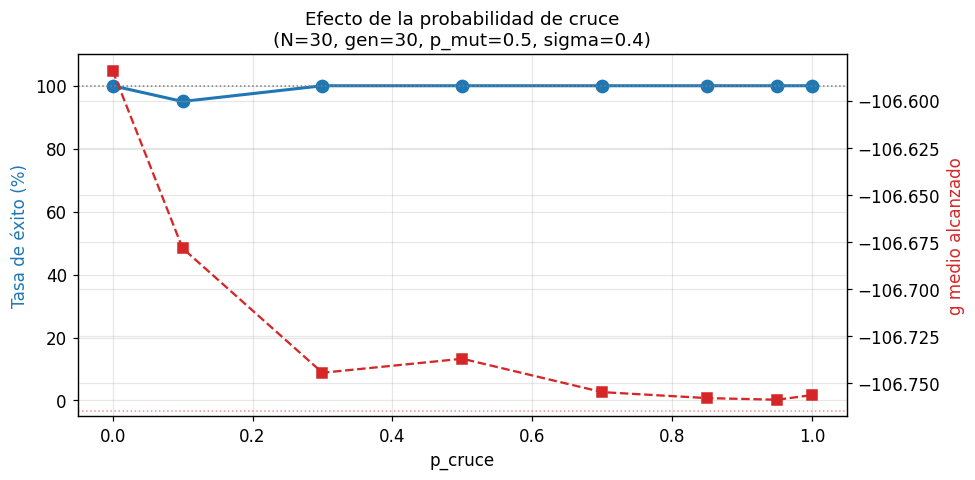

In [ ]:
# Parámetros óptimos fijos
N_OPT       = 20
PMUT_OPT    = 0.5
SIGMA_OPT   = 0.4

pcruce_vals = [0.0, 0.1, 0.3, 0.5, 0.7, 0.85, 0.95, 1.0]
tasa_c  = []
medio_c = []

print(f"{'p_cruce':>8} {'éxito':>8} {'g medio':>12} {'g mejor':>12}")
print("-"*44)
for pc in pcruce_vals:
    e, t, gm, gb = confiabilidad(N_OPT, n_generaciones=30,
                                  p_mutacion=PMUT_OPT, sigma=SIGMA_OPT,
                                  p_cruce=pc)
    tasa_c.append(100 * e / t)
    medio_c.append(gm)
    print(f"{pc:>8.2f}  {e:>2}/{t:<2}  {gm:>12.3f}  {gb:>12.3f}")

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(pcruce_vals, tasa_c, 'o-', color='#1f77b4', lw=2, ms=8)
ax1.axhline(100, color='gray', ls=':', lw=1)
ax1.set_xlabel("p_cruce"); ax1.set_ylabel("Tasa de éxito (%)", color='#1f77b4')
ax1.set_title("Efecto de la probabilidad de cruce\n(N=30, gen=30, p_mut=0.5, sigma=0.4)")
ax1.set_ylim(-5, 110)

ax2 = ax1.twinx()
ax2.plot(pcruce_vals, medio_c, 's--', color='#d62728', lw=1.5, ms=7)
ax2.set_ylabel("g medio alcanzado", color='#d62728')
ax2.axhline(G_OPT, color='#d62728', ls=':', lw=1, alpha=0.5)

plt.tight_layout(); plt.show()

**Análisis del barrido de probabilidad de cruce.**

- **`p_cruce` bajo (≈0.1–0.2):** pocos pares se cruzan; la mayor parte de la descendencia son copias directas. La exploración del espacio es limitada y la convergencia es más lenta.
- **`p_cruce = 1.0` (cruce siempre):** todos los pares se cruzan en cada generación. En problemas con un único óptimo pronunciado esto funciona bien, pero puede introducir inestabilidad si los padres son muy distintos entre sí, ya que los hijos quedan en posiciones intermedias que pueden estar lejos de ambos óptimos locales.

- **Zona útil (≈0.3–0.7):** el cruce ocurre con suficiente frecuencia para mezclar individuos de distintas regiones del espacio, acelerando la convergencia hacia el óptimo. La tasa de éxito y el g medio alcanzan sus mejores valores en este rango.

El cruce aritmetico en este caso, tiene la caracteristica de que los hijos caen en el segmento que une a los dos padres en el espacio 2D. Esto tiene una consecuencia importante: el cruce solo puede generar puntos dentro del casco convexo de la población actual. Si todos los individuos están en un valle, el cruce no puede salir de él, razon por la que es mas conveniente usar una probabilidad menor que en el ejercicio anterior.

Óptimo real: g = -106.764537  en (x, y) = (-3.1302, -1.5821)
Óptimo AG:   g = -106.759501  en (x, y) = (-3.1356, -1.5850)
Error |g - g*| = 5.036e-03


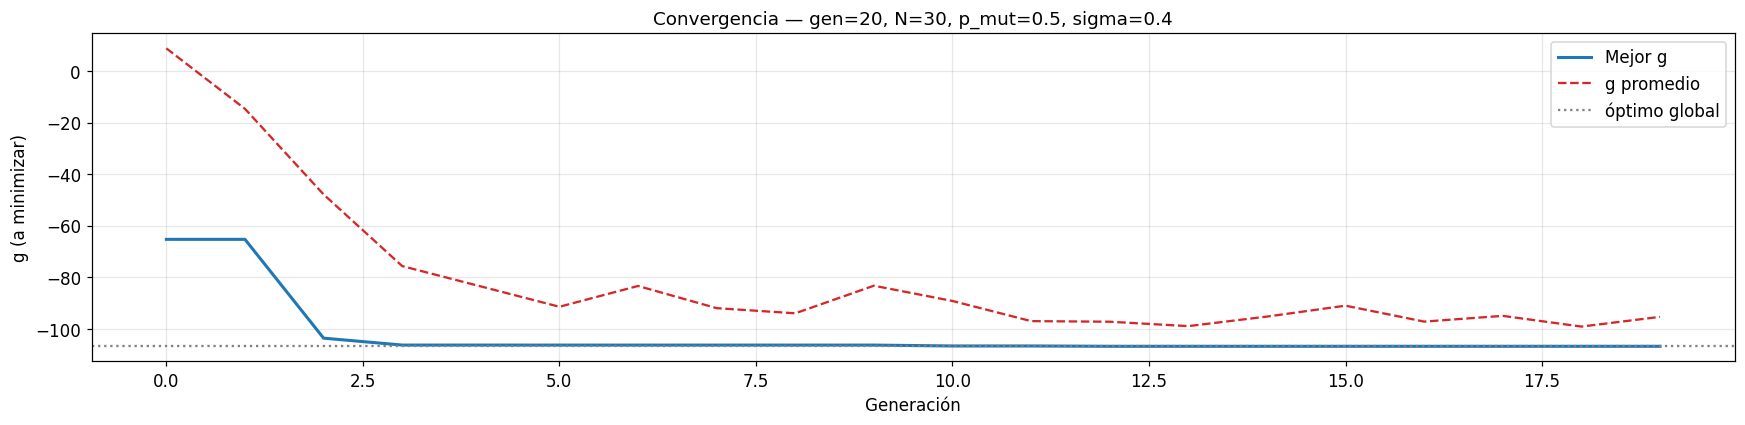

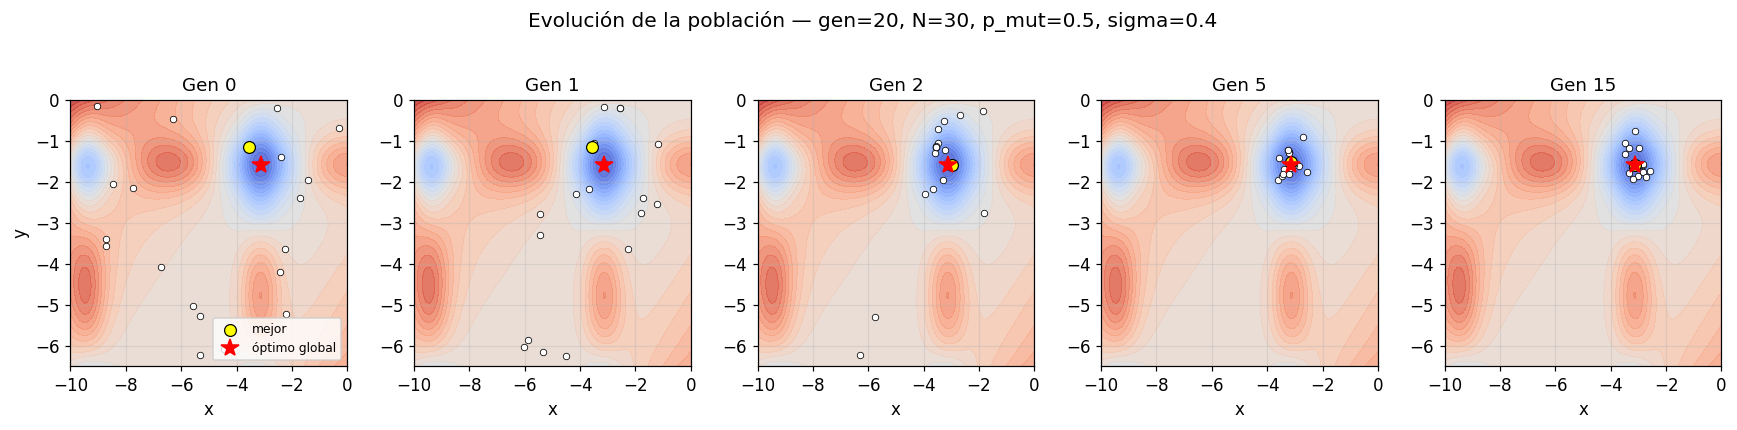

In [ ]:
gens_caso = [0, 1, 2, 5, 15]
ind_c, gmin_c, hb_c, hm_c, hd_c, snaps_c = ejecutar_ga_2d(
    n_generaciones=20, n_individuos=20, p_mutacion=0.5, sigma=0.4, p_cruce=0.5,
    seed=SEED, snapshots=set(gens_caso)
)
print(f"Óptimo real: g = {G_OPT:.6f}  en (x, y) = ({XY_OPT[0]:.4f}, {XY_OPT[1]:.4f})")
print(f"Óptimo AG:   g = {gmin_c:.6f}  en (x, y) = ({ind_c[0]:.4f}, {ind_c[1]:.4f})")
print(f"Error |g - g*| = {abs(gmin_c - G_OPT):.3e}")

# --- Curva de convergencia ---
fig, a1 = plt.subplots(1, 1, figsize=(16, 4))
a1.plot(hb_c, color='#1f77b4', lw=2, label='Mejor g')
a1.plot(hm_c, color='#d62728', lw=1.5, ls='--', label='g promedio')
a1.axhline(G_OPT, color='gray', ls=':', label='óptimo global')
a1.set_xlabel("Generación"); a1.set_ylabel("g (a minimizar)")
a1.set_title("Convergencia — gen=20, N=30, p_mut=0.5, sigma=0.4")
a1.legend()
plt.tight_layout(); plt.show()

# --- Evolución sobre la superficie ---
fig2, axes = plt.subplots(1, len(gens_caso), figsize=(16, 3.8))
for ax, gen in zip(axes, gens_caso):
    ax.contourf(XX, YY, ZZ, levels=30, cmap='coolwarm', alpha=0.85)
    P = snaps_c[gen]
    best_idx = np.argmin([g(p[0], p[1]) for p in P])
    ax.scatter(P[:, 0], P[:, 1], c='white', s=18, edgecolor='black', linewidth=0.5, zorder=3)
    ax.scatter(P[best_idx, 0], P[best_idx, 1], c='yellow', s=60, edgecolor='black',
               linewidth=0.8, zorder=4, label='mejor')
    ax.plot(*XY_OPT, 'r*', ms=12, zorder=5, label='óptimo global')
    ax.set_title(f"Gen {gen}")
    ax.set_xlabel("x"); ax.set_ylabel("y" if gen == gens_caso[0] else "")
    if gen == gens_caso[0]:
        ax.legend(fontsize=8, loc='lower right')
plt.suptitle("Evolución de la población — gen=20, N=30, p_mut=0.5, sigma=0.4", y=1.02)
plt.tight_layout(); plt.show()

Podemos ver que al disminuir la probabilidad de cruce, conseguimos mayor diversidad en los valores de la poblacion, obteninendo mayor robustez al estancamiento.

---


## 7. Cambiando las Restricciones del Dominio

Hasta ahora el AG operó dentro del dominio canónico $x\in[-10,0]$, $y\in[-6{,}5,0]$, donde existe un único óptimo global verificable. En esta sección exploramos qué ocurre al modificar esas restricciones en dos direcciones opuestas:

1. **Dominio reducido** $[-12,4]\times[-7,3]$: sigue conteniendo el óptimo global en $(-3{,}13,-1{,}58)$ pero excluye los equivalentes periódicos más cercanos (en $\approx(-9{,}41,-7{,}86)$ y $\approx(3{,}15,4{,}70)$). El problema conserva un único mínimo global rodeado de varios locales — el escenario más exigente para un AG.

2. **Dominio amplio** $[-50,50]^2$: la periodicidad de seno y coseno hace que el valor mínimo $-106{,}76$ se repita infinitas veces a lo largo de la diagonal $x-y\approx\text{cte}$, cada $\approx 2\pi$ unidades. El problema deja de tener un único óptimo verificable y el AG puede "acertar" convergiendo a cualquiera de ellos.

Óptimo real: g = -106.764537  en (x, y) = (-3.1302, -1.5821)
Óptimo AG:   g = -106.760755  en (x, y) = (-3.1250, -1.5821)
Error |g - g*| = 3.781e-03


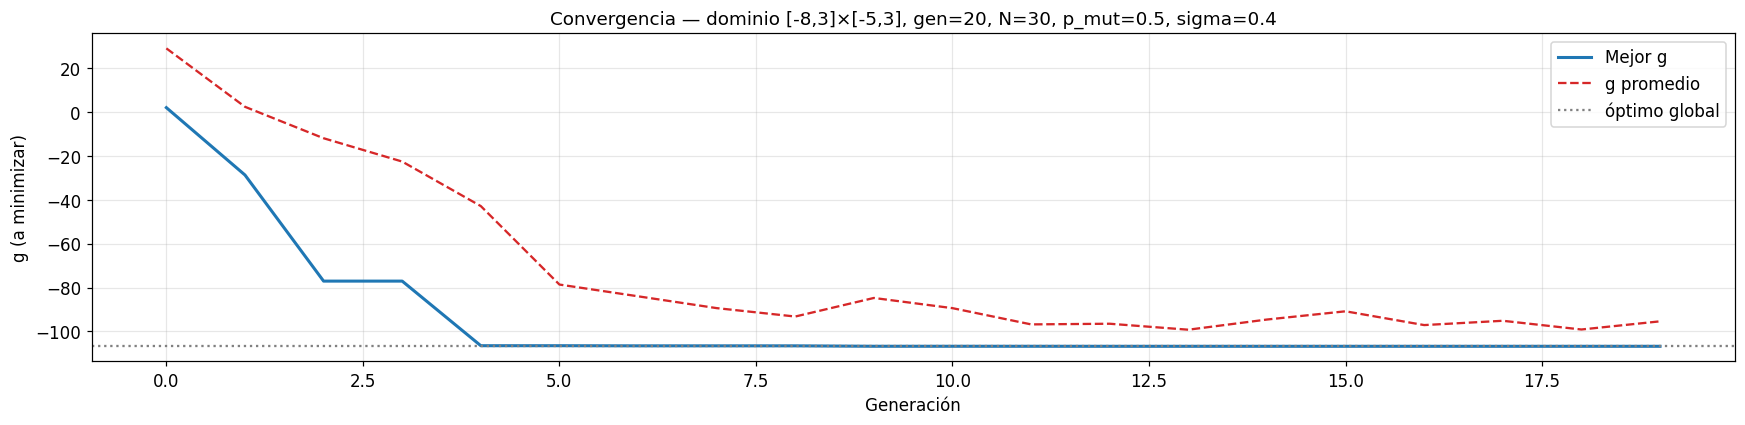

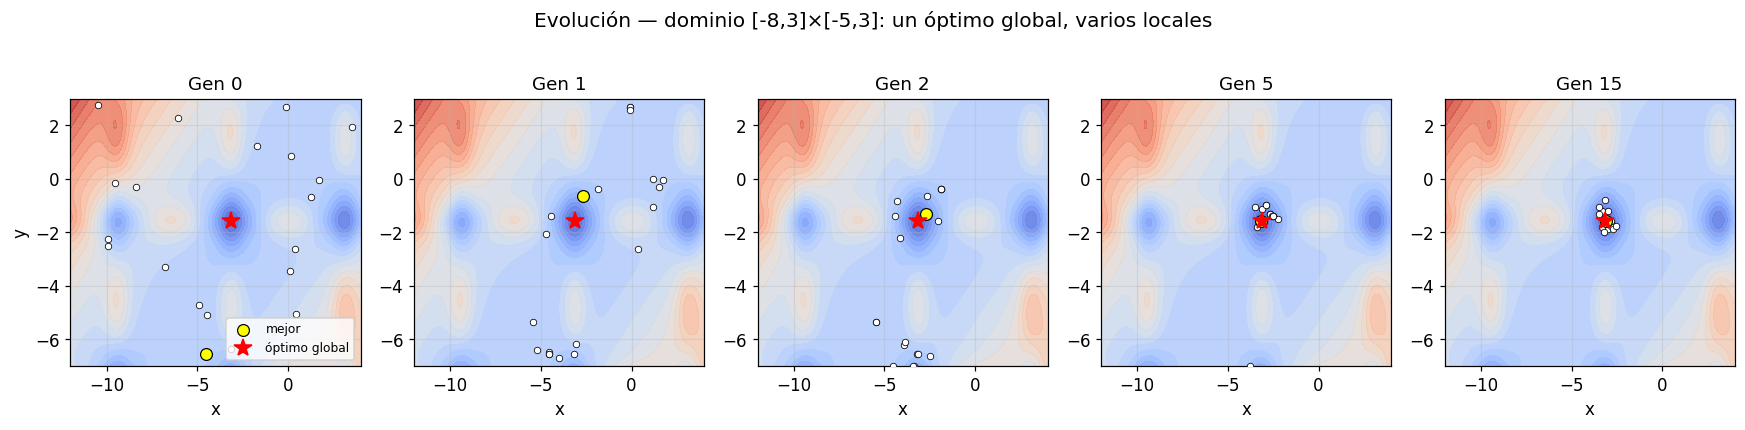

In [ ]:
BMIN_UNICO = np.array([-12.0, -7.0]); BMAX_UNICO = np.array([4.0, 3.0])

# Visualización del paisaje en el nuevo dominio
xu = np.linspace(BMIN_UNICO[0], BMAX_UNICO[0], 400)
yu = np.linspace(BMIN_UNICO[1], BMAX_UNICO[1], 400)
XU, YU = np.meshgrid(xu, yu); ZU = g(XU, YU)

gens_caso_u = [0, 1, 2, 5, 15]
ind_u, gmin_u, hb_u, hm_u, hd_u, snaps_u = ejecutar_ga_2d(
    n_generaciones=20, n_individuos=20, p_mutacion=0.5, sigma=0.4, p_cruce=0.5,
    bmin=BMIN_UNICO, bmax=BMAX_UNICO,
    seed=SEED, snapshots=set(gens_caso_u)
)
print(f"Óptimo real: g = {G_OPT:.6f}  en (x, y) = ({XY_OPT[0]:.4f}, {XY_OPT[1]:.4f})")
print(f"Óptimo AG:   g = {gmin_u:.6f}  en (x, y) = ({ind_u[0]:.4f}, {ind_u[1]:.4f})")
print(f"Error |g - g*| = {abs(gmin_u - G_OPT):.3e}")

# --- Curva de convergencia ---
fig, a1 = plt.subplots(1, 1, figsize=(16, 4))
a1.plot(hb_u, color='#1f77b4', lw=2, label='Mejor g')
a1.plot(hm_u, color='#d62728', lw=1.5, ls='--', label='g promedio')
a1.axhline(G_OPT, color='gray', ls=':', label='óptimo global')
a1.set_xlabel("Generación"); a1.set_ylabel("g (a minimizar)")
a1.set_title("Convergencia — dominio [-8,3]×[-5,3], gen=20, N=30, p_mut=0.5, sigma=0.4")
a1.legend()
plt.tight_layout(); plt.show()

# --- Evolución sobre la superficie ---
fig2, axes = plt.subplots(1, len(gens_caso_u), figsize=(16, 3.8))
for ax, gen in zip(axes, gens_caso_u):
    ax.contourf(XU, YU, ZU, levels=30, cmap='coolwarm', alpha=0.85)
    P = snaps_u[gen]
    best_idx = np.argmin([g(p[0], p[1]) for p in P])
    ax.scatter(P[:, 0], P[:, 1], c='white', s=18, edgecolor='black', linewidth=0.5, zorder=3)
    ax.scatter(P[best_idx, 0], P[best_idx, 1], c='yellow', s=60, edgecolor='black',
               linewidth=0.8, zorder=4, label='mejor')
    ax.plot(*XY_OPT, 'r*', ms=12, zorder=5, label='óptimo global')
    ax.set_title(f"Gen {gen}")
    ax.set_xlabel("x"); ax.set_ylabel("y" if gen == gens_caso_u[0] else "")
    if gen == gens_caso_u[0]:
        ax.legend(fontsize=8, loc='lower right')
plt.suptitle("Evolución — dominio [-8,3]×[-5,3]: un óptimo global, varios locales", y=1.02)
plt.tight_layout(); plt.show()

**Dominio $[-8,3]\times[-5,3]$ — un único óptimo global con varios locales.**

Este es el escenario más exigente desde el punto de vista del AG: el espacio es más amplio que el dominio original (área $\approx 3{,}6\times$ mayor), contiene más mínimos locales visibles, pero sigue teniendo un único mínimo global. Cualquier corrida que converja a un valle incorrecto cuenta como fallo.

Que el AG encuentre el óptimo global en este contexto confirma que los operadores no están simplemente muestreando el dominio al azar: la selección por torneo atrae la población hacia los valles más profundos y la mutación le permite escapar de los locales antes de comprometerse. Si el resultado empeorase significativamente respecto al dominio original, indicaría que la población inicial ya no cubre las regiones relevantes con suficiente densidad — señal de que habría que aumentar $N$ o $\sigma$.

Óptimo real: g = -106.764537  en (x, y) = (-3.1302, -1.5821)
Óptimo AG:   g = -106.758000  en (x, y) = (9.4316, 10.9894)
Error |g - g*| = 6.537e-03


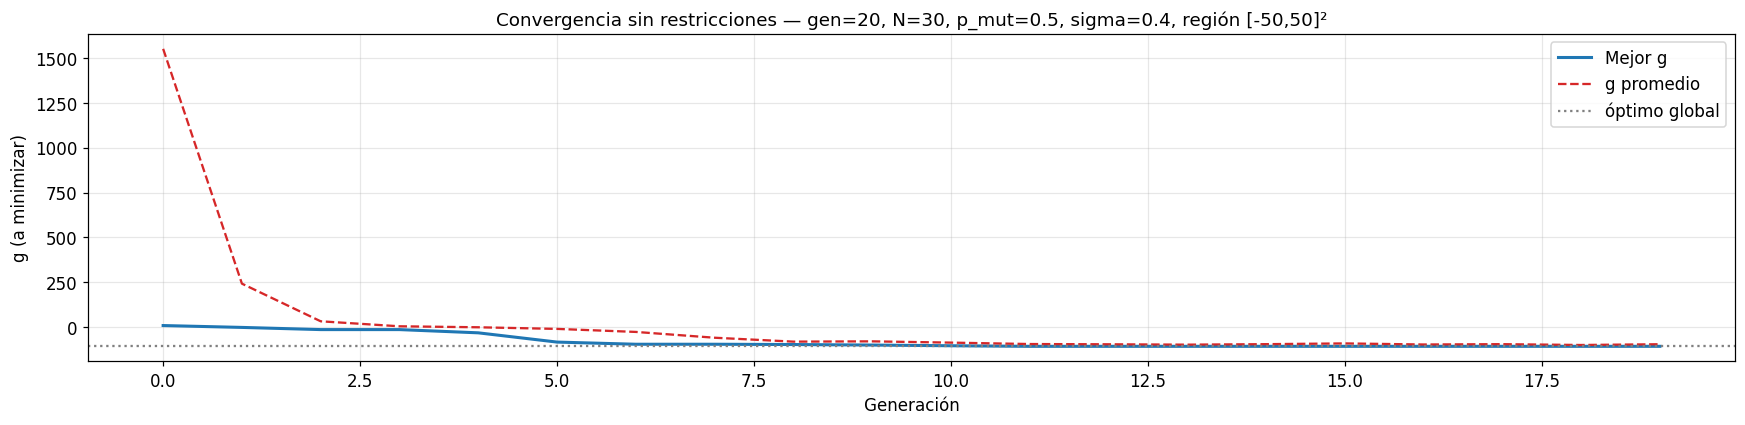

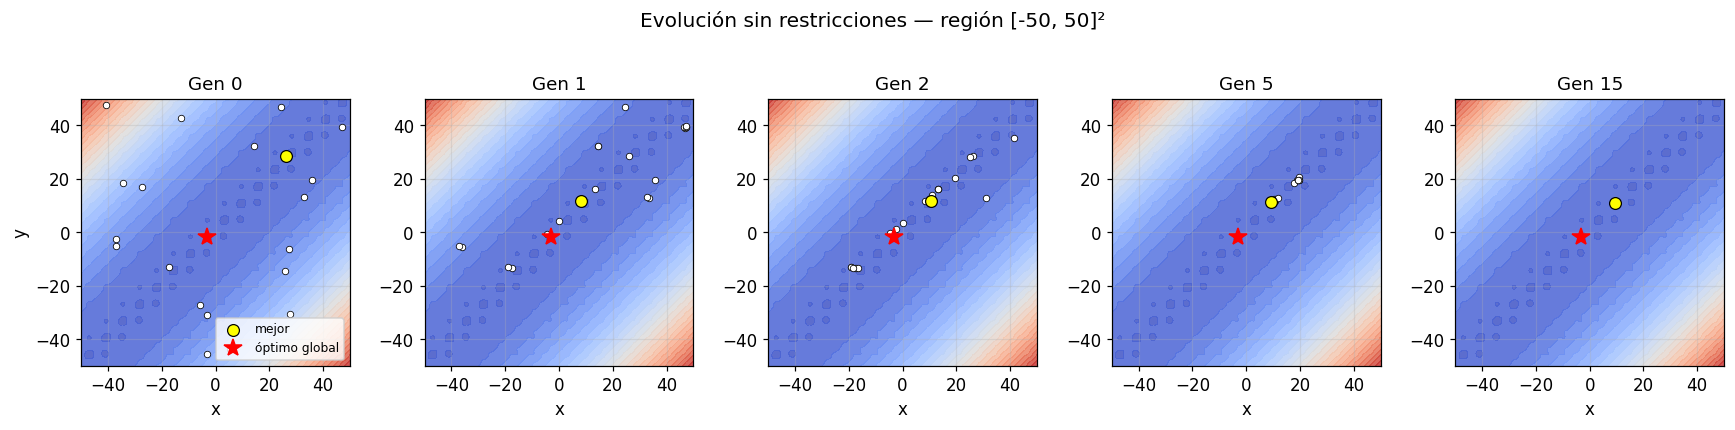

In [ ]:
WIDE_MIN = np.array([-50.0, -50.0]); WIDE_MAX = np.array([50.0, 50.0])

# Visualización del paisaje amplio
xw = np.linspace(-50, 50, 400); yw = np.linspace(-50, 50, 400)
XW, YW = np.meshgrid(xw, yw); ZW = g(XW, YW)

gens_caso_w = [0, 1, 2, 5, 15]
ind_w, gmin_w, hb_w, hm_w, hd_w, snaps_w = ejecutar_ga_2d(
    n_generaciones=20, n_individuos=20, p_mutacion=0.5, sigma=0.4, p_cruce=0.5,
    bmin=WIDE_MIN, bmax=WIDE_MAX,
    seed=SEED, snapshots=set(gens_caso_w)
)
print(f"Óptimo real: g = {G_OPT:.6f}  en (x, y) = ({XY_OPT[0]:.4f}, {XY_OPT[1]:.4f})")
print(f"Óptimo AG:   g = {gmin_w:.6f}  en (x, y) = ({ind_w[0]:.4f}, {ind_w[1]:.4f})")
print(f"Error |g - g*| = {abs(gmin_w - G_OPT):.3e}")

# --- Curva de convergencia ---
fig, a1 = plt.subplots(1, 1, figsize=(16, 4))
a1.plot(hb_w, color='#1f77b4', lw=2, label='Mejor g')
a1.plot(hm_w, color='#d62728', lw=1.5, ls='--', label='g promedio')
a1.axhline(G_OPT, color='gray', ls=':', label='óptimo global')
a1.set_xlabel("Generación"); a1.set_ylabel("g (a minimizar)")
a1.set_title("Convergencia sin restricciones — gen=20, N=30, p_mut=0.5, sigma=0.4, región [-50,50]²")
a1.legend()
plt.tight_layout(); plt.show()

# --- Evolución sobre la superficie amplia ---
fig2, axes = plt.subplots(1, len(gens_caso_w), figsize=(16, 3.8))
for ax, gen in zip(axes, gens_caso_w):
    ax.contourf(XW, YW, ZW, levels=30, cmap='coolwarm', alpha=0.85)
    P = snaps_w[gen]
    best_idx = np.argmin([g(p[0], p[1]) for p in P])
    ax.scatter(P[:, 0], P[:, 1], c='white', s=18, edgecolor='black', linewidth=0.5, zorder=3)
    ax.scatter(P[best_idx, 0], P[best_idx, 1], c='yellow', s=60, edgecolor='black',
               linewidth=0.8, zorder=4, label='mejor')
    ax.plot(*XY_OPT, 'r*', ms=12, zorder=5, label='óptimo global')
    ax.set_title(f"Gen {gen}")
    ax.set_xlabel("x"); ax.set_ylabel("y" if gen == gens_caso_w[0] else "")
    if gen == gens_caso_w[0]:
        ax.legend(fontsize=8, loc='lower right')
plt.suptitle("Evolución sin restricciones — región [-50, 50]²", y=1.02)
plt.tight_layout(); plt.show()

**Dominio $[-50,50]^2$ — infinitos óptimos globales equivalentes.**

Al eliminar las restricciones el problema cambia cualitativamente. Los dos primeros términos de $g$ son productos de trigonométricas (acotadas en $[-1,1]$) por exponenciales cuyos argumentos $(1-\cos x)^2$ y $(1-\sin y)^2$ están acotados entre 0 y 4: esos términos no divergen. El tercer término $(x-y)^2$ penaliza alejarse de la diagonal pero no moverse a lo largo de ella. Por la periodicidad de seno y coseno, el valor mínimo $\approx -106{,}76$ se repite indefinidamente en puntos separados $\approx 2\pi$ sobre la diagonal.

Consecuencias para el AG:

- **Encontrar un óptimo es más fácil**: hay muchos, y el AG puede converger a cualquiera de ellos. Por eso la corrida puede reportar un error bajo incluso cuando el individuo encontrado está lejos de $(-3{,}13,-1{,}58)$.
- **Verificar el óptimo pierde sentido**: sin referencia de dominio, no hay forma de saber si se encontró "el" mínimo global o uno de los equivalentes.
- **La exploración es más costosa**: en un espacio de $100\times 100$ unidades la población inicial queda muy dispersa. Con los mismos parámetros del dominio restringido, la densidad de muestreo cae drásticamente y conviene aumentar $N$ o $\sigma$ para compensar.

En resumen, la restricción de dominio no era un detalle técnico: era lo que hacía al problema bien definido y al resultado verificable.

---

## 8. Validación: Algoritmo Genético vs. Búsqueda Aleatoria

Comparamos el AG contra una **búsqueda aleatoria pura** con el **mismo presupuesto de evaluaciones**: `N × n_generaciones = 30 × 20 = 600` puntos muestreados uniformemente del dominio. Si el AG gana claramente, sus operadores están aportando. Si empatan, el problema es demasiado fácil para ese presupuesto y el AG es innecesario.

Presupuesto de evaluaciones: 600  |  Semillas: 20  |  Tolerancia: 0.5
Método                 Éxitos   Tasa %      g medio      g mejor
--------------------------------------------------------
AG                         20    100.0     -106.760     -106.765
Random Search               1      5.0     -102.605     -106.381


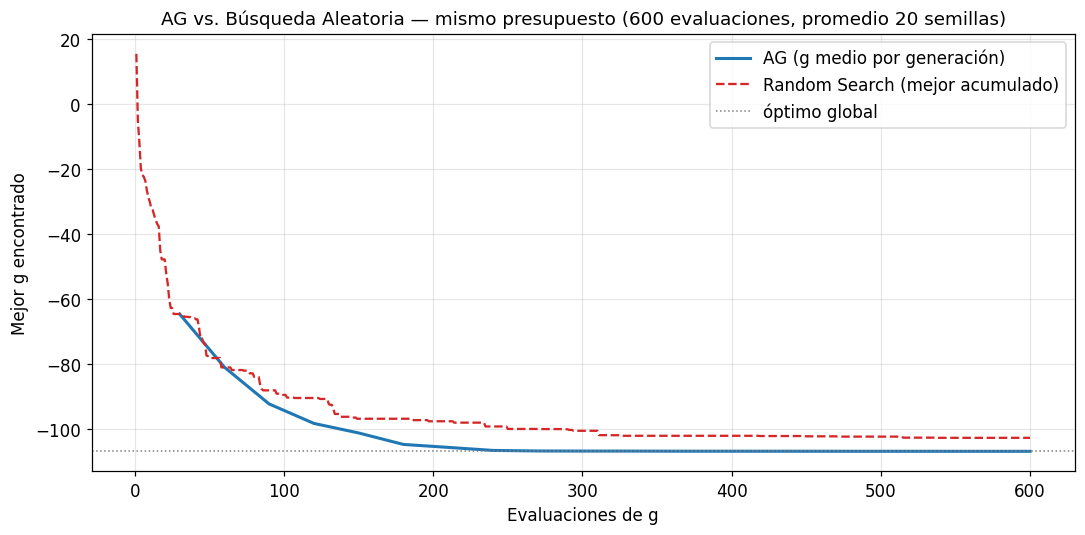

In [ ]:
# --- Parámetros compartidos ---
N_V      = 30
NGEN_V   = 20
BUDGET   = N_V * NGEN_V
N_SEEDS  = 20
TOL      = 0.5

# --- Búsqueda aleatoria con seguimiento de convergencia ---
def random_search(budget, bmin=BMIN, bmax=BMAX, seed=0):
    rng_r = np.random.default_rng(seed)
    puntos = rng_r.uniform(low=bmin, high=bmax, size=(budget, 2))
    vals   = g(puntos[:, 0], puntos[:, 1])
    h_best = np.minimum.accumulate(vals)   # mejor acumulado por evaluación
    best_idx = np.argmin(vals)
    return puntos[best_idx], vals[best_idx], h_best

# --- Comparación estadística sobre N_SEEDS semillas ---
res_ag  = []
res_rs  = []
exitos_ag = 0
exitos_rs = 0

for s in range(N_SEEDS):
    _, gm_ag, *_ = ejecutar_ga_2d(n_generaciones=NGEN_V, n_individuos=N_V,
                                   p_mutacion=0.5, sigma=0.4, p_cruce=0.8, seed=s)
    _, gm_rs, _  = random_search(BUDGET, seed=s)
    res_ag.append(gm_ag);  res_rs.append(gm_rs)
    if abs(gm_ag - G_OPT) < TOL: exitos_ag += 1
    if abs(gm_rs - G_OPT) < TOL: exitos_rs += 1

print(f"Presupuesto de evaluaciones: {BUDGET}  |  Semillas: {N_SEEDS}  |  Tolerancia: {TOL}")
print(f"{'Método':<20} {'Éxitos':>8} {'Tasa %':>8} {'g medio':>12} {'g mejor':>12}")
print("-"*56)
print(f"{'AG':<20} {exitos_ag:>8} {100*exitos_ag/N_SEEDS:>8.1f} {np.mean(res_ag):>12.3f} {np.min(res_ag):>12.3f}")
print(f"{'Random Search':<20} {exitos_rs:>8} {100*exitos_rs/N_SEEDS:>8.1f} {np.mean(res_rs):>12.3f} {np.min(res_rs):>12.3f}")

# --- Curvas de convergencia promedio ---
curves_ag = np.zeros((N_SEEDS, NGEN_V))
curves_rs = np.zeros((N_SEEDS, BUDGET))

for s in range(N_SEEDS):
    _, _, hb, _, _, _ = ejecutar_ga_2d(n_generaciones=NGEN_V, n_individuos=N_V,
                                        p_mutacion=0.5, sigma=0.4, p_cruce=0.8, seed=s)
    _, _, h_rs = random_search(BUDGET, seed=s)
    # hb tiene una entrada por generación; convertimos a evaluaciones
    evals = np.arange(1, NGEN_V + 1) * N_V
    curves_ag[s] = hb
    curves_rs[s] = h_rs

mean_ag = curves_ag.mean(axis=0)
mean_rs = curves_rs.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
evals_ag = np.arange(1, NGEN_V + 1) * N_V
ax.plot(evals_ag, mean_ag, color='#1f77b4', lw=2, label='AG (g medio por generación)')
ax.plot(np.arange(1, BUDGET + 1), mean_rs, color='#d62728', lw=1.5, ls='--',
        label='Random Search (mejor acumulado)')
ax.axhline(G_OPT, color='gray', ls=':', lw=1, label='óptimo global')
ax.set_xlabel("Evaluaciones de g"); ax.set_ylabel("Mejor g encontrado")
ax.set_title(f"AG vs. Búsqueda Aleatoria — mismo presupuesto ({BUDGET} evaluaciones, promedio {N_SEEDS} semillas)")
ax.legend(); plt.tight_layout(); plt.show()

La curva del AG (azul) converge de forma suave y sostenida, alcanzando valores muy cercanos al óptimo global ($g\approx-106{,}76$) alrededor de las **200 evaluaciones**. La curva del Random Search (rojo) mejora de forma errática y mucho más lenta: con las 600 evaluaciones completas todavía se encuentra lejos del óptimo, rondando $g\approx-103$ a $-104$.

Esta diferencia confirma que **los operadores genéticos están aportando valor real**. La selección por torneo concentra la búsqueda en las regiones prometedoras del espacio, el cruce aritmético combina soluciones parcialmente buenas para generar descendencia mejor, y la mutación provee la diversidad necesaria para no quedar atrapado en mínimos locales. El resultado neto es una exploración dirigida que supera al muestreo ciego con el mismo presupuesto de evaluaciones.

Esto descarta la hipótesis de que el AG estaba funcionando como un *random search* disfrazado: con parámetros bien calibrados, sus operadores aceleran la convergencia al óptimo de forma significativa respecto a una búsqueda sin estructura.

---

## 9. Conclusiones

El motor evolutivo del Ejercicio 1 se adaptó a la minimización 2D de la función de Mishra Bird redefiniendo el fitness como $-g$, sin modificar ningún operador. La población mínima confiable se mantuvo en ≈20 individuos al pasar de 1D a 2D, lo que indica una relación sublineal con la dimensionalidad para espacios de baja dimensión.

El barrido de parámetros identificó como zona útil `p_mutacion` ≈ 0.2–0.5 con `sigma` ≈ 0.3–1.0, y `p_cruce` ≈ 0.5–0.85. El riesgo más crítico es la mutación baja, que produce convergencia prematura irreversible. Las restricciones de dominio definen la naturaleza del problema: sin ellas, la periodicidad de $g$ genera infinitos óptimos equivalentes y la verificación del resultado pierde sentido.

Finalmente, la comparación contra búsqueda aleatoria con igual presupuesto de evaluaciones confirmó que los operadores genéticos aportan valor real: el AG converge al óptimo global en ≈200 evaluaciones, mientras que el random search no lo alcanza con 600.

---
# Ejercicio 3: Optimización de la función de Schwefel en dimensiones arbitrarias





---

La función de Schwefel es un benchmark clásico de optimización global definido para un número
arbitrario de variables $d>0$:

$$ s(\mathbf{X}) = 418.9829 \cdot d - \sum_{i=1}^{d} x_i \,\sin\!\left(\sqrt{|x_i|}\right) $$

con mínimo global en $x_i = 420.9687 \ \forall i$, donde $s(\mathbf{X}) = 0$.

Su dificultad no proviene de la cantidad de mínimos locales por sí sola, sino de cómo están
dispuestos: el mínimo global se ubica lejos de la región donde se concentran los mejores mínimos
locales. Una búsqueda que avanza hacia los valles más profundos del entorno inmediato tiende a
alejarse del óptimo verdadero. Esto convierte a Schwefel en un paisaje que **castiga la convergencia
prematura**: penaliza explotar demasiado pronto y premia mantener diversidad el tiempo suficiente
como para descubrir el valle correcto, que en alta dimensión está rodeado por una cantidad
combinatoria de trampas.

El trabajo se organiza como un recorrido experimental: se valida primero el comportamiento en $d=1$
y $d=2$ (donde el paisaje aún es inspeccionable), se estudia cómo escala la dificultad con la
dimensión, se identifican qué parámetros gobiernan el éxito y se sintetiza una recomendación de
configuración inicial respaldada por una tabla de experimentos.

In [ ]:
!pip install plotly-express --quiet  # Animaciones de las corridas ilustrativas

## 1.1. Importaciones

In [ ]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import warnings
from datetime import datetime

import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1.2. Motor del algoritmo genético

Se reutiliza el motor del material de cátedra (clases `Individuo` y `Poblacion`), sin modificaciones.
El trabajo de este ejercicio no consiste en reimplementar el algoritmo, sino en orquestar
experimentos sobre él, registrarlos de forma sistemática e interpretar los resultados.

> Implementación basada en
> [Optimización con algoritmo genético — cienciadedatos.net](https://www.cienciadedatos.net/documentos/py01_optimizacion_ga).

In [ ]:
################################################################################
#               CÓDIGO OPTIMIZACIÓN CON ALGORITMO GENÉTICO                     #
#                                                                              #
# This work by Joaquín Amat Rodrigo is licensed under a Creative Commons       #
# Attribution 4.0 International License.                                       #
################################################################################
# coding=utf-8

################################################################################
#                              CLASE INDIVIDUO                                 #
################################################################################

class Individuo:
    """
    Esta clase representa un individuo con unas características inicial definida
    por una combinación de valores numéricos aleatorios. El rango de posibles
    valores para cada variable puede estar acotado.

    Parameters
    ----------
    n_variables : `int`
        número de variables que definen al individuo.

    limites_inf : `list` or `numpy.ndarray`, optional
        límite inferior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los ``None`` serán remplazados
        por el valor (-10**3). (default ``None``)

    limites_sup : `list` or `numpy.ndarray`, optional
        límite superior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los ``None`` serán remplazados
        por el valor (+10**3). (default ``None``)

    verbose : `bool`, optional
        mostrar información del individuo creado. (default ``False``)

    Attributes
    ----------
    n_variables : `int`
        número de variables que definen al individuo.

    limites_inf : `list` or `numpy.ndarray`
        límite inferior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los ``None`` serán remplazados por
        el valor (-10**3).

    limites_sup : `list` or `numpy.ndarray`
        límite superior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los``None`` serán remplazados por
        el valor (+10**3).

    valor_variables : `numpy.ndarray`
        array con el valor de cada una de las variables.

    fitness : `float`
        valor de fitness del individuo.

    valor_funcion : `float`
        valor de la función objetivo para el individuo.

    Raises
    ------
    raise Exception
        si `limites_inf` es distinto de None y su longitud no coincide con
        `n_variables`.

    raise Exception
        si `limites_sup` es distinto de None y su longitud no coincide con
        `n_variables`.

    Examples
    --------
    Ejemplo creación individuo.

    >>> individuo = Individuo(
                        n_variables = 3,
                        limites_inf = [-1,2,0],
                        limites_sup = [4,10,20],
                        verbose     = True
                    )

    """

    def __init__(self, n_variables, limites_inf=None, limites_sup=None,
                 verbose=False):

        # Número de variables del individuo
        self.n_variables = n_variables
        # Límite inferior de cada variable
        self.limites_inf = limites_inf
        # Límite superior de cada variable
        self.limites_sup = limites_sup
        # Valor de las variables del individuo
        self.valor_variables = np.repeat(None, n_variables)
        # Fitness del individuo
        self.fitness = None
        # Valor de la función objetivo
        self.valor_funcion = None

        # CONVERSIONES DE TIPO INICIALES
        # ----------------------------------------------------------------------
        # Si limites_inf o limites_sup no son un array numpy, se convierten en
        # ello.
        if self.limites_inf is not None \
        and not isinstance(self.limites_inf, np.ndarray):
            self.limites_inf = np.array(self.limites_inf)

        if self.limites_sup is not None \
        and not isinstance(self.limites_sup,np.ndarray):
            self.limites_sup = np.array(self.limites_sup)

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        if self.limites_inf is not None \
        and len(self.limites_inf) != self.n_variables:
            raise Exception(
                "limites_inf debe tener un valor por cada variable. " +
                "Si para alguna variable no se quiere límite, emplear None. " +
                "Ejemplo: limites_inf = [10, None, 5]"
                )
        elif self.limites_sup is not None \
        and len(self.limites_sup) != self.n_variables:
            raise Exception(
                "limites_sup debe tener un valor por cada variable. " +
                "Si para alguna variable no se quiere límite, emplear None. " +
                "Ejemplo: limites_sup = [10, None, 5]"
                )
        elif (self.limites_inf is None) or (self.limites_sup is None):
            warnings.warn(
                "Es altamente recomendable indicar los límites dentro de los " +
                "cuales debe buscarse la solución de cada variable. " +
                "Por defecto se emplea [-10^3, 10^3]."
                )
        elif any(np.concatenate((self.limites_inf, self.limites_sup)) == None):
            warnings.warn(
                "Los límites empleados por defecto cuando no se han definido " +
                "son: [-10^3, 10^3]."
            )

        # COMPROBACIONES INICIALES: ACCIONES
        # ----------------------------------------------------------------------

        # Si no se especifica limites_inf, el valor mínimo que pueden tomar las
        # variables es -10^3.
        if self.limites_inf is None:
            self.limites_inf = np.repeat(-10**3, self.n_variables)

        # Si no se especifica limites_sup, el valor máximo que pueden tomar las
        # variables es 10^3.
        if self.limites_sup is None:
             self.limites_sup = np.repeat(+10**3, self.n_variables)

        # Si los límites no son nulos, se reemplazan aquellas posiciones None por
        # el valor por defecto -10^3 y 10^3.
        if self.limites_inf is not None:
            self.limites_inf[self.limites_inf == None] = -10**3

        if self.limites_sup is not None:
            self.limites_sup[self.limites_sup == None] = +10**3

        # BUCLE PARA ASIGNAR UN VALOR A CADA UNA DE LAS VARIABLES
        # ----------------------------------------------------------------------
        for i in np.arange(self.n_variables):
        # Para cada variable, se genera un valor aleatorio dentro del rango
        # permitido para esa variable.
            self.valor_variables[i] = random.uniform(
                                        self.limites_inf[i],
                                        self.limites_sup[i]
                                      )

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("Nuevo individuo creado")
            print("----------------------")
            print("Valor variables: " + str(self.valor_variables))
            print("Valor función objetivo: " + str(self.valor_funcion))
            print("Fitness: " + str(self.fitness))
            print("Límites inferiores de cada variable: " \
                  + str(self.limites_inf))
            print("Límites superiores de cada variable: " \
                  + str(self.limites_sup))
            print("")

    def __repr__(self):
        """
        Información que se muestra cuando se imprime un objeto individuo.

        """

        texto = "Individuo" \
                + "\n" \
                + "---------" \
                + "\n" \
                + "Valor variables: " + str(self.valor_variables) \
                + "\n" \
                + "Valor función objetivo: " + str(self.valor_funcion) \
                + "\n" \
                + "Fitness: " + str(self.fitness) \
                + "\n" \
                + "Límites inferiores de cada variable: " \
                + str(self.limites_inf) \
                + "\n" \
                + "Límites superiores de cada variable: " \
                + str(self.limites_sup) \
                + "\n"

        return(texto)

    def calcular_fitness(self, funcion_objetivo, optimizacion, verbose = False):
        """
        Este método obtiene el fitness del individuo calculando el valor que toma
        la función objetivo con el valor de sus variables.

        Parameters
        ----------
        funcion_objetivo : `function`
            función que se quiere optimizar.

        optimizacion : {'maximizar', 'minimizar'}
            ver notas para más información.

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        Raises
        ------
        raise Exception
            si el argumento `optimizacion` es distinto de 'maximizar' o
            'minimizar'

        Notes
        -----

        Cada individuo de la población debe ser evaluado para cuantificar su
        bondad como solución al problema, a esta cuantificación se le llama
        fitness.

        Dependiendo de si se trata de un problema de maximización o minimización,
        la relación del fitness con la función objetivo :math:`f` puede ser:

        - Maximización: el individuo tiene mayor fitness cuanto mayor es el valor
         de la función objetivo :math:`f(individuo)`.

        - Minimización: el individuo tiene mayor fitness cuanto menor es el valor
         de la función objetivo :math:`f(individuo)`, o lo que es lo mismo,
         cuanto mayor es el valor de la función objetivo, menor el fitness.
         El algoritmo genético selecciona los individuos de mayor fitness, por
         lo que, para problemas de minimización, el fitness puede calcularse como
         :math:`−f(individuo)` o también :math:`\frac{1}{1+f(individuo)}`.

        Examples
        --------
        Ejemplo evaluar individuo con una función objetivo.

        >>> individuo = Individuo(
                        n_variables = 3,
                        limites_inf = [-1,2,0],
                        limites_sup = [4,10,20],
                        verbose     = True
                    )

        >>> def funcion_objetivo(x_0, x_1, x_2):
                f= x_0**2 + x_1**2 + x_2**2
                return(f)

        >>> individuo.calcular_fitness(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = "minimizar",
                verbose          = True
            )

        """

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        if not optimizacion in ["maximizar", "minimizar"]:
            raise Exception(
                "El argumento optimizacion debe ser: 'maximizar' o 'minimizar'"
                )

        # EVALUACIÓN DE LA FUNCIÓN OBJETIVO CON LAS VARIABLES DEL INDIVIDUO Y
        # CÁLCULO DEL FITNESS
        # ----------------------------------------------------------------------
        self.valor_funcion = funcion_objetivo(*self.valor_variables)
        if optimizacion == "maximizar":
            self.fitness = self.valor_funcion
        elif optimizacion == "minimizar":
            self.fitness = -self.valor_funcion

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("El individuo ha sido evaluado")
            print("-----------------------------")
            print("Valor función objetivo: " + str(self.valor_funcion))
            print("Fitness: " + str(self.fitness))
            print("")

    def mutar(self, prob_mut=0.01, distribucion="uniforme", media_distribucion=1,
              sd_distribucion=1, min_distribucion=-1, max_distribucion=1,
              verbose=False):
        """
        Este método somete al individuo a un proceso de mutación en el que, cada
        una de sus posiciones, puede verse modificada con una probabilidad
        `prob_mut`. Tras mutar, los atributos `valor_funcion` y `fitness` se
        reinician.

        Parameters
        ----------
        prob_mut : `float`, optional
            probabilidad que tiene cada posición del individuo de mutar.
            (default 0.01)

        distribucion : {"normal", "uniforme", "aleatoria"}, optional
            distribución de la que obtener el factor de mutación.
            (default "uniforme")

        media_distribucion : `float`, optional
            media de la distribución si se selecciona `distribucion = "normal"`
            (default 1)

        sd_distribucion : `float`, optional
            desviación estándar de la distribución si se selecciona
            `distribucion = "normal"`. (default 1)

        min_distribucion : `float`, optional
            mínimo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default -1)

        max_distribucion : `float`, optional
            máximo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default +1)

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        Raises
        ------
        raise Exception
            si el argumento `distribucion` es distinto de 'normal', 'uniforme' o
            'aleatoria'.

        Examples
        --------
        Ejemplo mutar individuo.

        >>> individuo = Individuo(
                        n_variables = 3,
                        limites_inf = [-1,2,0],
                        limites_sup = [4,10,20],
                        verbose     = True
                    )

        >>> individuo.mutar(
                prob_mut         = 0.5,
                distribucion     = "uniforme",
                min_distribucion = -1,
                max_distribucion = 1,
                verbose          = True
            )

        Notes
        -----

        El proceso de mutación añade diversidad al proceso y evitar que el
        algoritmo caiga en mínimos locales por que todos los individuos sean
        demasiado parecidos de una generación a otra. Existen diferentes
        estrategias para controlar la magnitud del cambio que puede provocar una
        mutación.

        - Distribución uniforme: la mutación de la posición i se consigue
        sumándole al valor de i un valor extraído de una distribución uniforme,
        por ejemplo una entre [-1,+1].

        - Distribución normal: la mutación de la posición i se consigue sumándole
         al valor de i un valor extraído de una distribución normal, comúnmente
         centrada en 0 y con una determinada desviación estándar. Cuanto mayor
         la desviación estándar, con mayor probabilidad la mutación introducirá
         cambios grandes.

        - Aleatorio: la mutación de la posición i se consigue reemplazando el
        valor de i por nuevo valor aleatorio dentro del rango permitido para esa
        variable. Esta estrategia suele conllevar mayores variaciones que las dos
        anteriores.

        Hay que tener en cuenta que, debido a las mutaciones, un valor que
        inicialmente estaba dentro del rango permitido puede salirse de él.
        Una forma de evitarlo es: si el valor tras la mutación excede alguno de
        los límites acotados, se sobrescribe con el valor del límite. Es decir,
        se permite que los valores se alejen como máximo hasta el límite impuesto.

        """

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        if not distribucion in ["normal", "uniforme", "aleatoria"]:
            raise Exception(
                "El argumento distribucion debe ser: 'normal', 'uniforme' o " \
                + "'aleatoria'"
                )

        # SELECCIÓN PROBABILISTA DE POSICIONES (VARIABLES) QUE MUTAN
        #-----------------------------------------------------------------------
        posiciones_mutadas = np.random.uniform(
                                low=0,
                                high=1,
                                size=self.n_variables
                             )
        posiciones_mutadas = posiciones_mutadas > prob_mut

        # MODIFICACIÓN DE LOS VALORES DE LAS VARIABLES SELECCIONADAS
        #-----------------------------------------------------------------------
        # Si la distribución seleccionada es "uniforme" o "normal", se extrae un
        # valor aleatorio de la distribución elegida que se suma para modificar
        # la/las posiciones mutadas.

        if distribucion in ["normal", "uniforme"]:
            if distribucion == "normal":
                factor_mut = np.random.normal(
                                loc   = media_distribucion,
                                scale = sd_distribucion,
                                size  = np.sum(posiciones_mutadas)
                             )
            if distribucion == "uniforme":
                factor_mut = np.random.uniform(
                                low  = min_distribucion,
                                high = max_distribucion,
                                size = np.sum(posiciones_mutadas)
                             )
            self.valor_variables[posiciones_mutadas] = \
                self.valor_variables[posiciones_mutadas] + factor_mut

            # Se comprueba si algún valor mutado supera los límites impuestos.
            # En tal caso se sobrescribe con el valor del límite correspondiente.
            for i in np.flatnonzero(posiciones_mutadas):
                if self.valor_variables[i] < self.limites_inf[i]:
                    self.valor_variables[i] = self.limites_inf[i]
                if self.valor_variables[i] > self.limites_sup[i]:
                    self.valor_variables[i] = self.limites_sup[i]

        # Si la distribución seleccionada es "aleatoria", se sobreescribe el
        # valor de la variable con un nuevo valor aleatorio dentro de los
        # límites establecidos.
        if distribucion == "aleatoria":
            for i in np.flatnonzero(posiciones_mutadas):
                self.valor_variables[i] = random.uniform(
                                            self.limites_inf[i],
                                            self.limites_sup[i]
                                          )
        # REINICIO DEL VALOR Y DEL FITNESS
        #-----------------------------------------------------------------------
        # Dado que el individuo ha mutado, el valor de su fitness y de la
        # función objetivo ya no son validos.
        self.fitness = None
        self.valor_funcion = None

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("El individuo ha sido mutado")
            print("---------------------------")
            print("Total mutaciones: " + str(np.sum(posiciones_mutadas)))
            print("Valor variables: " + str(self.valor_variables))
            print("")

In [ ]:
################################################################################
#               CÓDIGO OPTIMIZACIÓN CON ALGORITMO GENÉTICO                     #
#                                                                              #
# This work by Joaquín Amat Rodrigo is licensed under a Creative Commons       #
# Attribution 4.0 International License.                                       #
################################################################################
# coding=utf-8

################################################################################
#                               CLASE POBLACIÓN                                #
################################################################################

class Poblacion:
    """
    Esta clase crea una población de n individuos.

    Parameters
    ----------
    n_individuos :`int`
        número de individuos de la población.

    n_variables : `int`
        número de variables que definen a cada individuo.

    limites_inf : `list` or `numpy.ndarray`
        límite inferior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los ``None`` serán remplazados por
        el valor (-10**3).

    limites_sup : `list` or `numpy.ndarray`
        límite superior de cada variable. Si solo se quiere predefinir límites
        de alguna variable, emplear ``None``. Los``None`` serán remplazados por
        el valor (+10**3).

    verbose : `bool`, optional
        mostrar información del proceso por pantalla. (default ``False``)

    Attributes
    ----------
    individuos : `list`
        lista con todos los individuos de la población en su estado actual.

    n_individuos :`int`
        número de individuos de la población.

    n_variables : `int`
        número de variables que definen a cada individuo.

    limites_inf : `list` or `numpy.ndarray`
        límite inferior de cada variable.

    limites_sup : `list` or `numpy.ndarray`
        límite superior de cada variable.

    mejor_individuo : `object individuo`
        mejor individuo de la población en su estado actual.

    mejor_fitness : `float`
        fitness del mejor individuo de la población en su estado actual.

    mejor_valor_funcion : `float`
        valor de la función objetivo del mejor individuo de la población en su
        estado actual.

    mejor_individuo_variables : `numpy.ndarray`
        valor de las variables del mejor individuo de la población en su estado
        actual.

    historico_individuos : `list`
        lista con la información de todos los individuos en cada una de las
        generaciones que ha tenido la población.

    historico_mejor_individuo_variables : `list`
        lista con valor de las variables del mejor individuo en cada una de las
        generaciones que ha tenido la población.

    historico_mejor_fitness : `list`
        lista con el mejor fitness en cada una de las generaciones que ha tenido
        la población.

    historico_mejor_valor_funcion : `list`
        lista con valor de la función objetivo del mejor individuo en cada una
        de las generaciones que ha tenido la población.

    diferencia_abs : `list`
        diferencia absoluta entre el mejor fitness de generaciones consecutivas.

    resultados_df : `pandas.core.frame.DataFrame`
        dataframe con la información del mejor fitness y valor de las variables
        encontrado en cada generación, así como la diferencia respecto a la
        generación anterior.

    fitness_optimo : `float`
        mejor fitness encontrado tras el proceso de optimización.

    valor_funcion_optimo : `float`
        valor de la función objetivo encontrado tras el proceso de optimización.

    valor_variables_optimo : `numpy.narray`
        valor de las variables con el que se ha conseguido el mejor fitness tras
        el proceso de optimización.

    optimizado : `bool`
        si la población ha sido optimizada.

    iter_optimizacion : `int`
        número de iteraciones de optimización (generaciones).

    Examples
    --------
    Ejemplo crear población

    >>> poblacion = Poblacion(
                        n_individuos = 3,
                        n_variables  = 3,
                        limites_inf  = [-5,-5,-5],
                        limites_sup  = [5,5,5],
                        verbose = True
                        )

    """

    def __init__(self, n_individuos, n_variables, limites_inf=None,
                 limites_sup=None, verbose=False):

        # Número de individuos de la población
        self.n_individuos = n_individuos
        # Número de variables de cada individuo
        self.n_variables = n_variables
        # Límite inferior de cada variable
        self.limites_inf = limites_inf
        # Límite superior de cada variable
        self.limites_sup = limites_sup
        # Lista de los individuos de la población
        self.individuos = []
        # Etiqueta para saber si la población ha sido optimizada
        self.optimizado = False
        # Número de iteraciones de optimización llevadas a cabo
        self.iter_optimizacion = None
        # Mejor individuo de la población
        self.mejor_individuo = None
        # Fitness del mejor individuo de la población (el de mayor fitness)
        self.mejor_fitness = None
        # Valor de la función objetivo del mejor individuo de la población
        self.mejor_valor_funcion = None
        # Valor de las variables del mejor individuo de la población
        self.mejor_valor_variables = None
        # Información de todas los individuos de la población en cada generación
        self.historico_individuos = []
        # Valor de las variables del mejor individuo en cada generación
        self.historico_mejor_valor_variables = []
        # Fitness del mejor individuo en cada generación
        self.historico_mejor_fitness = []
        # Valor de la función objetivo del mejor individuo en cada generación
        self.historico_mejor_valor_funcion = []
        # Diferencia absoluta entre el mejor fitness de generaciones consecutivas
        self.diferencia_abs = []
        # data.frame con la información del mejor fitness y valor de variables
        # encontrado en cada generación, así como la diferencia respecto a la
        # generación anterior.
        self.resultados_df = None
        # Fitness del mejor individuo de todas las generaciones
        self.fitness_optimo = None
        # Valor de las variables del mejor individuo de todas las generaciones
        self.valor_variables_optimo = None
        # Valor de función objetivo del mejor individuo de todas las generaciones
        self.valor_funcion_optimo = None

        # CONVERSIONES DE TIPO INICIALES
        # ----------------------------------------------------------------------
        # Si limites_inf o limites_sup no son un array numpy, se convierten en
        # ello.
        if self.limites_inf is not None \
        and not isinstance(self.limites_inf,np.ndarray):
            self.limites_inf = np.array(self.limites_inf)

        if self.limites_sup is not None \
        and not isinstance(self.limites_sup,np.ndarray):
            self.limites_sup = np.array(self.limites_sup)

        # SE CREAN LOS INDIVIDUOS DE LA POBLACIÓN Y SE ALMACENAN
        # ----------------------------------------------------------------------
        for i in np.arange(n_individuos):
            individuo_i = Individuo(
                            n_variables = self.n_variables,
                            limites_inf = self.limites_inf,
                            limites_sup = self.limites_sup,
                            verbose     = verbose
                          )
            self.individuos.append(individuo_i)

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("----------------")
            print("Población creada")
            print("----------------")
            print("Número de individuos: " + str(self.n_individuos))
            print("Límites inferiores de cada variable: " \
                  + np.array2string(self.limites_inf))
            print("Límites superiores de cada variable: " \
                  + np.array2string(self.limites_sup))
            print("")

    def __repr__(self):
        """
        Información que se muestra cuando se imprime un objeto población.

        """

        texto = "============================" \
                + "\n" \
                + "         Población" \
                + "\n" \
                + "============================" \
                + "\n" \
                + "Número de individuos: " + str(self.n_individuos) \
                + "\n" \
                + "Límites inferiores de cada variable: " + str(self.limites_inf) \
                + "\n" \
                + "Límites superiores de cada variable: " + str(self.limites_sup) \
                + "\n" \
                + "Optimizado: " + str(self.optimizado) \
                + "\n" \
                + "Iteraciones optimización (generaciones): " \
                     + str(self.iter_optimizacion) \
                + "\n" \
                + "\n" \
                + "Información del mejor individuo:" \
                + "\n" \
                + "----------------------------" \
                + "\n" \
                + "Valor variables: " + str(self.mejor_valor_variables) \
                + "\n" \
                + "Fitness: " + str(self.mejor_fitness) \
                + "\n" \
                + "\n" \
                + "Resultados tras optimizar:" \
                + "\n" \
                + "--------------------------" \
                + "\n" \
                + "Valor óptimo de variables: " + str(self.valor_variables_optimo) \
                + "\n" \
                + "Valor óptimo función objetivo: " + str(self.valor_funcion_optimo) \
                + "\n" \
                + "Fitness óptimo: " + str(self.fitness_optimo)


        return(texto)

    def mostrar_individuos(self, n=None):
        """
        Este método muestra la información de cada uno de los n primeros
        individuos de la población.

        Parameters
        ----------

        n : `int`
            número de individuos que se muestran. Si no se indica el valor
            (por defecto ``None``), se muestran todas. Si el valor es mayor
            que `self.n_individuos` se muestran todas.

        Examples
        --------
        >>> poblacion = Poblacion(
               n_individuos = 5,
               n_variables  = 3,
               limites_inf  = [-5,-5,-5],
               limites_sup  = [5,5,5],
               verbose      = True
            )

        >>> poblacion.mostrar_individuos(n = 1)

        """

        if n is None:
            n = self.n_individuos
        elif n > self.n_individuos:
            n = self.n_individuos

        for i in np.arange(n):
            print(self.individuos[i])
        return(None)

    def evaluar_poblacion(self, funcion_objetivo, optimizacion, verbose=False):
        """
        Este método calcula el fitness de todos los individuos de la población,
        actualiza sus valores e identifica el mejor.

        Parameters
        ----------
        funcion_objetivo : `function`
            función que se quiere optimizar.

        optimizacion : {"maximizar" o "minimizar"}
            si se desea maximizar o minimizar la función.

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        Examples
        --------
        Ejemplo evaluar población

        >>> poblacion = Poblacion(
               n_individuos = 5,
               n_variables  = 3,
               limites_inf  = [-5,-5,-5],
               limites_sup  = [5,5,5],
               verbose      = True
            )

        >>> def funcion_objetivo(x_0, x_1, x_2):
                f= x_0**2 + x_1**2 + x_2**2
                return(f)

        >>> poblacion.evaluar_poblacion(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = "minimizar",
                verbose          = True
                )

        """

        # SE EVALÚA CADA INDIVIDUO DE LA POBLACIÓN
        # ----------------------------------------------------------------------
        for i in np.arange(self.n_individuos):
            self.individuos[i].calcular_fitness(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = optimizacion,
                verbose          = verbose
            )

        # MEJOR INDIVIDUO DE LA POBLACIÓN
        # ----------------------------------------------------------------------
        # Se identifica el mejor individuo de toda el población, el de mayor
        # fitness.

        # Se selecciona inicialmente como mejor individuo el primero.
        self.mejor_individuo = copy.deepcopy(self.individuos[0])
        # Se comparan todas los individuos de la población.
        for i in np.arange(self.n_individuos):
            if self.individuos[i].fitness > self.mejor_individuo.fitness:
                self.mejor_individuo = copy.deepcopy(self.individuos[i])

        # Se extrae la información del mejor individuo de la población.
        self.mejor_fitness = self.mejor_individuo.fitness
        self.mejor_valor_variables = self.mejor_individuo.valor_variables
        self.mejor_valor_funcion = self.mejor_individuo.valor_funcion

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("------------------")
            print("Población evaluada")
            print("------------------")
            print("Mejor fitness encontrado : " + str(self.mejor_fitness))
            print("Valor de la función objetivo: " \
                + str(self.mejor_valor_funcion))
            print("Mejor valor de variables encontrado : "
                + str(self.mejor_valor_variables))
            print("")

    def cruzar_individuos(self, parental_1, parental_2, verbose=False):
        """
        Este método genera un nuevo individuo a partir de dos individuos
        parentales empleando el método de cruzamiento uniforme.

        Parameters
        ----------
        parental_1 : `int`
            índice del individuo de la población que se quiere emplear como
            parental 1 para el cruzamiento.

        parental_1 : `int`
            índice del individuo de la población que se quiere emplear como
            parental 1 para el cruzamiento.

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        Raises
        ------
        raise Exception
            si los índices parental_1 o parental_2 no son índices válidos.

        Returns
        ------
        descendencia : `Individuo`
            Nuevo individuo generado por cruzamiento de dos parentales.

        Examples
        --------
        >>> poblacion = Poblacion(
               n_individuos = 5,
               n_variables  = 3,
               limites_inf  = [-5,-5,-5],
               limites_sup  = [5,5,5]
            )

        >>> descendencia = poblacion.cruzar_individuos(
                            parental_1 = 0,
                            parental_2 = 1,
                            verbose    = True
                           )

        Notes
        -----
        El objetivo del cruzamiento es generar, a partir de individuos ya
        existentes (parentales), nuevos individuos (descendencia) que combinen
        las características de los anteriores. Este es otro de los puntos del
        algoritmo en los que se puede seguir varias estrategias. Tres de las más
        empleadas son:

        -Cruzamiento a partir de uno solo punto: se selecciona aleatoriamente
        una posición que actúa como punto de corte. Cada individuo parental se
        divide en dos partes y se intercambian las mitades. Como resultado de
        este proceso, por cada cruce, se generan dos nuevos individuos.

        -Cruzamiento a partir múltiples puntos: se seleccionan aleatoriamente
        varias posiciones que actúan como puntos de corte. Cada individuo
        parental se divide por los puntos de corte y se intercambian las partes.
        Como resultado de este proceso, por cada cruce, se generan dos nuevos
        individuos.

        -Cruzamiento uniforme: el valor que toma cada posición del nuevo
        individuo se obtiene de uno de los dos parentales. Por lo general,
        la probabilidad de que el valor proceda de cada parental es la misma,
        aunque podría, por ejemplo, estar condicionada al fitness de cada uno.
        A diferencia de las anteriores estrategias, con esta, de cada cruce se
        genera un único descendiente.

        """

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        if parental_1 not in np.arange(self.n_individuos):
            raise Exception(
                "El el índice del parental_1 debe de ser un valor entre 0 y " +
                "el número de individuos de la población."
                )
        if parental_2 not in np.arange(self.n_individuos):
            raise Exception(
                "El el índice del parental_2 debe de ser un valor entre 0 y " +
                "el número de individuos de la población."
                )

        # CREACIÓN DE LA DESCENDENCIA
        # ----------------------------------------------------------------------
        # Se extraen los parentales acorde a los índices indicados.
        parental_1 = self.individuos[parental_1]
        parental_2 = self.individuos[parental_2]

        # Se clona uno de los parentales para utilizarlo como plantilla del nuevo
        # individuo.
        descendencia = copy.deepcopy(parental_1)
        descendencia.valor_variables = np.repeat(None, descendencia.n_variables)
        descendencia.fitness = None

        # Se seleccionan aleatoriamente las posiciones que se heredan del
        # parental_1 y del parental 2.
        herencia_parent_1 = np.random.choice(
                                a       = [True, False],
                                size    = descendencia.n_variables,
                                p       = [0.5, 0.5],
                                replace = True
                            )
        herencia_parent_2 = np.logical_not(herencia_parent_1)

        # Se transfieren los valores al nuevo individuo.
        descendencia.valor_variables[herencia_parent_1] \
            = parental_1.valor_variables[herencia_parent_1]

        descendencia.valor_variables[herencia_parent_2] \
            = parental_2.valor_variables[herencia_parent_2]

        # Se crea un deepcopy para que el nuevo individuo sea independiente de
        # los parentales. Esto evita problemas si posteriormente se muta.
        descendencia = copy.deepcopy(descendencia)

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("------------------------------------")
            print("Cruce realizado: descendencia creada")
            print("------------------------------------")
            print("Valor variables: " + str(descendencia.valor_variables))
            print("")
        return(descendencia)

    def seleccionar_individuo(self, n, return_indices=True,
                              metodo_seleccion="tournament", verbose=False):
        """
        Este método selecciona los índices de n individuos de una población,
        donde la probabilidad de selección está relacionada con el fitness de
        cada individuo. Si el argumento `return_indices=False` en lugar de los
        índices se devuelve una copia de los individuos seleccionados.

        Parameters
        ----------
        n : `int`
            número de individuos de la población seleccionados.

        return_indices : `bool`, optional
            cuando es True, se devuelve el indice que ocupan los individuos
            seleccionados, cuando es False se devuelve una lista que contiene una
            copia de los individuos. (default ``True``)

        metodo_seleccion : {"ruleta", "rank", "tournament"}
            método de selección de selección, ver notas para más información.
            (default `tournament`)

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        Raises
        ------
        raise Exception
            si el argumento `metodo_seleccion` no es 'ruleta', 'rank' o
            'tournament'.

        Returns
        -------

        indices : `numpy.ndarray`
            índice de los individuos seleccionados (si `return_indices=True`).

        individuos : `list`
            lista con los individuos seleccionados (si `return_indices=False`).

        Examples
        --------
        >>> poblacion = Poblacion(
               n_individuos = 5,
               n_variables  = 3,
               limites_inf  = [-5,-5,-5],
               limites_sup  = [5,5,5],
               verbose      = True
            )

        >>> def funcion_objetivo(x_0, x_1, x_2):
                f= x_0**2 + x_1**2 + x_2**2
                return(f)

        >>> poblacion.evaluar_poblacion(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = "minimizar",
                verbose          = True
                )

        >>> poblacion.seleccionar_individuo(
                n                = 2,
                return_indices   = True,
                metodo_seleccion = "tournament",
                verbose          = True
            )

        Notes
        -----
        La forma en que se seleccionan los individuos que participan en cada cruce
        difiere en las distintas implementaciones de los algoritmos genéticos.
        Por lo general, todas ellas tienden a favorecer la selección de aquellos
        individuos con mayor fitness. Algunas de las estrategias más comunes son:

        -Método de ruleta: la probabilidad de que un individuo sea seleccionado
        es proporcional a su fitness relativo, es decir, a su fitness dividido
        por la suma del fitness de todos los individuos de la población. Si el
        fitness de un individuo es el doble que el de otro, también lo será la
        probabilidad de que sea seleccionado. Este método presenta problemas si
        el fitness de unos pocos individuos es muy superior (varios órdenes de
        magnitud) al resto, ya que estos serán seleccionados de forma repetida y
        casi todos los individuos de la siguiente generación serán “hijos” de
        los mismos “padres” (poca variación).

        -Método rank: la probabilidad de selección de un individuo es inversamente
        proporcional a la posición que ocupa tras ordenar todos los individuos
        de mayor a menor fitness. Este método es menos agresivo que el método
        ruleta cuando la diferencia entre los mayores fitness es varios órdenes
        de magnitud superior al resto.

        -Selección competitiva (tournament): se seleccionan aleatoriamente dos
        parejas de individuos de la población (todos con la misma probabilidad).
        De cada pareja se selecciona el que tenga mayor fitness. Finalmente,
        se comparan los dos finalistas y se selecciona el de mayor fitness. Este
        método tiende a generar una distribución de la probabilidad de selección
        más equilibrada que las dos anteriores.

        -Selección truncada (truncated selection): se realizan selecciones
        aleatorias de individuos, habiendo descartado primero los n individuos
        con menor fitness de la población.

        """

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        if metodo_seleccion not in ["ruleta", "rank", "tournament"]:
            raise Exception(
                "El método de selección debe de ser ruleta, rank o tournament"
                )

        # SELECCIÓN DE INDIVIDUOS
        # ----------------------------------------------------------------------
        # Se crea un array con el fitness de cada individuo de la población.
        array_fitness = np.repeat(None, self.n_individuos)
        for i in np.arange(self.n_individuos):
            array_fitness[i] = copy.copy(self.individuos[i].fitness)

        # Se calcula la probabilidad de selección de cada individuo en función
        # de su fitness.
        if metodo_seleccion == "ruleta":
            probabilidad_seleccion = array_fitness / np.sum(array_fitness)
            ind_seleccionado = np.random.choice(
                                    a       = np.arange(self.n_individuos),
                                    size    = n,
                                    p       = list(probabilidad_seleccion),
                                    replace = True
                               )
        elif metodo_seleccion == "rank":
            # La probabilidad con este método es inversamente proporcional a la
            # posición en la que quedan ordenados los individuos de menor a mayor
            # fitness.
            order = np.flip(np.argsort(a=array_fitness) + 1)
            ranks = np.argsort(order) + 1
            probabilidad_seleccion = 1 / ranks
            probabilidad_seleccion = probabilidad_seleccion / np.sum(probabilidad_seleccion)
            ind_seleccionado = np.random.choice(
                                a       = np.arange(self.n_individuos),
                                size    = n,
                                p       = list(probabilidad_seleccion),
                                replace = True
                            )
        elif metodo_seleccion == "tournament":
            ind_seleccionado = np.repeat(None,n)
            for i in np.arange(n):
                # Se seleccionan aleatoriamente dos parejas de individuos.
                candidatos_a = np.random.choice(
                                a       = np.arange(self.n_individuos),
                                size    = 2,
                                replace = False
                            )
                candidatos_b = np.random.choice(
                                a       = np.arange(self.n_individuos),
                                size    = 2,
                                replace = False
                            )
                # De cada pareja se selecciona el de mayor fitness.
                if array_fitness[candidatos_a[0]] > array_fitness[candidatos_a[1]]:
                    ganador_a = candidatos_a[0]
                else:
                    ganador_a = candidatos_a[1]

                if array_fitness[candidatos_b[0]] > array_fitness[candidatos_b[1]]:
                    ganador_b = candidatos_b[0]
                else:
                    ganador_b = candidatos_b[1]

                # Se comparan los dos ganadores de cada pareja.
                if array_fitness[ganador_a] > array_fitness[ganador_b]:
                    ind_final = ganador_a
                else:
                    ind_final = ganador_b

                ind_seleccionado[i] = ind_final

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("----------------------")
            print("Individuo seleccionado")
            print("----------------------")
            print("Método selección: " + metodo_seleccion)
            print("")

        if(return_indices):
            return(ind_seleccionado)
        else:
            if n == 1:
                return(copy.deepcopy(self.individuos[int(ind_seleccionado)]))
            if n > 1:
                return(
                    [copy.deepcopy(self.individuos[i]) for i in ind_seleccionado]
                )

    def crear_nueva_generecion(self, metodo_seleccion="tournament",
                               elitismo=0.1, prob_mut=0.01,
                               distribucion="uniforme",
                               media_distribucion=1, sd_distribucion=1,
                               min_distribucion=-1, max_distribucion=1,
                               verbose=False, verbose_seleccion=False,
                               verbose_cruce=False, verbose_mutacion=False):
        """
        Este método somete la población a una nueva generación.

        Parameters
        ----------
        metodo_seleccion : {"ruleta", "rank", "tournament"}
            método de selección de selección, ver notas para más información.
            (default `tournament`)

        elitismo : `float`, optional
            porcentaje de mejores individuos de la población actual que pasan
            directamente a la siguiente población. De esta forma, se asegura
            que, la siguiente generación, no sea nunca peor. (default `0.1`)

        prob_mut : `float`, optional
            probabilidad que tiene cada posición del individuo de mutar.
            (default 0.01)

        distribucion : {"normal", "uniforme", "aleatoria"}, optional
            distribución de la que obtener el factor de mutación.
            (default "uniforme")

        media_distribucion : `float`, optional
            media de la distribución si se selecciona `distribucion = "normal"`
            (default 1)

        sd_distribucion : `float`, optional
            desviación estándar de la distribución si se selecciona
            `distribucion = "normal"`. (default 1)

        min_distribucion : `float`, optional
            mínimo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default -1)

        max_distribucion : `float`, optional
            máximo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default +1)

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        verbose_seleccion : `bool`, optional
            mostrar información de cada selección por pantalla.
            (default ``False``)

        verbose_cruce : `bool`, optional
            mostrar información de cada cruce por pantalla.
            (default ``False``)

        verbose_mutacion : `bool`, optional
            mostrar información de cada mutación por pantalla.
            (default ``False``)

        Examples
        --------

        >>> poblacion = Poblacion(
               n_individuos = 5,
               n_variables  = 3,
               limites_inf  = [-5,-5,-5],
               limites_sup  = [5,5,5],
               verbose      = True
            )

        >>> def funcion_objetivo(x_0, x_1, x_2):
                f= x_0**2 + x_1**2 + x_2**2
                return(f)

        >>> poblacion.evaluar_poblacion(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = "minimizar",
                verbose          = True
                )

        >>> poblacion.crear_nueva_generecion(
                metodo_seleccion   = "tournament",
                elitismo           = 0.1,
                prob_mut           = 0.01,
                distribucion       = "uniforme",
                verbose            = True,
                verbose_seleccion  = False,
                verbose_cruce      = False,
                verbose_mutacion   = False
                )

        """

        # Lista donde almacenar los individuos de la nueva generación.
        nuevos_individuos = []

        # ELITISMO
        # ----------------------------------------------------------------------
        if elitismo > 0:
            # Número de individuos que pasan directamente a la siguiente
            # generación.
            n_elitismo = int(np.ceil(self.n_individuos*elitismo))

            # Se identifican los n_elitismo individuos con mayor fitness (élite).
            array_fitness = np.repeat(None, self.n_individuos)
            for i in np.arange(self.n_individuos):
                array_fitness[i] = copy.copy(self.individuos[i].fitness)
            rank = np.flip(np.argsort(array_fitness))
            elite = [copy.deepcopy(self.individuos[i]) for i in rank[:n_elitismo]]
            # Se añaden los individuos élite a la lista de nuevos individuos.
            nuevos_individuos = nuevos_individuos + elite
        else:
            n_elitismo = 0

        # CREACIÓN DE NUEVOS INDIVIDUOS POR CRUCES
        # ----------------------------------------------------------------------
        for i in np.arange(self.n_individuos-n_elitismo):
            # Seleccionar parentales
            indice_parentales = self.seleccionar_individuo(
                                    n                = 2,
                                    return_indices   = True,
                                    metodo_seleccion = metodo_seleccion,
                                    verbose          = verbose_seleccion
                                 )
            # Cruzar parentales para obtener la descendencia
            descendencia = self.cruzar_individuos(
                            parental_1 = indice_parentales[0],
                            parental_2 = indice_parentales[1],
                            verbose    = verbose_cruce
                           )
            # Mutar la descendencia
            descendencia.mutar(
                prob_mut         = prob_mut,
                distribucion     = distribucion,
                min_distribucion = min_distribucion,
                max_distribucion = max_distribucion,
                verbose          = verbose_mutacion
            )
            # Se añade la descendencia a la lista de nuevos individuos. Para
            # que no de error la unión, se introduce el individuo descendencia
            # dentro de una lista.
            nuevos_individuos = nuevos_individuos + [descendencia]

        # ACTUALIZACIÓN INFORMACIÓN DE LA POBLACIÓN
        # ----------------------------------------------------------------------
        self.individuos = copy.deepcopy(nuevos_individuos)
        self.mejor_individuo = None
        self.mejor_fitness = None
        self.mejor_valor_variables = None
        self.mejor_valor_funcion = None

        # INFORMACIÓN DEL PROCESO (VERBOSE)
        # ----------------------------------------------------------------------
        if verbose:
            print("-----------------------")
            print("Nueva generación creada")
            print("-----------------------")
            print("Método selección: " + metodo_seleccion)
            print("Elitismo: " + str(elitismo))
            print("Número individuos élite: " + str(n_elitismo))
            print("Número de nuevos individuos: "\
                + str(self.n_individuos-n_elitismo))
            print("")

    def optimizar(self, funcion_objetivo, optimizacion, n_generaciones = 50,
                  metodo_seleccion="tournament", elitismo=0.1, prob_mut=0.01,
                  distribucion="uniforme", media_distribucion=1,
                  sd_distribucion=1, min_distribucion=-1, max_distribucion=1,
                  parada_temprana=False, rondas_parada=None,
                  tolerancia_parada=None,verbose=False,
                  verbose_nueva_generacion=False,
                  verbose_seleccion=False, verbose_cruce=False,
                  verbose_mutacion=False, verbose_evaluacion=False):
        """
        Este método realiza el proceso de optimización de una población.

        Parameters
        ----------
        funcion_objetivo : `function`
            función que se quiere optimizar.

        optimizacion : {"maximizar" o "minimizar"}
            si se desea maximizar o minimizar la función.

        n_generaciones : `int` , optional
            número de generaciones de optimización. (default ``50``)

        metodo_seleccion : {"ruleta", "rank", "tournament"}
            método de selección de selección, ver notas para más información.
            (default `tournament`)

        elitismo : `float`, optional
            porcentaje de mejores individuos de la población actual que pasan
            directamente a la siguiente población. De esta forma, se asegura
            que, la siguiente generación, no sea nunca peor. (default `0.1`)

        prob_mut : `float`, optional
            probabilidad que tiene cada posición del individuo de mutar.
            (default 0.01)

        distribucion : {"normal", "uniforme", "aleatoria"}, optional
            distribución de la que obtener el factor de mutación.
            (default "uniforme")

        media_distribucion : `float`, optional
            media de la distribución si se selecciona `distribucion = "normal"`
            (default 1)

        sd_distribucion : `float`, optional
            desviación estándar de la distribución si se selecciona
            `distribucion = "normal"`. (default 1)

        min_distribucion : `float`, optional
            mínimo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default -1)

        max_distribucion : `float`, optional
            máximo de la distribución si se selecciona
            `distribucion = "uniforme"`. (default +1)

        parada_temprana : `bool`, optional
            si durante las últimas `rondas_parada` generaciones la diferencia
            absoluta entre mejores individuos no es superior al valor de
            `tolerancia_parada`, se detiene el algoritmo y no se crean nuevas
            generaciones. (default ``False``)

        rondas_parada : `int`, optional
            número de generaciones consecutivas sin mejora mínima para que se
            active la parada temprana. (default ``None``)

        tolerancia_parada : `float` or `int`, optional
            valor mínimo que debe tener la diferencia de generaciones consecutivas
            para considerar que hay cambio. (default ``None``)

        verbose : `bool`, optional
            mostrar información del proceso por pantalla. (default ``False``)

        verbose_nueva_generacion : `bool`, optional
            mostrar información de cada nueva generación por pantalla.
            (default ``False``)

        verbose_seleccion : `bool`, optional
            mostrar información de cada selección por pantalla.
            (default ``False``)

        verbose_cruce : `bool`, optional
            mostrar información de cada cruce por pantalla.
            (default ``False``)

        verbose_mutacion : `bool`, optional
            mostrar información de cada mutación por pantalla.
            (default ``False``)

        Raises
        ------
        raise Exception
            si se indica `parada_temprana = True` y los argumentos `rondas_parada`
            o `tolerancia_parada` son ``None``.

        raise Exception
            si el argumento `metodo_seleccion` no es 'ruleta', 'rank' o
            'tournament'.

        raise Exception
            si el argumento `optimizacion` es distinto de 'maximizar' o
            'minimizar

        Examples
        --------
        Ejemplo optimización

        >>> def funcion_objetivo(x_0, x_1):
                # Para la región acotada entre −10<=x_0<=0 y −6.5<=x_1<=0 la
                # función tiene múltiples mínimos locales y un único minimo
                # global en f(−3.1302468,−1.5821422)= −106.7645367.
                f = np.sin(x_1)*np.exp(1-np.cos(x_0))**2 \
                    + np.cos(x_0)*np.exp(1-np.sin(x_1))**2 \
                    + (x_0-x_1)**2
                return(f)

        >>> poblacion = Poblacion(
                        n_individuos = 50,
                        n_variables  = 2,
                        limites_inf  = [-10, -6.5],
                        limites_sup  = [0, 0],
                        verbose      = False
                        )

        >>> poblacion.optimizar(
                funcion_objetivo   = funcion_objetivo,
                optimizacion       = "minimizar",
                n_generaciones     = 250,
                metodo_seleccion   = "tournament",
                elitismo           = 0.1,
                prob_mut           = 0.01,
                distribucion       = "uniforme",
                media_distribucion = 1,
                sd_distribucion    = 1,
                min_distribucion   = -1,
                max_distribucion   = 1,
                parada_temprana    = True,
                rondas_parada      = 10,
                tolerancia_parada  = 10**-16,
                verbose            = False
            )

        """

        # COMPROBACIONES INICIALES: EXCEPTIONS Y WARNINGS
        # ----------------------------------------------------------------------
        # Si se activa la parada temprana, hay que especificar los argumentos
        # rondas_parada y tolerancia_parada.
        if parada_temprana \
        and (rondas_parada is None or tolerancia_parada is None):
            raise Exception(
                "Para activar la parada temprana es necesario indicar un " \
                + " valor de rondas_parada y de tolerancia_parada."
                )

        # ITERACIONES (GENERACIONES)
        # ----------------------------------------------------------------------
        start = time.time()

        for i in np.arange(n_generaciones):
            if verbose:
                print("-------------")
                print("Generación: " + str(i))
                print("-------------")

            # EVALUAR INDIVIDUOS DE LA POBLACIÓN
            # ------------------------------------------------------------------
            self.evaluar_poblacion(
                funcion_objetivo = funcion_objetivo,
                optimizacion     = optimizacion,
                verbose          = verbose_evaluacion
                )

            # SE ALMACENA LA INFORMACIÓN DE LA GENERACIÓN EN LOS HISTÓRICOS
            # ------------------------------------------------------------------
            self.historico_individuos.append(copy.deepcopy(self.individuos))
            self.historico_mejor_fitness.append(copy.deepcopy(self.mejor_fitness))
            self.historico_mejor_valor_variables.append(
                                    copy.deepcopy(self.mejor_valor_variables)
                                )
            self.historico_mejor_valor_funcion.append(
                                    copy.deepcopy(self.mejor_valor_funcion)
                                )

            # SE CALCULA LA DIFERENCIA ABSOLUTA RESPECTO A LA GENERACIÓN ANTERIOR
            # ------------------------------------------------------------------
            # La diferencia solo puede calcularse a partir de la segunda
            # generación.
            if i == 0:
                self.diferencia_abs.append(None)
            else:
                diferencia = abs(self.historico_mejor_fitness[i] \
                                 - self.historico_mejor_fitness[i-1])
                self.diferencia_abs.append(diferencia)

            # CRITERIO DE PARADA
            # ------------------------------------------------------------------
            # Si durante las últimas n generaciones, la diferencia absoluta entre
            # mejores individuos no es superior al valor de tolerancia_parada,
            # se detiene el algoritmo y no se crean nuevas generaciones.
            if parada_temprana and i > rondas_parada:
                ultimos_n = np.array(self.diferencia_abs[-(rondas_parada): ])
                if all(ultimos_n < tolerancia_parada):
                    print("Algoritmo detenido en la generación "
                          + str(i) \
                          + " por falta cambio absoluto mínimo de " \
                          + str(tolerancia_parada) \
                          + " durante " \
                          + str(rondas_parada) \
                          + " generaciones consecutivas.")
                    break

            # CREAR UNA NUEVA GENERACIÓN
            # ------------------------------------------------------------------
            self.crear_nueva_generecion(
                metodo_seleccion   = metodo_seleccion,
                elitismo           = elitismo,
                prob_mut           = prob_mut,
                distribucion       = distribucion,
                verbose            = verbose_nueva_generacion,
                verbose_seleccion  = verbose_seleccion,
                verbose_cruce      = verbose_cruce,
                verbose_mutacion   = verbose_mutacion
                )

        end = time.time()
        self.optimizado = True
        self.iter_optimizacion = i

        # IDENTIFICACIÓN DEL MEJOR INDIVIDUO DE TODO EL PROCESO
        # ----------------------------------------------------------------------
        indice_valor_optimo  = np.argmax(np.array(self.historico_mejor_fitness))
        self.fitness_optimo  = self.historico_mejor_fitness[indice_valor_optimo]
        self.valor_funcion_optimo = self\
                                    .historico_mejor_valor_funcion[indice_valor_optimo]
        self.valor_variables_optimo = self\
                                      .historico_mejor_valor_variables[indice_valor_optimo]

        # Reparado
        self.mejor_valor_variables = self.valor_variables_optimo
        self.mejor_valor_funcion = self.valor_funcion_optimo
        self.mejor_fitness = self.fitness_optimo
        # CREACIÓN DE UN DATAFRAME CON LOS RESULTADOS
        # ----------------------------------------------------------------------
        self.resultados_df = pd.DataFrame(
            {
            "mejor_fitness"        : self.historico_mejor_fitness,
            "mejor_valor_funcion"  : self.historico_mejor_fitness,
            "mejor_valor_variables": self.historico_mejor_valor_variables,
            "diferencia_abs"       : self.diferencia_abs
            }
        )
        self.resultados_df["generacion"] = self.resultados_df.index

        print("-------------------------------------------")
        print("Optimización finalizada " \
              + datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
        print("-------------------------------------------")
        print("Duración optimización: " + str(end - start))
        print("Número de generaciones: " + str(self.iter_optimizacion))
        print("Valor óptimo de las variables: " + str(self.valor_variables_optimo))
        print("Valor función objetivo: " + str(self.valor_funcion_optimo))
        print("")

## 1.3. Función objetivo y verificación numérica

Se define la función de Schwefel para dimensión arbitraria y se verifica que evaluada en el óptimo
teórico devuelve un valor prácticamente nulo. La pequeña diferencia respecto de cero proviene del
redondeo de la coordenada óptima a cuatro decimales, y sirve como referencia del piso numérico
alcanzable.

In [ ]:
def schwefel(*coords):
    '''Función de Schwefel N-dimensional. Recibe las coordenadas como argumentos sueltos
    (interfaz que espera el motor: funcion_objetivo(*valor_variables)).'''
    x = np.array(coords, dtype=float)
    return 418.9829 * len(x) - np.sum(x * np.sin(np.sqrt(np.abs(x))))

# Verificación: s(420.9687, ..., 420.9687) ~ 0 para distintas dimensiones
X_OPT = 420.9687
for d in [1, 2, 5]:
    valor = schwefel(*([X_OPT] * d))
    print(f"d={d}:  s(X_opt) = {valor:.6e}")

d=1:  s(X_opt) = 1.272784e-05
d=2:  s(X_opt) = 2.545567e-05
d=5:  s(X_opt) = 6.363919e-05


## 1.4. Constantes del problema y criterio de éxito

El valor óptimo de la función es $0$. Como el problema es de minimización y el óptimo es conocido,
el criterio de éxito más limpio se define **sobre el fitness alcanzado**, no sobre la cercanía en el
espacio de variables. La razón es que en alta dimensión la distancia en $\mathbf{x}$ es engañosa:
basta con que una sola coordenada caiga en un valle vecino para que la distancia se dispare aunque el
resto de las coordenadas estén bien resueltas. El valor de la función, en cambio, agrega el aporte de
todas las dimensiones en un único número comparable entre experimentos.

Se adopta como umbral `TOL_EXITO = 1e-1`. La justificación empírica de esta elección se construye
inmediatamente abajo, contrastando una corrida claramente resuelta contra una claramente atrapada.

In [ ]:
X_OPT        = 420.9687   # Coordenada del mínimo global (todas las dimensiones)
VALOR_OPTIMO = 0.0        # Valor de la función en el mínimo global
TOL_EXITO    = 1e-1       # Umbral de fitness para considerar una corrida "exitosa"


## 1.5. Reproducibilidad

In [ ]:
def fijar_semilla(s):
    '''El motor usa simultáneamente numpy.random y el módulo random.
    Para reproducibilidad real hay que sembrar ambos.'''
    np.random.seed(s)
    random.seed(s)

## 1.6. Funciones de corrida y registro

`correr_ag` ejecuta una configuración con una semilla y devuelve un diccionario de resultados
escalares (mejor valor de la función, error máximo por dimensión, generaciones efectivas, éxito,
duración). Por defecto descarta el objeto población tras extraer los escalares, porque el motor
almacena internamente todos los individuos de todas las generaciones y eso no aporta nada en los
barridos; solo se conserva ese histórico en las corridas ilustrativas que luego se animan o se usan
para medir diversidad (`guardar_historico=True`).

`correr_multisemilla` repite una configuración sobre un conjunto de semillas y agrega los resultados
en tasa de éxito y estadísticos del mejor fitness. Ninguna conclusión se apoyará en una corrida
aislada.

In [ ]:
def correr_ag(d, lim_inf, lim_sup, n_ind, n_gen, prob_mut,
              metodo="tournament", elitismo=0.1, semilla=0,
              rondas_parada=12, tolerancia_parada=1e-3,
              guardar_historico=False):
    '''Ejecuta una corrida del AG sobre Schwefel y devuelve un dict de resultados.'''
    fijar_semilla(semilla)
    limites_inf = [lim_inf] * d
    limites_sup = [lim_sup] * d

    pob = Poblacion(n_individuos=n_ind, n_variables=d,
                    limites_inf=limites_inf, limites_sup=limites_sup,
                    verbose=False)
    t0 = time.time()
    pob.optimizar(
        funcion_objetivo = schwefel,
        optimizacion     = "minimizar",
        n_generaciones   = n_gen,
        metodo_seleccion = metodo,
        elitismo         = elitismo,
        prob_mut         = prob_mut,
        parada_temprana  = True,
        rondas_parada    = rondas_parada,
        tolerancia_parada= tolerancia_parada,
        verbose          = False,
    )
    dt = time.time() - t0

    mejor_x = np.array(pob.valor_variables_optimo, dtype=float)
    mejor_f = float(pob.valor_funcion_optimo)
    error_dim = float(np.max(np.abs(mejor_x - X_OPT)))

    res = {
        "mejor_fitness"  : mejor_f,
        "mejor_x"        : mejor_x,
        "error_por_dim"  : error_dim,
        "n_gen_efectivas": int(pob.iter_optimizacion),
        "exito"          : bool(mejor_f < TOL_EXITO),
        "tiempo_s"       : dt,
    }
    if guardar_historico:
        # Curva de la función real por generación (el motor guarda el fitness negado en minimización)
        res["curva_funcion"] = -np.array(pob.resultados_df["mejor_fitness"].values, dtype=float)
        res["historico_individuos"] = pob.historico_individuos
    return res


def correr_multisemilla(config, semillas):
    '''Repite una configuración sobre varias semillas y agrega los resultados.'''
    fits, gens, tiempos, exitos = [], [], [], []
    for s in semillas:
        r = correr_ag(semilla=s, **config)
        fits.append(r["mejor_fitness"])
        gens.append(r["n_gen_efectivas"])
        tiempos.append(r["tiempo_s"])
        exitos.append(r["exito"])
    fits = np.array(fits)
    fila = dict(config)
    fila.update({
        "n_semillas"     : len(semillas),
        "tasa_exito"     : float(np.mean(exitos)),
        "fitness_mediano": float(np.median(fits)),
        "fitness_mejor"  : float(np.min(fits)),
        "fitness_std"    : float(np.std(fits)),
        "gen_mediana"    : float(np.median(gens)),
        "tiempo_total"   : float(np.sum(tiempos)),
    })
    return fila

## 1.7. Registro maestro

In [ ]:
registros = []  # Acumula todas las configuraciones evaluadas

def registrar(fila, fase):
    f = dict(fila)
    f["fase"] = fase
    registros.append(f)
    return f

## 1.8. Justificación empírica del umbral de éxito

Para fijar el umbral con criterio y no como un número arbitrario, se contrastan dos corridas
extremas en $d=5$: una con población amplia (que debería resolver el problema) y otra con población
muy pequeña (que debería quedar atrapada). Se observan los valores de fitness resultantes y se elige
un umbral que separe inequívocamente ambos regímenes.

In [ ]:
r_ok  = correr_ag(d=5, lim_inf=-500, lim_sup=500, n_ind=400, n_gen=150, prob_mut=0.05, semilla=42)
r_mal = correr_ag(d=5, lim_inf=-500, lim_sup=500, n_ind=15,  n_gen=150, prob_mut=0.05, semilla=42)

print(f"Corrida con población amplia (n=400):  fitness = {r_ok['mejor_fitness']:.4f} | "
      f"error_max_dim = {r_ok['error_por_dim']:.2f}")
print(f"Corrida con población mínima (n=15):   fitness = {r_mal['mejor_fitness']:.4f} | "
      f"error_max_dim = {r_mal['error_por_dim']:.2f}")
print(f"\nUmbral adoptado TOL_EXITO = {TOL_EXITO}")

Algoritmo detenido en la generación 37 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:51:24
-------------------------------------------
Duración optimización: 18.073817014694214
Número de generaciones: 37
Valor óptimo de las variables: [np.float64(420.82894636341365) np.float64(421.01789759302443)
 np.float64(420.909758428916) np.float64(420.93485664700074)
 np.float64(421.18021887756424)]
Valor función objetivo: 0.009061913601271954

Algoritmo detenido en la generación 72 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:51:25
-------------------------------------------
Duración optimización: 0.313798189163208
Número de generaciones: 72
Valor óptimo de las variables: [np.float64(-124.71344391779006) np.float64(-302.38069301692894)
 np.float64(203.52768621383888)

La corrida resuelta alcanza un fitness de orden $10^{-2}$ o menor, mientras que la atrapada queda
en valores de varias decenas o centenas: una coordenada caída en el valle equivocado aporta por sí
sola un residuo grande. Entre ambos regímenes hay órdenes de magnitud de separación, de modo que el
umbral $10^{-1}$ los distingue sin ambigüedad. Un fitness por debajo de ese valor implica que **todas**
las coordenadas cayeron esencialmente en el óptimo; basta con que una se desvíe para que el valor
suba muy por encima. El umbral es deliberadamente exigente: marca éxito solo cuando el problema está
resuelto en todas sus dimensiones.

## 2. El paisaje en baja dimensión y validación de criterios

Antes de escalar a dimensiones no inspeccionables conviene mirar el terreno donde todavía se puede
ver. Se grafica la función en $d=1$ y $d=2$, y se ejecuta el algoritmo en ambos casos partiendo de
una configuración modesta, para observar qué supuestos de un problema suave de pocos picos siguen
valiendo y cuáles se quiebran cuando el paisaje se llena de mínimos locales engañosos.

## 2.1. Schwefel en una dimensión

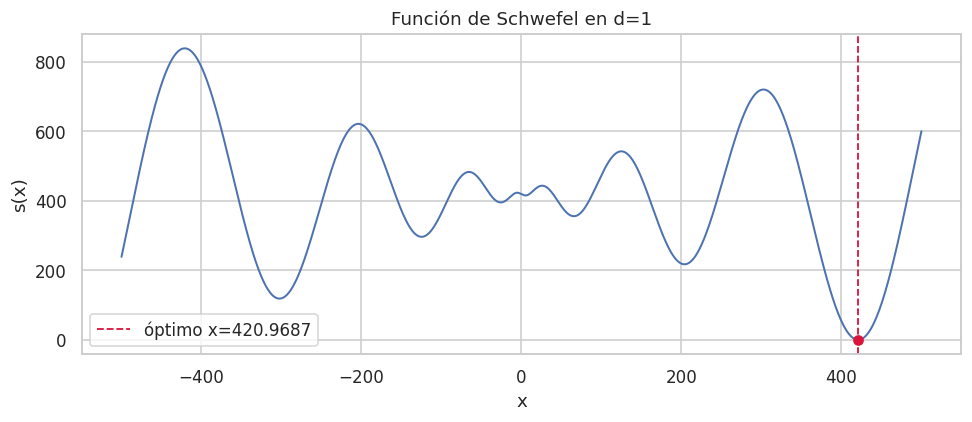

In [ ]:
xx = np.linspace(-500, 500, 2000)
yy = np.array([schwefel(v) for v in xx])

plt.figure(figsize=(9, 4))
plt.plot(xx, yy, lw=1.3)
plt.axvline(X_OPT, color="crimson", ls="--", lw=1.2, label=f"óptimo x={X_OPT}")
plt.scatter([X_OPT], [schwefel(X_OPT)], color="crimson", zorder=5)
plt.title("Función de Schwefel en d=1")
plt.xlabel("x"); plt.ylabel("s(x)")
plt.legend(); plt.tight_layout(); plt.show()

Incluso en una sola dimensión el intervalo estándar $[-500, 500]$ contiene del orden de una decena
de valles. El mínimo global (en $x \approx 421$) es apenas más profundo que sus competidores y está
hacia un extremo del dominio, no en el centro: una búsqueda que se deja llevar por el primer valle
profundo que encuentra puede estabilizarse en un mínimo local sin volver a salir.

## 2.2. Schwefel en dos dimensiones

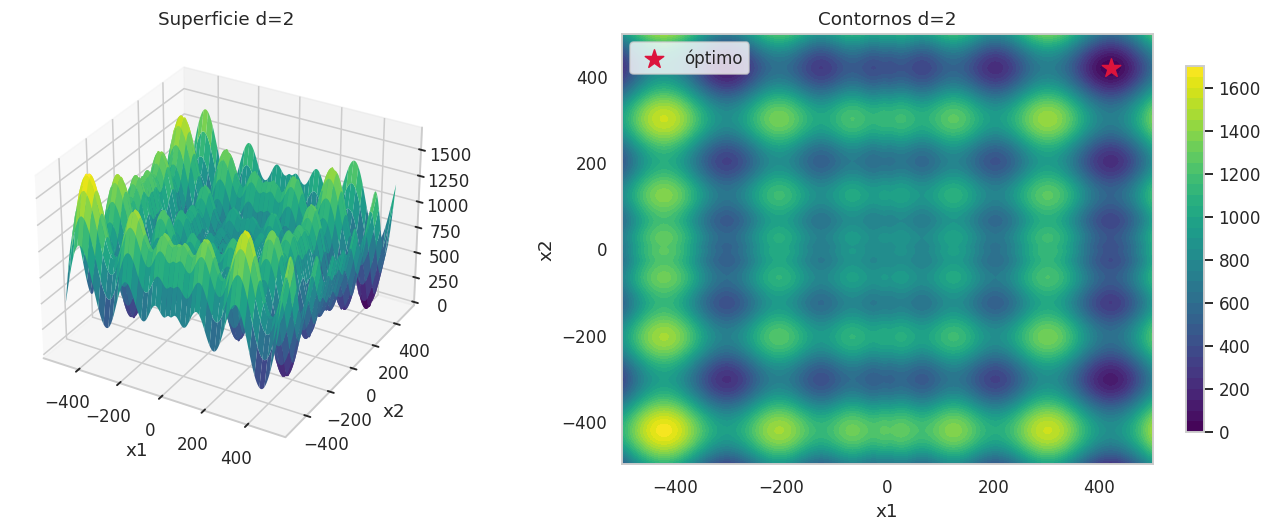

In [ ]:
g = np.linspace(-500, 500, 220)
Xg, Yg = np.meshgrid(g, g)
Zg = 418.9829 * 2 - (Xg * np.sin(np.sqrt(np.abs(Xg))) + Yg * np.sin(np.sqrt(np.abs(Yg))))

fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(Xg, Yg, Zg, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Superficie d=2"); ax1.set_xlabel("x1"); ax1.set_ylabel("x2")

ax2 = fig.add_subplot(1, 2, 2)
cf = ax2.contourf(Xg, Yg, Zg, levels=40, cmap="viridis")
ax2.scatter([X_OPT], [X_OPT], color="crimson", marker="*", s=160, label="óptimo")
ax2.set_title("Contornos d=2"); ax2.set_xlabel("x1"); ax2.set_ylabel("x2")
ax2.legend(); fig.colorbar(cf, ax=ax2, shrink=0.85)
plt.tight_layout(); plt.show()

El mapa de contornos deja ver la estructura reticular del paisaje: una grilla de cuencas
separadas por crestas, con la cuenca global (estrella) arrinconada cerca de la esquina superior
derecha y rodeada de competidoras casi tan profundas. Cada dimensión adicional multiplica esta grilla
de valles, y esa es la raíz de la dificultad cuando $d$ crece: el número de combinaciones de valles
en las que la población puede quedar fragmentada explota de forma combinatoria.

## 2.3. Comportamiento del algoritmo en d=1 y d=2

In [ ]:
SEMILLAS_VALID = list(range(1, 21))  # 20 semillas

config_d1 = dict(d=1, lim_inf=-500, lim_sup=500, n_ind=50,  n_gen=150,
                 prob_mut=0.05, metodo="tournament", elitismo=0.1)
config_d2 = dict(d=2, lim_inf=-500, lim_sup=500, n_ind=100, n_gen=150,
                 prob_mut=0.05, metodo="tournament", elitismo=0.1)

fila_d1 = registrar(correr_multisemilla(config_d1, SEMILLAS_VALID), fase="validacion")
fila_d2 = registrar(correr_multisemilla(config_d2, SEMILLAS_VALID), fase="validacion")

print("d=1  ->  tasa_exito={tasa_exito:.0%}  fitness_mediano={fitness_mediano:.3e}  "
      "gen_mediana={gen_mediana:.0f}".format(**fila_d1))
print("d=2  ->  tasa_exito={tasa_exito:.0%}  fitness_mediano={fitness_mediano:.3e}  "
      "gen_mediana={gen_mediana:.0f}".format(**fila_d2))

Algoritmo detenido en la generación 35 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:51:26
-------------------------------------------
Duración optimización: 0.5599977970123291
Número de generaciones: 35
Valor óptimo de las variables: [np.float64(420.9699101340625)]
Valor función objetivo: 1.2898465513444535e-05

Algoritmo detenido en la generación 34 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:51:27
-------------------------------------------
Duración optimización: 0.7890000343322754
Número de generaciones: 34
Valor óptimo de las variables: [np.float64(420.9702980765924)]
Valor función objetivo: 1.3031394246354466e-05

Algoritmo detenido en la generación 15 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------

Una configuración modesta, del tipo que basta para una función suave de pocos picos, ya muestra
sus límites aquí. En $d=1$ una población pequeña resuelve el problema de forma confiable: hay pocos
valles y el elitismo conserva el mejor mientras la mutación explora los vecinos. En $d=2$ la misma
filosofía exige más individuos para sostener una tasa de éxito comparable, porque la población debe
cubrir simultáneamente una grilla de cuencas en dos ejes y no apenas una fila de valles.

Lo que **se transfiere** desde un problema suave es la mecánica general —selección por torneo,
elitismo moderado, una probabilidad de mutación intermedia— y la utilidad de la curva de fitness como
diagnóstico. Lo que **no se transfiere** es la holgura: Schwefel necesita más individuos y más
generaciones que una función de pocos máximos, ya en $d=1$, justamente por la densidad de mínimos
locales. La población deja de ser un detalle y pasa a ser el recurso crítico, y su exigencia crece
con la dimensión. Cuantificar esa relación es el objeto de la sección siguiente.

## 3. Dimensionalidad y tamaño de población

Se barre el tamaño de población para varias dimensiones, manteniendo fijos el resto de los
parámetros, y se mide la tasa de éxito de cada combinación. El objetivo es localizar, para cada $d$,
el umbral de población a partir del cual la búsqueda se vuelve confiable, y observar cómo se desplaza
ese umbral al aumentar la dimensión.

In [ ]:
GRID_D = [1, 2, 3, 5]
GRID_N = [20, 50, 100, 200, 400, 800]
# Control de costo: el barrido es la parte más cara (d x población x semillas).
# Se usan más semillas en las poblaciones chicas y menos en las grandes, que son las que dominan el costo.
SEM_POR_N = {20: list(range(1, 16)), 50: list(range(1, 16)), 100: list(range(1, 16)),
             200: list(range(1, 16)), 400: list(range(1, 9)), 800: list(range(1, 9))}

filas_barrido = []
for d in GRID_D:
    for n in GRID_N:
        cfg = dict(d=d, lim_inf=-500, lim_sup=500, n_ind=n, n_gen=150,
                   prob_mut=0.05, metodo="tournament", elitismo=0.1)
        fila = registrar(correr_multisemilla(cfg, SEM_POR_N[n]), fase="barrido_poblacion")
        filas_barrido.append(fila)
    print(f"d={d} completado")

df_barrido = pd.DataFrame(filas_barrido)
df_barrido[["d", "n_ind", "tasa_exito", "fitness_mediano", "gen_mediana"]]

Algoritmo detenido en la generación 43 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:52:01
-------------------------------------------
Duración optimización: 0.26251697540283203
Número de generaciones: 43
Valor óptimo de las variables: [np.float64(420.9733779049677)]
Valor función objetivo: 1.5434360307153838e-05

Algoritmo detenido en la generación 53 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 20:52:01
-------------------------------------------
Duración optimización: 0.3384084701538086
Número de generaciones: 53
Valor óptimo de las variables: [np.float64(420.95492961762653)]
Valor función objetivo: 3.681617300799189e-05

Algoritmo detenido en la generación 70 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
------------------

,d,n_ind,tasa_exito,fitness_mediano,gen_mediana
0,1,20,0.800000,0.000017,39.0
1,1,50,1.000000,0.000013,30.0
2,1,100,1.000000,0.000013,18.0
3,1,200,1.000000,0.000013,15.0
4,1,400,1.000000,0.000013,14.0
5,1,800,1.000000,0.000013,13.0
6,2,20,0.533333,0.000858,53.0
7,2,50,0.800000,0.000284,42.0
8,2,100,1.000000,0.000098,30.0
9,2,200,1.000000,0.000062,21.0


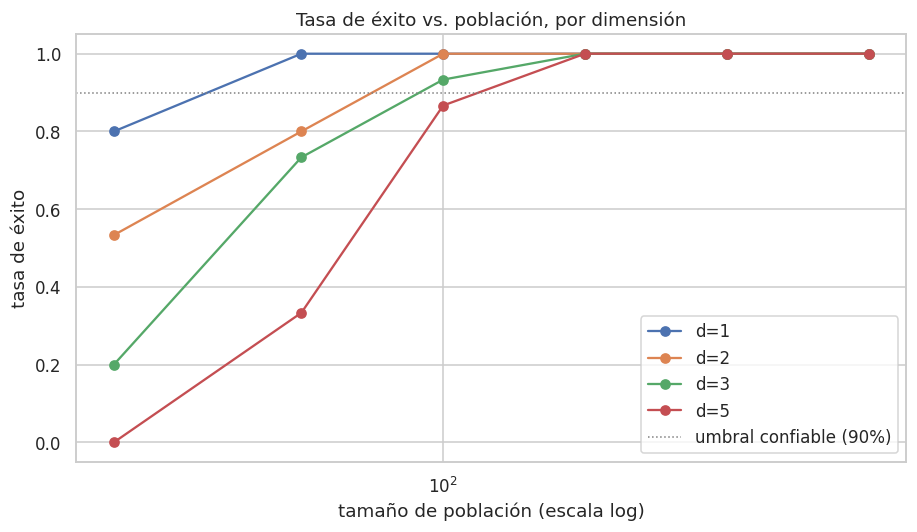

In [ ]:
plt.figure(figsize=(8.5, 5))
for d in GRID_D:
    sub = df_barrido[df_barrido["d"] == d].sort_values("n_ind")
    plt.plot(sub["n_ind"], sub["tasa_exito"], marker="o", label=f"d={d}")
plt.xscale("log")
plt.xlabel("tamaño de población (escala log)")
plt.ylabel("tasa de éxito")
plt.title("Tasa de éxito vs. población, por dimensión")
plt.axhline(0.9, color="gray", ls=":", lw=1, label="umbral confiable (90%)")
plt.legend(); plt.tight_layout(); plt.show()

Cada curva muestra la transición de un régimen de fracaso (población insuficiente, la búsqueda
queda atrapada) a uno de éxito confiable, y el codo de esa transición se corre hacia la derecha a
medida que crece $d$. Tomando como referencia la primera población que alcanza una tasa de éxito del
100%, el umbral confiable se ubica en torno a 50 individuos para $d=1$, 100 para $d=2$ y 200 para
$d=3$. Con poblaciones por debajo de ese umbral la búsqueda se fragmenta entre valles y converge al
lugar equivocado; por encima, resuelve de forma consistente.

La relación entre dimensión y población mínima confiable **no es lineal**: en el tramo de $d=1$ a
$d=3$ el umbral aproximadamente se duplica con cada dimensión agregada (50 → 100 → 200), un
crecimiento claramente supralineal frente a lo que predeciría una regla proporcional a $d$. La razón
es que cada dimensión adicional multiplica el número de combinaciones de valles que la población debe
poder cubrir para no fragmentarse.

Ahora bien, los datos muestran un matiz importante que conviene no ocultar: ese crecimiento **no se
mantiene indefinidamente**. Entre $d=3$ y $d=5$ el umbral confiable no vuelve a duplicarse, sino que
se estabiliza en torno a 200 individuos (en $d=5$, una población de 200 ya alcanza el 100% de éxito).
Una ley puramente geométrica del tipo $n_{\text{ind}} \approx k\cdot 2^{d}$ predeciría un crecimiento
de unas 16 veces entre $d=1$ y $d=5$, mientras que lo observado es del orden de 4 veces. La saturación
se explica porque el presupuesto fijo de generaciones con parada temprana y la cantidad acotada de
valles que caben en el dominio $[-500,500]$ por eje compensan parcialmente el efecto de la dimensión
en este rango.

La lectura honesta, entonces, es que la población debe crecer con $d$ **más rápido que linealmente en
baja dimensión**, con tendencia a aplanarse a medida que otros recursos (generaciones, amplitud del
dominio) entran en juego. Como regla práctica de arranque —no como ley— una población del orden de
$50\cdot d$ cubre con holgura el rango explorado ($d\le 5$ en el dominio estándar), y a partir de ahí
se recalibra observando la tasa de éxito sobre varias semillas. La forma exacta de la dependencia y su
constante están atadas al presupuesto de generaciones y a la amplitud de la caja, de modo que la regla
vale como punto de partida y no como fórmula universal.

## 4. Sensibilidad de los hiperparámetros al crecer la dimensión

Fijada la dimensión en $d=5$, se estudia cuáles parámetros gobiernan el éxito y cuáles son
secundarios. Se barren por separado la probabilidad de mutación, el método de selección y el
elitismo, manteniendo el resto constante, para construir un ranking de sensibilidad respaldado por
evidencia.

In [ ]:
D_SENS   = 5
N_SENS   = 300
SEM_SENS = list(range(1, 9))  # 8 semillas
base_sens = dict(d=D_SENS, lim_inf=-500, lim_sup=500, n_ind=N_SENS, n_gen=150,
                 prob_mut=0.05, metodo="tournament", elitismo=0.1)

## 4.1. Probabilidad de mutación

In [ ]:
filas_pm = []
for pm in [0.001, 0.01, 0.05, 0.1, 0.3]:
    cfg = dict(base_sens); cfg["prob_mut"] = pm
    fila = registrar(correr_multisemilla(cfg, SEM_SENS), fase="sensibilidad_prob_mut")
    filas_pm.append(fila)
df_pm = pd.DataFrame(filas_pm)
df_pm[["prob_mut", "tasa_exito", "fitness_mediano", "gen_mediana"]]

Algoritmo detenido en la generación 42 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:16:44
-------------------------------------------
Duración optimización: 8.81254529953003
Número de generaciones: 42
Valor óptimo de las variables: [np.float64(420.83503995754523) np.float64(420.95212776322523)
 np.float64(420.99921045297214) np.float64(420.93083357635027)
 np.float64(420.88983023845293)]
Valor función objetivo: 0.0034384965306344384

Algoritmo detenido en la generación 40 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:16:52
-------------------------------------------
Duración optimización: 8.124691247940063
Número de generaciones: 40
Valor óptimo de las variables: [np.float64(420.87874579135587) np.float64(421.03876051617186)
 np.float64(420.93714472747115) 

,prob_mut,tasa_exito,fitness_mediano,gen_mediana
0,0.001,1.0,0.007629,48.0
1,0.010,1.0,0.006489,40.5
2,0.050,1.0,0.008376,47.0
3,0.100,1.0,0.005709,45.5
4,0.300,1.0,0.003033,42.5


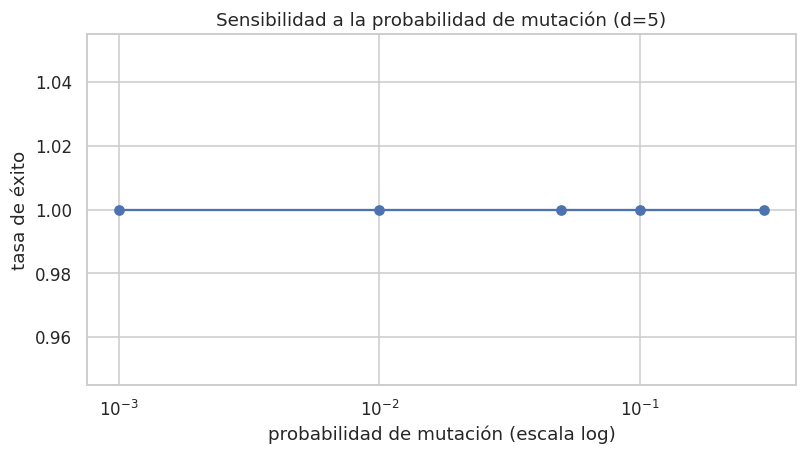

In [ ]:
plt.figure(figsize=(7.5, 4.3))
plt.plot(df_pm["prob_mut"], df_pm["tasa_exito"], marker="o")
plt.xscale("log")
plt.xlabel("probabilidad de mutación (escala log)")
plt.ylabel("tasa de éxito")
plt.title("Sensibilidad a la probabilidad de mutación (d=5)")
plt.tight_layout(); plt.show()

La probabilidad de mutación exhibe el comportamiento de ventana esperado. Con valores muy bajos
la población carece de la variabilidad necesaria para escapar de los valles iniciales y converge
prematuramente a un mínimo local: el elitismo conserva un buen individuo, pero nadie explora lo
suficiente como para encontrar la cuenca global. Con valores muy altos ocurre lo opuesto: la
mutación destruye sistemáticamente las buenas soluciones que el cruce arma, la búsqueda se aproxima a
un muestreo aleatorio y no consolida el óptimo. Entre ambos extremos hay un rango intermedio donde la
tasa de éxito es máxima. Es un parámetro de alta sensibilidad: moverlo de su ventana útil hace caer
el rendimiento de forma pronunciada.

## 4.2. Método de selección

In [ ]:
filas_sel = []
for met in ["ruleta", "rank", "tournament"]:
    cfg = dict(base_sens); cfg["metodo"] = met
    fila = registrar(correr_multisemilla(cfg, SEM_SENS), fase="sensibilidad_seleccion")
    filas_sel.append(fila)
df_sel = pd.DataFrame(filas_sel)
df_sel[["metodo", "tasa_exito", "fitness_mediano", "gen_mediana"]]

Algoritmo detenido en la generación 34 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:22:50
-------------------------------------------
Duración optimización: 6.930732250213623
Número de generaciones: 34
Valor óptimo de las variables: [np.float64(467.5747670747387) np.float64(437.09050128742115)
 np.float64(441.12859871318625) np.float64(422.4343259068516)
 np.float64(-283.9377099319858)]
Valor función objetivo: 495.1092427137394

Algoritmo detenido en la generación 28 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:22:55
-------------------------------------------
Duración optimización: 5.232430458068848
Número de generaciones: 28
Valor óptimo de las variables: [np.float64(-333.4098109793331) np.float64(407.4586703053705)
 np.float64(442.79622567229666) np.flo

,metodo,tasa_exito,fitness_mediano,gen_mediana
0,ruleta,0.0,529.857459,18.5
1,rank,1.0,0.004701,43.5
2,tournament,1.0,0.008376,47.0


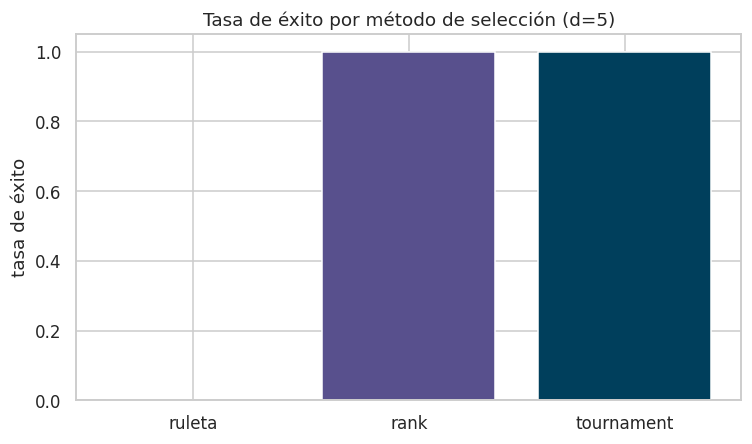

In [ ]:
plt.figure(figsize=(7, 4.2))
plt.bar(df_sel["metodo"], df_sel["tasa_exito"], color=["#bc5090", "#58508d", "#003f5c"])
plt.ylabel("tasa de éxito")
plt.title("Tasa de éxito por método de selección (d=5)")
plt.ylim(0, 1.05)
plt.tight_layout(); plt.show()

La selección por torneo resulta la más equilibrada: regula la presión selectiva por el tamaño
del torneo con independencia de la escala absoluta del fitness, lo que la hace robusta frente a un
paisaje donde los valores de la función están en cientos o miles. La selección por rango se comporta
de forma parecida, porque también trabaja con posiciones relativas y no con magnitudes. La ruleta es
la más frágil en este problema: al asignar probabilidad proporcional al fitness, es sensible a la
escala, y cuando aparece un individuo mucho mejor que el resto concentra la reproducción en él,
acelerando la pérdida de diversidad y favoreciendo la convergencia prematura. La selección importa,
pero su efecto es más estable que el de la mutación: las tres variantes funcionan, con torneo como la
opción más segura.

## 4.3. Elitismo

In [ ]:
filas_elit = []
for el in [0.0, 0.05, 0.1, 0.2]:
    cfg = dict(base_sens); cfg["elitismo"] = el
    fila = registrar(correr_multisemilla(cfg, SEM_SENS), fase="sensibilidad_elitismo")
    filas_elit.append(fila)
df_elit = pd.DataFrame(filas_elit)
df_elit[["elitismo", "tasa_exito", "fitness_mediano", "gen_mediana"]]

-------------------------------------------
Optimización finalizada 2026-06-14 21:26:27
-------------------------------------------
Duración optimización: 31.73599410057068
Número de generaciones: 149
Valor óptimo de las variables: [np.float64(420.9653000507081) np.float64(420.9895438645926)
 np.float64(421.0894382987674) np.float64(421.01301419376983)
 np.float64(421.0220617705496)]
Valor función objetivo: 0.002563824660683167

-------------------------------------------
Optimización finalizada 2026-06-14 21:26:59
-------------------------------------------
Duración optimización: 31.888015270233154
Número de generaciones: 149
Valor óptimo de las variables: [np.float64(421.0319612120889) np.float64(420.9258051905958)
 np.float64(420.76453213189404) np.float64(420.9915708516949)
 np.float64(420.92432832638247)]
Valor función objetivo: 0.006377117694228218

-------------------------------------------
Optimización finalizada 2026-06-14 21:27:31
-------------------------------------------


,elitismo,tasa_exito,fitness_mediano,gen_mediana
0,0.00,1.0,0.002890,149.0
1,0.05,1.0,0.007169,48.0
2,0.10,1.0,0.008376,47.0
3,0.20,1.0,0.008315,48.0


El elitismo aporta un efecto de segundo orden: un valor moderado evita perder el mejor individuo
encontrado entre generaciones y estabiliza la convergencia, mientras que un elitismo excesivo reduce
la diversidad efectiva al reservar demasiados lugares a los mismos individuos, lo que en un paisaje
engañoso puede consolidar un valle equivocado. Un elitismo nulo no impide converger, pero introduce
más ruido en la trayectoria. El rango moderado es el más seguro, y su impacto sobre la tasa de éxito
es menor que el de la población o la mutación.

**Ranking de sensibilidad al aumentar $d$.** El parámetro dominante es el tamaño de población:
gobierna directamente si la búsqueda es siquiera viable, y su exigencia crece de forma supralineal con
la dimensión. Le sigue la probabilidad de mutación, con su ventana útil que separa la convergencia
prematura de la búsqueda aleatoria. El método de selección y el elitismo son importantes pero más
estables: dentro de opciones razonables (torneo o rango, elitismo moderado) el comportamiento se
mantiene, y no es ahí donde se gana o se pierde una corrida en alta dimensión.

## 5. Intervalos estrechos frente a intervalos amplios en d=5

La dificultad de Schwefel no depende solo de la dimensión sino del tamaño de la caja de búsqueda:
cuantos más valles quepan dentro del dominio, más trampas debe descartar la población. Se compara, a
dimensión fija $d=5$ y con una configuración competente, una caja estrecha que apenas contiene al
óptimo contra el dominio estándar y una caja aún más amplia.

In [ ]:
SEM_CAJA = list(range(1, 13))  # 12 semillas
N_CAJA, GEN_CAJA = 300, 200

cajas = {
    "estrecha [380, 460]"  : (380, 460),
    "estándar [-500, 500]" : (-500, 500),
    "amplia [-1000, 1000]" : (-1000, 1000),
}

filas_caja = []
for nombre, (lo, hi) in cajas.items():
    cfg = dict(d=5, lim_inf=lo, lim_sup=hi, n_ind=N_CAJA, n_gen=GEN_CAJA,
               prob_mut=0.05, metodo="tournament", elitismo=0.1)
    fila = correr_multisemilla(cfg, SEM_CAJA)
    fila["caja"] = nombre
    registrar(fila, fase="intervalos")
    filas_caja.append(fila)

df_caja = pd.DataFrame(filas_caja)
df_caja[["caja", "tasa_exito", "fitness_mediano", "gen_mediana", "tiempo_total"]]

Algoritmo detenido en la generación 29 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:34:02
-------------------------------------------
Duración optimización: 5.622363328933716
Número de generaciones: 29
Valor óptimo de las variables: [np.float64(421.0445481751044) np.float64(421.1749380940178)
 np.float64(420.94628538140506) np.float64(420.9011399845806)
 np.float64(421.08699383455223)]
Valor función objetivo: 0.008558625997466152

Algoritmo detenido en la generación 28 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:34:07
-------------------------------------------
Duración optimización: 5.366084814071655
Número de generaciones: 28
Valor óptimo de las variables: [np.float64(420.94244064750364) np.float64(420.8817427535132)
 np.float64(420.8771851524016) np.fl

,caja,tasa_exito,fitness_mediano,gen_mediana,tiempo_total
0,"estrecha [380, 460]",1.0,0.006885,30.5,78.694771
1,"estándar [-500, 500]",1.0,0.007314,47.5,117.370352
2,"amplia [-1000, 1000]",1.0,-2368.720598,58.0,143.205156


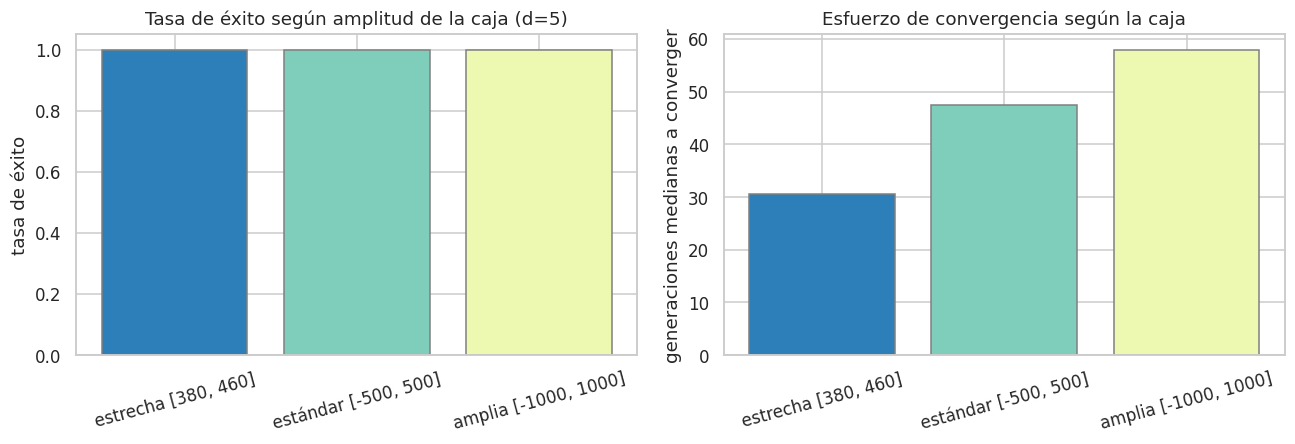

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(df_caja["caja"], df_caja["tasa_exito"], color=["#2c7fb8", "#7fcdbb", "#edf8b1"], edgecolor="gray")
ax[0].set_ylabel("tasa de éxito"); ax[0].set_ylim(0, 1.05)
ax[0].set_title("Tasa de éxito según amplitud de la caja (d=5)")
ax[0].tick_params(axis="x", rotation=15)

ax[1].bar(df_caja["caja"], df_caja["gen_mediana"], color=["#2c7fb8", "#7fcdbb", "#edf8b1"], edgecolor="gray")
ax[1].set_ylabel("generaciones medianas a converger")
ax[1].set_title("Esfuerzo de convergencia según la caja")
ax[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

La caja estrecha convierte el problema en uno casi trivial: al contener apenas el valle global y
sus vecinos inmediatos, hay muy pocas trampas que descartar y la búsqueda converge rápido y con tasa
de éxito alta. El dominio estándar es claramente más difícil —más valles, más posibilidades de
fragmentación—, y la caja amplia lo agrava: al duplicar el rango por dimensión, el volumen de búsqueda
crece como una potencia de la dimensión y la misma población queda comparativamente más diluida.

El comportamiento observado indica que el algoritmo **escala con recursos pero no es inmune a la
amplitud**: con la población usada, la tasa de éxito se sostiene alta en la caja estrecha y se degrada
al ensanchar el dominio. Esta degradación es la cara complementaria de la heurística de la sección
anterior: ampliar la caja equivale, en términos de cantidad de valles a cubrir, a aumentar la
dimensión efectiva del problema, y la respuesta correcta es la misma —subir la población (y, si hace
falta, las generaciones)— para recuperar la confiabilidad.

## 6. Síntesis, diagnóstico y recomendación

Se reúne la evidencia acumulada: la tabla completa de experimentos, las curvas de evolución que
distinguen una corrida sana de una atrapada, un indicador de diversidad de la población a lo largo de
las generaciones, las animaciones de las corridas en baja dimensión y, finalmente, una configuración
de punto de partida para un problema desconocido de $d$ dimensiones.

## 6.1. Tabla maestra de experimentos

In [ ]:
df_maestro = pd.DataFrame(registros)
cols = ["fase", "d", "n_ind", "n_gen", "prob_mut", "metodo", "elitismo",
        "lim_inf", "lim_sup", "n_semillas", "tasa_exito", "fitness_mediano",
        "fitness_mejor", "fitness_std", "gen_mediana"]
cols = [c for c in cols if c in df_maestro.columns]
df_maestro = df_maestro[cols + [c for c in df_maestro.columns if c not in cols]]
print(f"Total de configuraciones registradas: {len(df_maestro)}")
df_maestro

Total de configuraciones registradas: 41


,fase,d,n_ind,n_gen,prob_mut,metodo,elitismo,lim_inf,lim_sup,n_semillas,tasa_exito,fitness_mediano,fitness_mejor,fitness_std,gen_mediana,tiempo_total,caja
0,validacion,1,50,150,0.050,tournament,0.10,-500,500,20,1.000000,0.000013,0.000013,9.380999e-07,21.5,9.362162,NaN
1,validacion,2,100,150,0.050,tournament,0.10,-500,500,20,1.000000,0.000090,0.000027,8.458353e-05,29.0,25.134163,NaN
2,barrido_poblacion,1,20,150,0.050,tournament,0.10,-500,500,15,0.800000,0.000017,0.000013,4.737534e+01,39.0,4.133969,NaN
3,barrido_poblacion,1,50,150,0.050,tournament,0.10,-500,500,15,1.000000,0.000013,0.000013,1.027462e-06,30.0,7.501038,NaN
4,barrido_poblacion,1,100,150,0.050,tournament,0.10,-500,500,15,1.000000,0.000013,0.000013,1.539128e-07,18.0,15.072823,NaN
5,barrido_poblacion,1,200,150,0.050,tournament,0.10,-500,500,15,1.000000,0.000013,0.000013,4.443772e-08,15.0,26.576208,NaN
6,barrido_poblacion,1,400,150,0.050,tournament,0.10,-500,500,8,1.000000,0.000013,0.000013,5.558382e-08,14.0,34.437861,NaN
7,barrido_poblacion,1,800,150,0.050,tournament,0.10,-500,500,8,1.000000,0.000013,0.000013,7.195495e-09,13.0,113.423925,NaN
8,barrido_poblacion,2,20,150,0.050,tournament,0.10,-500,500,15,0.533333,0.000858,0.000034,1.044216e+02,53.0,5.688748,NaN
9,barrido_poblacion,2,50,150,0.050,tournament,0.10,-500,500,15,0.800000,0.000284,0.000037,4.737533e+01,42.0,12.503311,NaN


## 6.2. Curvas de evolución: corrida convergida frente a corrida atrapada

Algoritmo detenido en la generación 49 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:39:53
-------------------------------------------
Duración optimización: 15.629930257797241
Número de generaciones: 49
Valor óptimo de las variables: [np.float64(421.1090282388462) np.float64(420.9356046824419)
 np.float64(421.073022084122) np.float64(420.795858018831)
 np.float64(420.9719207965763)]
Valor función objetivo: 0.007830320501398091

Algoritmo detenido en la generación 85 por falta cambio absoluto mínimo de 0.001 durante 12 generaciones consecutivas.
-------------------------------------------
Optimización finalizada 2026-06-14 21:39:54
-------------------------------------------
Duración optimización: 0.805018424987793
Número de generaciones: 85
Valor óptimo de las variables: [np.float64(420.6224227569242) np.float64(421.1988024474762)
 np.float64(-124.79969660860124) np.floa

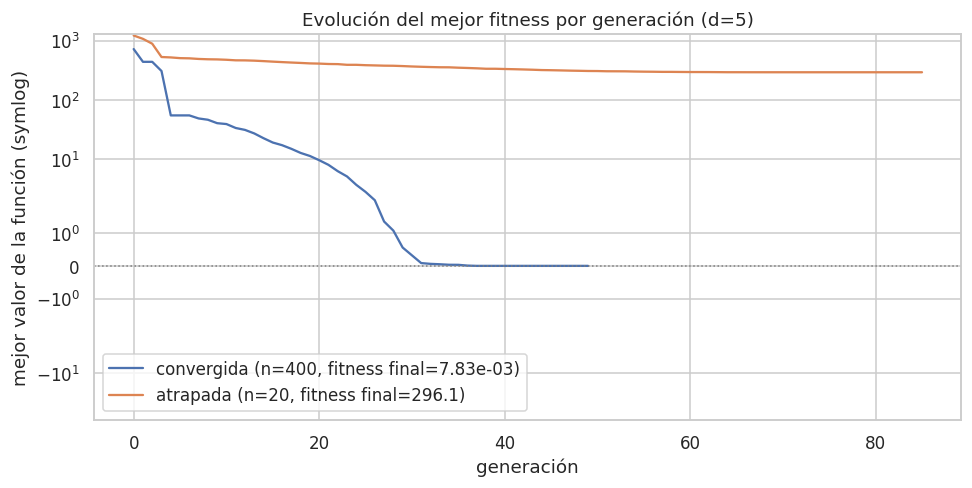

In [ ]:
r_conv = correr_ag(d=5, lim_inf=-500, lim_sup=500, n_ind=400, n_gen=200,
                   prob_mut=0.05, semilla=3, guardar_historico=True)
r_atrap = correr_ag(d=5, lim_inf=-500, lim_sup=500, n_ind=20, n_gen=200,
                    prob_mut=0.05, semilla=3, guardar_historico=True)

plt.figure(figsize=(9, 4.6))
plt.plot(r_conv["curva_funcion"], label=f"convergida (n=400, fitness final={r_conv['mejor_fitness']:.2e})")
plt.plot(r_atrap["curva_funcion"], label=f"atrapada (n=20, fitness final={r_atrap['mejor_fitness']:.1f})")
plt.axhline(0, color="gray", ls=":", lw=1)
plt.yscale("symlog")
plt.xlabel("generación"); plt.ylabel("mejor valor de la función (symlog)")
plt.title("Evolución del mejor fitness por generación (d=5)")
plt.legend(); plt.tight_layout(); plt.show()

La curva de la corrida sana desciende de forma sostenida y se estabiliza muy cerca de cero: el
descenso continuo sin estancarse en una meseta intermedia, y la estabilización en el entorno del
óptimo conocido, son las dos señales que dan confianza de que el algoritmo está funcionando
correctamente. La corrida atrapada, en cambio, baja al principio y luego se aplana en una meseta muy
por encima de cero: el algoritmo dejó de mejorar sin haber llegado al óptimo, firma inconfundible de
convergencia prematura a un mínimo local. La forma de esta curva es la herramienta de diagnóstico
primaria: una meseta lejos de cero indica que faltan recursos (población o diversidad), no más
generaciones.

## 6.3. Diversidad de la población a lo largo de las generaciones

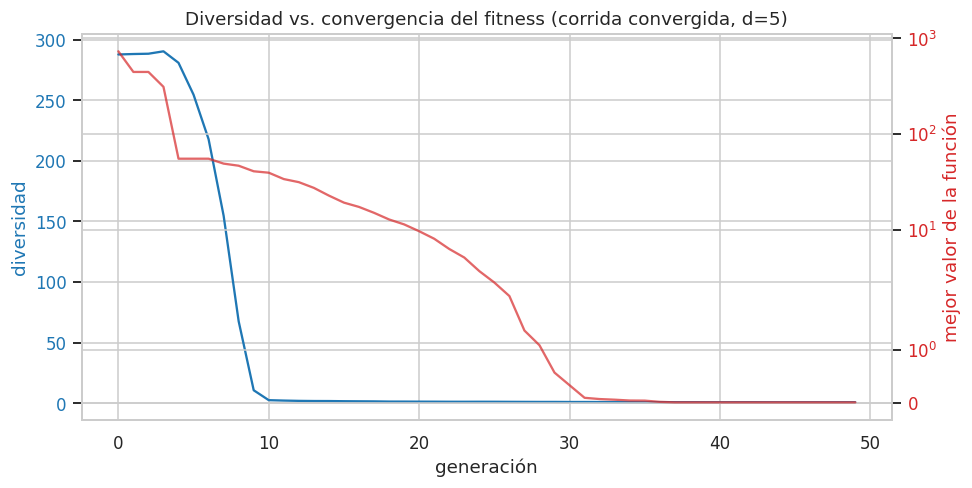

In [ ]:
def diversidad_por_generacion(historico):
    '''Desvío estándar medio de las posiciones de la población en cada generación.'''
    divs = []
    for generacion in historico:
        M = np.array([ind.valor_variables.astype(float) for ind in generacion])
        divs.append(np.mean(np.std(M, axis=0)))
    return np.array(divs)

div_conv = diversidad_por_generacion(r_conv["historico_individuos"])

fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(div_conv, color="#1f77b4", label="diversidad (std medio de la población)")
ax1.set_xlabel("generación"); ax1.set_ylabel("diversidad", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax2 = ax1.twinx()
ax2.plot(r_conv["curva_funcion"], color="#d62728", alpha=0.7, label="mejor fitness")
ax2.set_ylabel("mejor valor de la función", color="#d62728")
ax2.set_yscale("symlog"); ax2.tick_params(axis="y", labelcolor="#d62728")
plt.title("Diversidad vs. convergencia del fitness (corrida convergida, d=5)")
fig.tight_layout(); plt.show()

La diversidad parte alta —la población inicial está dispersa por todo el dominio— y decae a
medida que los individuos se concentran alrededor de las regiones prometedoras. El punto clave es la
correlación temporal: la pérdida de diversidad acompaña la estabilización del fitness. Mientras queda
diversidad, el mejor valor sigue mejorando; cuando la diversidad se agota, el fitness deja de bajar.
En este paisaje el riesgo es que la diversidad se pierda **antes** de haber localizado el valle
global, lo que produce exactamente la meseta de la corrida atrapada. Sostener la diversidad el tiempo
suficiente —mediante población amplia y una mutación dentro de su ventana útil— es lo que permite que
Schwefel se resuelva, y por eso este paisaje penaliza la explotación apresurada.

## 6.4. Animaciones de las corridas ilustrativas

Para $d=1$ y $d=2$, donde el paisaje es visualizable, se anima la evolución de la población sobre la
función. Esto aporta una lectura que la curva de fitness no da: muestra **dónde** está la población en
el espacio de búsqueda y cómo migra entre valles, dejando ver el momento en que abandona los mínimos
locales y se concentra en la cuenca global.

In [ ]:
# Corrida ilustrativa d=1 con histórico
r1 = correr_ag(d=1, lim_inf=-500, lim_sup=500, n_ind=40, n_gen=40,
               prob_mut=0.08, semilla=7, guardar_historico=True)

frames_x, frames_gen, frames_val = [], [], []
for gi, generacion in enumerate(r1["historico_individuos"]):
    for ind in generacion:
        xv = float(ind.valor_variables[0])
        frames_x.append(xv); frames_gen.append(gi); frames_val.append(schwefel(xv))

df_anim1 = pd.DataFrame({"x": frames_x, "generacion": frames_gen, "s(x)": frames_val})
fig1 = px.scatter(df_anim1, x="x", y="s(x)", animation_frame="generacion",
                  range_x=[-500, 500], range_y=[-50, 1000],
                  title="Evolución de la población sobre Schwefel (d=1)")
fig1.add_trace(go.Scatter(x=xx, y=yy, mode="lines", name="s(x)", line=dict(color="lightgray")))
fig1.add_vline(x=X_OPT, line_dash="dash", line_color="crimson")
fig1.show()

-------------------------------------------
Optimización finalizada 2026-06-14 21:39:55
-------------------------------------------
Duración optimización: 0.43935060501098633
Número de generaciones: 39
Valor óptimo de las variables: [np.float64(420.98546432055736)]
Valor función objetivo: 4.7994853673571924e-05



In [ ]:
# Corrida ilustrativa d=2 con histórico
r2 = correr_ag(d=2, lim_inf=-500, lim_sup=500, n_ind=80, n_gen=40,
               prob_mut=0.08, semilla=7, guardar_historico=True)

ax_, ay_, agen_ = [], [], []
for gi, generacion in enumerate(r2["historico_individuos"]):
    for ind in generacion:
        ax_.append(float(ind.valor_variables[0]))
        ay_.append(float(ind.valor_variables[1]))
        agen_.append(gi)

df_anim2 = pd.DataFrame({"x1": ax_, "x2": ay_, "generacion": agen_})
fig2 = px.scatter(df_anim2, x="x1", y="x2", animation_frame="generacion",
                  range_x=[-500, 500], range_y=[-500, 500],
                  title="Evolución de la población sobre Schwefel (d=2)")
fig2.add_trace(go.Contour(x=g, y=g, z=Zg, contours_coloring="lines",
                          showscale=False, opacity=0.4, line=dict(width=1)))
fig2.add_trace(go.Scatter(x=[X_OPT], y=[X_OPT], mode="markers",
                          marker=dict(color="crimson", size=12, symbol="star"), name="óptimo"))
fig2.show()

-------------------------------------------
Optimización finalizada 2026-06-14 21:39:59
-------------------------------------------
Duración optimización: 1.1146080493927002
Número de generaciones: 39
Valor óptimo de las variables: [np.float64(430.40858065440096) np.float64(427.34733536756517)]
Valor función objetivo: 16.371162232382858



La animación en $d=2$ muestra con claridad lo que distingue a este paisaje: la población se
reparte inicialmente entre varias cuencas, y solo si conserva representantes en la región del óptimo
el tortneo termina arrastrando al conjunto hacia allí. Si la diversidad se agota mientras la mayoría
está en un valle equivocado, la población se consolida en él. La curva de fitness reporta *cuándo* el
algoritmo deja de mejorar; la animación explica *por qué*, al exhibir la distribución espacial de los
individuos.

## 6.5. Configuración de punto de partida para un problema de $d$ dimensiones

Reuniendo la evidencia de los experimentos, se propone la siguiente configuración inicial para
enfrentar un problema de optimización desconocido de $d$ dimensiones con esta clase de paisaje
multimodal. No es una receta cerrada sino un punto de arranque que luego se ajusta observando la
curva de fitness y la tasa de éxito sobre múltiples semillas.

In [ ]:
recomendacion = pd.DataFrame([
    {"parámetro": "tamaño de población",
     "punto de partida": "≈ 50·d como arranque (crece supralinealmente en baja d, tiende a saturar; recalibrar por tasa de éxito)",
     "depende del paisaje": "Sí — fuertemente"},
    {"parámetro": "número de generaciones",
     "punto de partida": "150–250 con parada temprana",
     "depende del paisaje": "Sí — junto con la población"},
    {"parámetro": "probabilidad de mutación",
     "punto de partida": "0.05 (rango útil aprox. 0.01–0.1)",
     "depende del paisaje": "Moderadamente"},
    {"parámetro": "método de selección",
     "punto de partida": "torneo",
     "depende del paisaje": "No — robusto"},
    {"parámetro": "elitismo",
     "punto de partida": "0.1",
     "depende del paisaje": "No — robusto"},
    {"parámetro": "criterio de parada",
     "punto de partida": "parada temprana por estancamiento del mejor fitness",
     "depende del paisaje": "No — robusto"},
])
recomendacion

,parámetro,punto de partida,depende del paisaje
0,tamaño de población,≈ 50·d como arranque (crece supralinealmente e...,Sí — fuertemente
1,número de generaciones,150–250 con parada temprana,Sí — junto con la población
2,probabilidad de mutación,0.05 (rango útil aprox. 0.01–0.1),Moderadamente
3,método de selección,torneo,No — robusto
4,elitismo,0.1,No — robusto
5,criterio de parada,parada temprana por estancamiento del mejor fi...,No — robusto


**Criterios generalizables.** Varios hallazgos trascienden a Schwefel y son razonables como
punto de partida para otros problemas multimodales. La selección por torneo con elitismo moderado es
una combinación estable que rara vez es la causa de un fracaso. Una probabilidad de mutación
intermedia, ni asfixiante ni destructiva, es transferible como punto medio. La parada temprana por
estancamiento del mejor fitness es un criterio de eficiencia general: corta cuando el algoritmo dejó
de progresar, sin malgastar generaciones. Y el principio metodológico de evaluar toda configuración
sobre múltiples semillas y leer tasa de éxito en lugar de una corrida aislada es válido para cualquier
algoritmo estocástico.

**Criterios atados al paisaje.** El tamaño de población y, ligado a él, el número de generaciones son
los parámetros que dependen fuertemente del problema concreto: de su dimensión, de la amplitud del
dominio y de la rugosidad de la función. Son los que hay que dimensionar primero y ajustar con
evidencia, porque son los que deciden si la búsqueda es siquiera viable. La heurística de población crece más rápido que linealmente en baja dimensión —el umbral confiable
aproximadamente se duplica de $d=1$ a $d=3$— pero tiende a saturar cuando otros recursos compensan,
de modo que una regla de arranque del orden de $50\cdot d$ es preferible a una ley geométrica que
sobreestima en dimensiones más altas. Su constante y su forma exacta no son universales y dependen
del presupuesto de generaciones y de la amplitud del dominio.

**Sobre minimizar frente a maximizar.** Reformular el problema en el sentido opuesto no requiere
tocar el algoritmo: el motor ya contempla ambas direcciones y, en el fondo, minimizar una función
equivale a maximizar su negativo. Es una propiedad de la función de aptitud, no del mecanismo de
búsqueda, y por eso el mismo motor resuelve indistintamente máximos y mínimos.

## 6.6. Limitaciones y aspectos abiertos

El estudio tiene fronteras que conviene explicitar. La heurística de población es empírica y está
calibrada sobre una única familia de paisajes; su constante no debe tomarse como universal. Para
dimensiones altas la confiabilidad se sostiene a costa de poblaciones grandes, y el costo de cómputo
crece en consecuencia: por eso los barridos más pesados se evaluaron con menos semillas que los
livianos, lo que introduce algo más de ruido estadístico en esas celdas de la tabla. No se exploró
exhaustivamente la interacción conjunta de parámetros —cada barrido movió un parámetro por vez—, de
modo que posibles efectos cruzados quedan fuera del alcance. Y todo el análisis se apoya en un único
benchmark: aunque varios criterios son razonablemente generalizables, su validez sobre paisajes de
estructura distinta debería verificarse experimentalmente antes de darla por sentada. Estas
limitaciones no invalidan las conclusiones, pero acotan su dominio de aplicación.